# Lección 5.1 · Distancias evolutivas y modelos de sustitución: de la distancia p a Jukes-Cantor, Kimura y GTR

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-05-filogenetica/5.1_distancias_modelos.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 5 — Filogenética y evolución molecular** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio–avanzado | Lecciones 3.3 (matrices de sustitución), 4.1 (alineamiento múltiple) y 4.3 (cadenas de Márkov); álgebra de matrices y logaritmos |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Calcular** la distancia p entre dos secuencias alineadas y **explicar** por qué subestima el número real de
   sustituciones (sustituciones múltiples, paralelas, convergentes y reversiones).
2. **Simular** la evolución de una secuencia a lo largo del tiempo y **medir** cómo se separan los cambios reales de
   las diferencias observadas hasta llegar a la **saturación**.
3. **Describir** la evolución de un sitio como un **proceso de Márkov en tiempo continuo**: matriz de tasas $Q$,
   matriz de probabilidades $P(t) = e^{Qt}$, frecuencias de equilibrio; y **calcular** $P(t)$ con `scipy.linalg.expm`.
4. **Derivar** el modelo de **Jukes-Cantor (JC69)** y su corrección $d = -\tfrac34\ln\!\big(1 - \tfrac43 p\big)$, y
   **aplicarla** a mano.
5. **Distinguir** transiciones de transversiones y **calcular** la distancia de **Kimura (K80)**.
6. **Ubicar** F81, HKY85, TN93 y GTR en la jerarquía de modelos y **explicar** la heterogeneidad de tasas entre sitios
   con la distribución **Gamma**.
7. **Cuantificar** la incertidumbre de una distancia (varianza, error estándar) y **reconocer** cuándo los datos están
   saturados.
8. **Construir** matrices de distancias p, JC69 y K80 para el gen de la **ARN polimerasa (nsp12) de 12 coronavirus**
   reales, incluidos SARS-CoV-2, RaTG13, SARS-CoV-1 y MERS-CoV.

## 🗺️ Mapa de la clase

1. La distancia p: contar diferencias
2. Lo que la distancia p no ve: sustituciones múltiples (🎬 animación)
3. La evolución como proceso de Márkov en tiempo continuo: $Q$ y $P(t) = e^{Qt}$
4. El modelo de Jukes-Cantor (JC69)
5. El modelo de Kimura (K80): transiciones y transversiones (🎬 animación y explorador interactivo)
6. La familia de modelos: F81, HKY85, TN93 y GTR
7. No todos los sitios evolucionan igual: la distribución Gamma
8. Varianza de la distancia y saturación
9. 🧪 Datos reales: la polimerasa de 12 coronavirus (mapa de calor interactivo)
10. 🧪 Alineamiento múltiple con MAFFT (en Colab)
11. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, re, shutil, subprocess, itertools, time
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.linalg import expm
from scipy import stats
from scipy.special import gammainc
from matplotlib.patches import FancyBboxPatch, Rectangle

try:
    import Bio
except ImportError:
    %pip install -q biopython
    import Bio
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.Align import PairwiseAligner, substitution_matrices

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"
BASES = "ACGT"

def course_bytes(name, live=None):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original (función `live` que descarga
    del NCBI); 3) copia de respaldo en el repositorio de GitHub. Devuelve los bytes."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for source in [live, f"{RAW}/data/{name}"]:
        if source is None:
            continue
        try:
            if callable(source):
                return source()
            with urllib.request.urlopen(source, timeout=60) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo obtener {name} de {'NCBI' if callable(source) else source[:60]} ({err}); "
                  "pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

rng = np.random.default_rng(51)       # semilla fija: todos obtenemos los mismos números
print("Listo para la Lección 5.1")

Entorno listo ✔  |  Colab: False


Listo para la Lección 5.1


## 1. La distancia p: contar diferencias

La filogenética quiere reconstruir la historia: quién desciende de quién y hace cuánto. La materia prima más simple
para esa tarea es una **distancia evolutiva** entre cada par de secuencias: un número que diga "cuánta evolución"
separa a dos genes. Con una matriz de distancias entre muchas especies podremos, en la Lección 5.2, construir
árboles (UPGMA, *neighbor joining*).

La idea más directa es **contar**: alinear las dos secuencias y ver qué fracción de los sitios es distinta. Es la
**distancia p** (de *proporción*):

$$
p \;=\; \frac{n_d}{L}
$$

| Símbolo | Significado |
|---|---|
| $n_d$ | número de sitios alineados en los que las dos secuencias tienen bases distintas |
| $L$ | número de sitios comparados (se excluyen las columnas con huecos o con bases ambiguas) |
| $p$ | proporción de sitios diferentes, entre 0 (idénticas) y, en la práctica, $\approx 0.75$ (sin relación) |

### Ejemplo a mano

```
seq1  ATGCTAGCATCGGATCCATG
seq2  ATGCTGGCATCAGATCCTTG
           *     *     *
```

Hay $n_d = 3$ diferencias en $L = 20$ sitios: $p = 3/20 = 0.15$. Dicho de otra forma, las secuencias son idénticas en
un 85 %.

¿Por qué el techo es 0.75 y no 1? Si tomamos dos secuencias **al azar**, con las cuatro bases igual de frecuentes, la
base de la segunda coincide con la de la primera por pura casualidad una de cada cuatro veces. Así que dos
secuencias sin ninguna relación evolutiva todavía coinciden en ~25 % de los sitios: $p \approx 0.75$. Esa cifra
volverá una y otra vez en esta clase.

In [2]:
def p_distance(x, y):
    """Distancia p entre dos secuencias alineadas: fracción de sitios distintos entre los sitios
    comparables (se ignoran columnas con huecos '-' o bases ambiguas). Devuelve (p, diferencias, sitios)."""
    ok = [(a, b) for a, b in zip(x.upper(), y.upper()) if a in BASES and b in BASES]
    n_diff = sum(a != b for a, b in ok)
    return n_diff / len(ok), n_diff, len(ok)

s1, s2 = "ATGCTAGCATCGGATCCATG", "ATGCTGGCATCAGATCCTTG"
p, nd, L = p_distance(s1, s2)
print(s1); print(s2)
print("".join("*" if a != b else " " for a, b in zip(s1, s2)))
print(f"diferencias = {nd}, sitios = {L}, p = {p:.3f}")
print("Con un hueco:", p_distance("ATG-CTAG", "ATGACTTG"))

ATGCTAGCATCGGATCCATG
ATGCTGGCATCAGATCCTTG
     *     *     *  
diferencias = 3, sitios = 20, p = 0.150
Con un hueco: (0.14285714285714285, 1, 7)


✅ **Compruebe su comprensión.** Dos secuencias alineadas de 400 sitios tienen 6 columnas con huecos y 51
diferencias. ¿Cuánto vale $p$? (Respuesta: $51/394 \approx 0.129$: las columnas con huecos se descartan del
denominador.)

## 2. Lo que la distancia p no ve: sustituciones múltiples

La distancia p tiene un problema de fondo: **cuenta diferencias, no sustituciones**. Mientras dos secuencias sean
muy parecidas, casi cada diferencia corresponde a una sola mutación y las dos cifras coinciden. Pero con el tiempo
un mismo sitio puede cambiar **más de una vez**, y varias de esas historias dejan menos huellas de las que hubo. Es
como mirar un tablero de ajedrez al final de la partida: vemos dónde terminaron las piezas, no cuántas veces se
movieron.

La figura muestra las cinco historias clásicas (Page y Holmes, 1998) para un sitio que en el ancestro tenía una **A**
y que evolucionó por dos linajes:

* **Única:** un solo cambio, A→G. Se ve una diferencia. ✔
* **Múltiple:** A→C→T en el mismo linaje. Hubo dos cambios, se ve **una** diferencia.
* **Paralela (coincidente):** el mismo cambio A→G en los dos linajes. Dos cambios, **ninguna** diferencia.
* **Convergente:** A→G en un linaje y A→T→G en el otro. Tres cambios, **ninguna** diferencia.
* **Reversión:** A→G→A. Dos cambios y el sitio vuelve al estado inicial: **ninguna** diferencia.

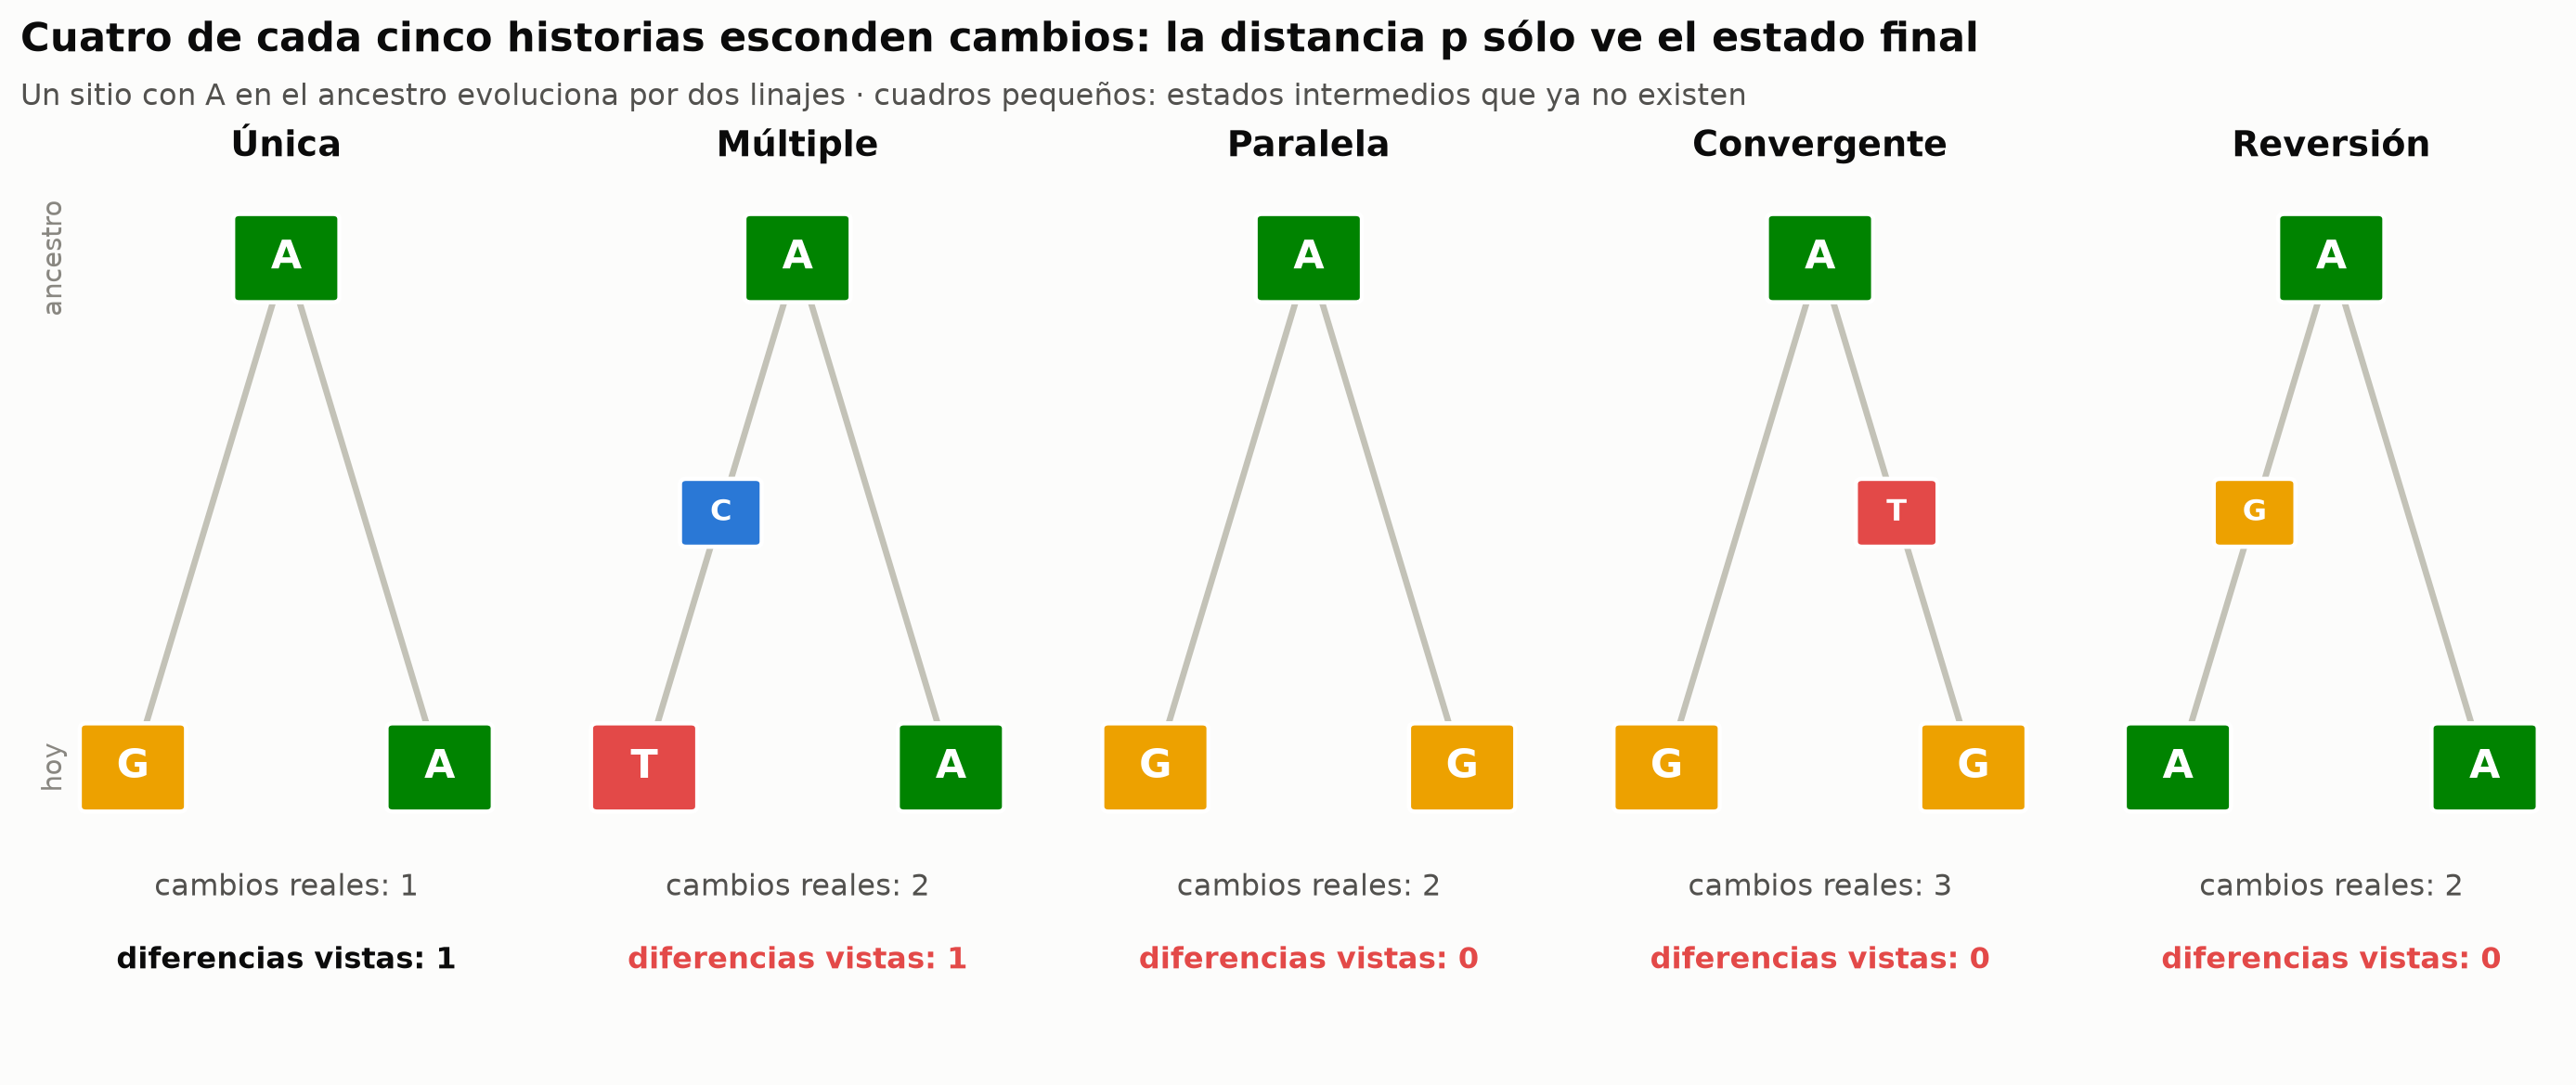

In [3]:
def nuc_box(ax, x, y, base, size=0.46, alpha=1.0, fs=14):
    """Cuadro redondeado del color del nucleótido con la letra en blanco."""
    ax.add_patch(FancyBboxPatch((x - size / 2, y - size / 2), size, size, boxstyle="round,pad=0.03",
                                fc=ec.NUC_COLORS[base], ec="white", lw=1.5, alpha=alpha, zorder=3))
    ax.text(x, y, base, ha="center", va="center", color="white", fontsize=fs, fontweight="bold", zorder=4)

histories = [   # (nombre, linaje izquierdo, linaje derecho): cada linaje es la lista de estados desde el ancestro
    ("Única",      ["A", "G"],       ["A"]),
    ("Múltiple",   ["A", "C", "T"],  ["A"]),
    ("Paralela",   ["A", "G"],       ["A", "G"]),
    ("Convergente", ["A", "G"],      ["A", "T", "G"]),
    ("Reversión",  ["A", "G", "A"],  ["A"]),
]
fig, ax = plt.subplots(figsize=(12.5, 5.2))
ax.set_xlim(-0.2, 5 * 2.5 - 0.3); ax.set_ylim(-1.75, 3.75); ax.axis("off")
for k, (name, left, right) in enumerate(histories):
    cx = 1.1 + 2.5 * k
    anc, dl, dr = (cx, 3.0), (cx - 0.75, 0.0), (cx + 0.75, 0.0)
    for end in (dl, dr):
        ax.plot([anc[0], end[0]], [anc[1], end[1]], color=ec.BASELINE, lw=2.2, zorder=1)
    nuc_box(ax, *anc, "A")
    for lineage, end in ((left, dl), (right, dr)):
        states = lineage[1:]
        for j, b in enumerate(states[:-1]):            # estados intermedios a lo largo de la rama
            f = (j + 1) / len(states)
            nuc_box(ax, anc[0] + f * (end[0] - anc[0]), anc[1] + f * (end[1] - anc[1]), b, size=0.34, fs=10.5)
        nuc_box(ax, *end, lineage[-1])
    real = (len(left) - 1) + (len(right) - 1)
    seen = int(left[-1] != right[-1])
    ax.text(cx, 3.55, name, ha="center", va="bottom", fontsize=12.5, fontweight="bold", color=ec.INK)
    ax.text(cx, -0.62, f"cambios reales: {real}", ha="center", va="top", fontsize=10.5, color=ec.INK_2)
    ax.text(cx, -1.05, f"diferencias vistas: {seen}", ha="center", va="top", fontsize=10.5,
            color=ec.INK if seen == real else ec.RED, fontweight="bold")
ax.text(-0.1, 3.0, "ancestro", ha="left", va="center", fontsize=9.5, color=ec.MUTED, rotation=90)
ax.text(-0.1, 0.0, "hoy", ha="left", va="center", fontsize=9.5, color=ec.MUTED, rotation=90)
ec.title(ax, "Cuatro de cada cinco historias esconden cambios: la distancia p sólo ve el estado final",
         "Un sitio con A en el ancestro evoluciona por dos linajes · cuadros pequeños: estados intermedios que ya no existen")
plt.show()

> 🔎 **Qué observamos.** Sólo en la historia "única" coinciden los cambios reales con las diferencias vistas. En las
> otras cuatro, las diferencias **subestiman** lo ocurrido. Cuando las secuencias son parecidas estas historias son
> rarísimas (hacen falta dos golpes en el mismo sitio), pero a medida que pasa el tiempo se vuelven la norma.

### Simulación: una secuencia que muta durante mucho tiempo

Hagamos el experimento que la naturaleza no nos deja hacer: tomar una secuencia ancestral de 2 000 sitios y dejarla
mutar, **llevando la cuenta** de cada sustitución. Usamos la regla más sencilla posible: en cada paso de tiempo,
cada sitio muta con una probabilidad pequeña ($\mu = 0.005$), y si muta, cambia a cualquiera de las otras tres bases
con igual probabilidad.

En cada paso medimos dos cosas comparando la secuencia actual con la ancestral:

* $d$ = número **real** de sustituciones por sitio (lo sabemos porque llevamos la cuenta);
* $p$ = proporción de sitios **observados** distintos del ancestro.

(Aquí comparamos un descendiente con su propio ancestro. Cuando comparemos dos especies actuales, la distancia será la
suma de las dos ramas que las unen con su ancestro común; la matemática es la misma.)

> 🤔 **Antes de ejecutar, prediga:** después de que ocurran, en promedio, **1.5 sustituciones por sitio**, ¿qué
> fracción de los sitios será distinta del ancestro? ¿Más de 1? ¿Cerca de 1? ¿Menos?

In [4]:
def simulate_jc(L, mu, n_steps, rng):
    """Evolución de una secuencia de L sitios en n_steps pasos discretos. En cada paso cada sitio muta con
    probabilidad mu a una de las otras 3 bases (al azar). Devuelve el ancestro, la historia de estados
    (n_steps+1 x L) y el número acumulado de sustituciones por sitio (n_steps+1 x L)."""
    anc = rng.integers(0, 4, L)
    states = np.empty((n_steps + 1, L), dtype=np.int8); hits = np.zeros((n_steps + 1, L), dtype=np.int16)
    states[0] = anc
    for t in range(1, n_steps + 1):
        mut = rng.random(L) < mu
        shift = rng.integers(1, 4, L)                   # +1, +2 o +3 (mód 4): nunca la misma base
        states[t] = np.where(mut, (states[t - 1] + shift) % 4, states[t - 1])
        hits[t] = hits[t - 1] + mut
    return anc, states, hits

L_SIM, MU, STEPS = 2000, 0.005, 300
anc, hist_states, hist_hits = simulate_jc(L_SIM, MU, STEPS, rng)
d_true = hist_hits.mean(axis=1)                          # sustituciones reales por sitio
p_obs = (hist_states != anc).mean(axis=1)                 # proporción observada de sitios distintos
for t in [20, 60, 150, 300]:
    print(f"paso {t:>3}: d real = {d_true[t]:.3f} sust./sitio · p observada = {p_obs[t]:.3f} · "
          f"p subestima en {1 - p_obs[t] / d_true[t]:.0%}")

# Clasificación de cada sitio al final: ¿cuántos cambios esconde?
h, same = hist_hits[-1], hist_states[-1] == anc
cats = pd.Series({"sin cambios": (h == 0).sum(), "1 cambio (visible)": (h == 1).sum(),
                  "≥2 cambios, distinto del ancestro": ((h >= 2) & ~same).sum(),
                  "≥2 cambios, igual al ancestro (reversión)": ((h >= 2) & same).sum()})
print("\nAl final de la simulación:\n" + cats.to_string())

paso  20: d real = 0.097 sust./sitio · p observada = 0.092 · p subestima en 4%
paso  60: d real = 0.304 sust./sitio · p observada = 0.265 · p subestima en 13%
paso 150: d real = 0.743 sust./sitio · p observada = 0.469 · p subestima en 37%
paso 300: d real = 1.521 sust./sitio · p observada = 0.651 · p subestima en 57%

Al final de la simulación:
sin cambios                                  434
1 cambio (visible)                           666
≥2 cambios, distinto del ancestro            636
≥2 cambios, igual al ancestro (reversión)    264


## 🎬 Animación: la secuencia muta y la curva de p se queda atrás

Arriba vemos 60 de los 2 000 sitios: la fila superior es el ancestro y la inferior la secuencia actual; debajo de cada
sitio, el número de sustituciones que lleva. Los sitios con borde rojo son **reversiones**: cambiaron al menos dos
veces y volvieron a la base original, así que la distancia p los cuenta como "sin cambios". Abajo, la curva del número
real de sustituciones por sitio ($d$) y la de la proporción observada ($p$), calculadas con los 2 000 sitios.

![Una secuencia muta durante 300 pasos: las sustituciones reales (d) crecen sin límite, mientras que la proporción observada (p) se frena y se acerca a 0.75](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-05-filogenetica/5.1_secuencia_muta.gif)

*Una secuencia muta durante 300 pasos: las sustituciones reales (d) crecen sin límite, mientras que la proporción observada (p) se frena y se acerca a 0.75*

In [5]:
N_SHOW = 60
frame_steps = np.linspace(0, STEPS, 51).astype(int)
fig = plt.figure(figsize=(12, 6.4))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.87))       # deja libre la franja del título (el GIF no se recorta)
gs = fig.add_gridspec(2, 1, height_ratios=[1.05, 1.6], hspace=0.32)
ax_seq, ax_curve = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
ax_seq.set_xlim(-2.5, N_SHOW); ax_seq.set_ylim(-1.9, 1.8); ax_seq.axis("off")
ax_seq.text(-0.9, 1, "ancestro", ha="right", va="center", fontsize=10, color=ec.INK_2)
ax_seq.text(-0.9, 0, "actual", ha="right", va="center", fontsize=10, color=ec.INK_2)
ax_seq.text(-0.9, -0.95, "cambios", ha="right", va="center", fontsize=9, color=ec.MUTED)
cur_boxes, cur_txt, hit_txt = [], [], []
for i in range(N_SHOW):
    b = BASES[anc[i]]
    ax_seq.add_patch(Rectangle((i - 0.45, 0.6), 0.9, 0.8, fc=ec.NUC_COLORS[b], ec="white", lw=0.8))
    ax_seq.text(i, 1, b, ha="center", va="center", color="white", fontsize=8.5, fontweight="bold")
    r = Rectangle((i - 0.45, -0.4), 0.9, 0.8, fc=ec.NUC_COLORS[b], ec="white", lw=0.8)
    ax_seq.add_patch(r); cur_boxes.append(r)
    cur_txt.append(ax_seq.text(i, 0, b, ha="center", va="center", color="white", fontsize=8.5, fontweight="bold"))
    hit_txt.append(ax_seq.text(i, -0.95, "", ha="center", va="center", fontsize=8, color=ec.INK_2))
seq_status = ax_seq.text(0, -1.7, "", fontsize=10.5, color=ec.INK, va="center")

ax_curve.plot(d_true, d_true, color=ec.BASELINE, lw=1, ls=":")
ax_curve.axhline(0.75, color=ec.MUTED, lw=1, ls="--")
ax_curve.text(0.02, 0.77, "techo de p: 0.75", fontsize=9.5, color=ec.INK_2)
line_d, = ax_curve.plot([], [], color=ec.BLUE, lw=2.4)
line_p, = ax_curve.plot([], [], color=ec.ORANGE, lw=2.4)
lab_d = ax_curve.text(0, 0, "", fontsize=10, color=ec.INK_2, va="center")
lab_p = ax_curve.text(0, 0, "", fontsize=10, color=ec.INK_2, va="center")
ax_curve.set_xlim(0, d_true[-1] * 1.2); ax_curve.set_ylim(0, d_true[-1] * 1.08)
ax_curve.set_xlabel("Sustituciones reales por sitio (d)"); ax_curve.set_ylabel("Valor")
# Títulos dentro del lienzo (el GIF se guarda sin recortes, así que no pueden quedar por encima de la figura)
fig.text(0.01, 0.965, "La distancia p crece cada vez más despacio que las sustituciones reales",
         fontsize=15, fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.915, f"Simulación de {L_SIM:,} sitios (μ = {MU} por sitio y paso) · arriba, 60 sitios · borde rojo: reversión",
         fontsize=10.5, color=ec.INK_2, va="top")

def update(f):
    t = frame_steps[f]
    for i in range(N_SHOW):
        b, n_h = BASES[hist_states[t, i]], hist_hits[t, i]
        cur_boxes[i].set_facecolor(ec.NUC_COLORS[b]); cur_txt[i].set_text(b)
        reverted = n_h >= 2 and hist_states[t, i] == anc[i]
        cur_boxes[i].set_edgecolor(ec.RED if reverted else "white"); cur_boxes[i].set_linewidth(2.4 if reverted else 0.8)
        hit_txt[i].set_text(str(n_h) if n_h else "·")
    seq_status.set_text(f"paso {t:>3} · en estos 60 sitios: {hist_hits[t, :N_SHOW].sum()} sustituciones reales, "
                        f"{(hist_states[t, :N_SHOW] != anc[:N_SHOW]).sum()} diferencias visibles")
    line_d.set_data(d_true[:t + 1], d_true[:t + 1]); line_p.set_data(d_true[:t + 1], p_obs[:t + 1])
    lab_d.set_position((d_true[t] + 0.02, d_true[t])); lab_d.set_text(f"d real = {d_true[t]:.2f}")
    lab_p.set_position((d_true[t] + 0.02, p_obs[t] - 0.05)); lab_p.set_text(f"p = {p_obs[t]:.2f}")
    return cur_txt + hit_txt + [line_d, line_p, lab_d, lab_p, seq_status]

fig.canvas.draw()                                     # fija la disposición antes del primer cuadro
with plt.rc_context({"savefig.bbox": None}):         # cuadros del mismo tamaño y sin recorte
    anim_html = ec.animate(fig, update, frames=len(frame_steps), interval=160, name="5.1_secuencia_muta")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Al principio las dos curvas van juntas: casi cada sustitución produce una diferencia nueva.
> Pronto la curva naranja (p) se curva hacia abajo: los nuevos golpes caen cada vez más a menudo sobre sitios que ya
> habían cambiado. Tras 1.5 sustituciones por sitio, p ronda 0.65–0.7, y aparecen varias **reversiones** (bordes
> rojos) que la distancia p cuenta como "sin cambio". Si siguiéramos, p se estancaría en 0.75: la secuencia actual ya
> no guarda memoria de la ancestral. Eso es la **saturación**.

Necesitamos una fórmula que "deshaga" la curvatura: que a partir de p (lo que medimos) nos devuelva $d$ (lo que
queremos). Para obtenerla hay que describir con matemáticas cómo cambia un sitio a lo largo del tiempo.

## 3. La evolución como proceso de Márkov en tiempo continuo

En la Lección 4.3 usamos cadenas de Márkov que avanzan **a saltos**: base 1, base 2, base 3… Aquí la idea es la misma,
pero el "paso" es el **tiempo**, que corre de forma continua. Fijémonos en **un solo sitio** de la secuencia. En cada
instante está en uno de cuatro estados (A, C, G o T) y, de vez en cuando, salta a otro. Suponemos, como antes, la
**propiedad de Márkov**: la probabilidad de saltar en el próximo instante depende sólo de la base actual, no de la
historia del sitio. Un sitio que hoy tiene G no "recuerda" que ayer tuvo A.

### La matriz de tasas $Q$

El proceso se describe con una matriz $Q$ de **tasas instantáneas** de sustitución:

$$
Q = \begin{pmatrix}
- & q_{AC} & q_{AG} & q_{AT}\\
q_{CA} & - & q_{CG} & q_{CT}\\
q_{GA} & q_{GC} & - & q_{GT}\\
q_{TA} & q_{TC} & q_{TG} & -
\end{pmatrix},
\qquad q_{ii} = -\sum_{j\neq i} q_{ij}
$$

| Símbolo | Significado |
|---|---|
| $q_{ij}$ ($i \neq j$) | tasa de cambio de la base $i$ a la base $j$: en un intervalo muy corto $\Delta t$, $P(i \to j) \approx q_{ij}\,\Delta t$ |
| $q_{ii}$ | menos la tasa total de salida de $i$; por eso **cada fila de $Q$ suma 0** |
| $-q_{ii}$ | tasa a la que un sitio con la base $i$ sufre alguna sustitución |

Las tasas **no son probabilidades**: pueden ser mayores que 1 y tienen unidades de "sustituciones por unidad de
tiempo". Una tasa de 0.1 por millón de años significa que, en un millón de años, un sitio tiene una probabilidad de
cambio de aproximadamente 0.1 (si el intervalo es corto comparado con $1/0.1$).

### De tasas a probabilidades: $P(t) = e^{Qt}$

Lo que realmente queremos es $P_{ij}(t)$: la probabilidad de que un sitio que empieza en $i$ esté en $j$ después de un
tiempo $t$ (pasando por cualquier camino intermedio). Para un $\Delta t$ muy pequeño,
$P(t + \Delta t) \approx P(t)\,(I + Q\,\Delta t)$, lo que lleva a la ecuación diferencial
$\tfrac{d}{dt}P(t) = P(t)\,Q$ con $P(0) = I$. Su solución es la **exponencial de una matriz**:

$$
\boxed{\;P(t) \;=\; e^{Qt} \;=\; I + Qt + \frac{(Qt)^2}{2!} + \frac{(Qt)^3}{3!} + \cdots\;}
$$

| Símbolo | Significado |
|---|---|
| $P(t)$ | matriz 4×4; la fila $i$ es la distribución de la base al tiempo $t$ si se empezó en $i$ (cada fila suma 1) |
| $I$ | matriz identidad: en $t = 0$ nada ha cambiado |
| $e^{Qt}$ | exponencial matricial: la serie de arriba (no es exponenciar cada casilla por separado) |

Cada término de la serie tiene sentido: $Qt$ corresponde a los caminos con un cambio, $(Qt)^2/2!$ a los caminos con dos
cambios (entre ellos, las reversiones), etc. **La exponencial suma todas las historias posibles**, justo lo que le
faltaba a la distancia p.

### Ejemplo a mano

Tome el modelo más simple: todas las tasas entre bases distintas valen $\alpha = 0.1$ y $t = 1$. Entonces cada
elemento de $Qt$ fuera de la diagonal vale $0.1$ y cada elemento de la diagonal $-0.3$. Para $(Qt)^2$, multiplicamos
filas por columnas:

* diagonal: $(-0.3)(-0.3) + 3\,(0.1)(0.1) = 0.09 + 0.03 = 0.12$;
* fuera de la diagonal: $2\,(-0.3)(0.1) + 2\,(0.1)(0.1) = -0.06 + 0.02 = -0.04$.

Con los tres primeros términos de la serie:

$$
P_{AA}(1) \approx 1 - 0.3 + \tfrac{0.12}{2} = 0.760,
\qquad
P_{AC}(1) \approx 0 + 0.1 - \tfrac{0.04}{2} = 0.080
$$

y la fila suma $0.760 + 3(0.080) = 1$ ✔. Veamos cuánto se aleja esto del valor exacto que calcula
`scipy.linalg.expm` (que usa un método numérico robusto, no la serie ingenua).

In [6]:
def jc_Q(alpha=1.0):
    """Matriz de tasas de Jukes-Cantor: todas las tasas entre bases distintas valen alpha."""
    Q = np.full((4, 4), alpha)
    np.fill_diagonal(Q, -3 * alpha)
    return Q

def taylor_expm(M, n_terms):
    """Exponencial matricial truncada: I + M + M²/2! + ... (n_terms términos). Sólo para aprender."""
    out, term = np.eye(len(M)), np.eye(len(M))
    for k in range(1, n_terms):
        term = term @ M / k
        out = out + term
    return out

Q = jc_Q(0.1); t = 1.0
show = lambda M: pd.DataFrame(M, index=list(BASES), columns=list(BASES)).round(4)
print("Q =\n", show(Q))
print("\n(Qt)² =\n", show((Q * t) @ (Q * t)))
print("\nSerie con 3 términos:\n", show(taylor_expm(Q * t, 3)))
P1 = expm(Q * t)
print("\nexpm(Qt) exacta:\n", show(P1))

# Tres propiedades que debe cumplir cualquier P(t)
print("\nFilas de P(t) suman 1:", np.allclose(P1.sum(axis=1), 1))
print("Chapman-Kolmogorov P(0.4)·P(0.6) = P(1):", np.allclose(expm(Q * 0.4) @ expm(Q * 0.6), P1))
pi_jc = np.full(4, 0.25)
print("Equilibrio π·Q = 0 con π = (¼, ¼, ¼, ¼):", np.allclose(pi_jc @ Q, 0))

Q =
      A    C    G    T
A -0.3  0.1  0.1  0.1
C  0.1 -0.3  0.1  0.1
G  0.1  0.1 -0.3  0.1
T  0.1  0.1  0.1 -0.3

(Qt)² =
       A     C     G     T
A  0.12 -0.04 -0.04 -0.04
C -0.04  0.12 -0.04 -0.04
G -0.04 -0.04  0.12 -0.04
T -0.04 -0.04 -0.04  0.12

Serie con 3 términos:
       A     C     G     T
A  0.76  0.08  0.08  0.08
C  0.08  0.76  0.08  0.08
G  0.08  0.08  0.76  0.08
T  0.08  0.08  0.08  0.76

expm(Qt) exacta:
         A       C       G       T
A  0.7527  0.0824  0.0824  0.0824
C  0.0824  0.7527  0.0824  0.0824
G  0.0824  0.0824  0.7527  0.0824
T  0.0824  0.0824  0.0824  0.7527

Filas de P(t) suman 1: True
Chapman-Kolmogorov P(0.4)·P(0.6) = P(1): True
Equilibrio π·Q = 0 con π = (¼, ¼, ¼, ¼): True


La propiedad de **Chapman-Kolmogorov**, $P(s + t) = P(s)\,P(t)$, dice que evolucionar 0.4 y luego 0.6 unidades de
tiempo es lo mismo que evolucionar 1 unidad de golpe. La **distribución de equilibrio** $\pi$ cumple $\pi Q = 0$: si
las bases ya tienen esas frecuencias, el proceso no las cambia. Veamos qué pasa con la serie truncada cuando $t$ crece.

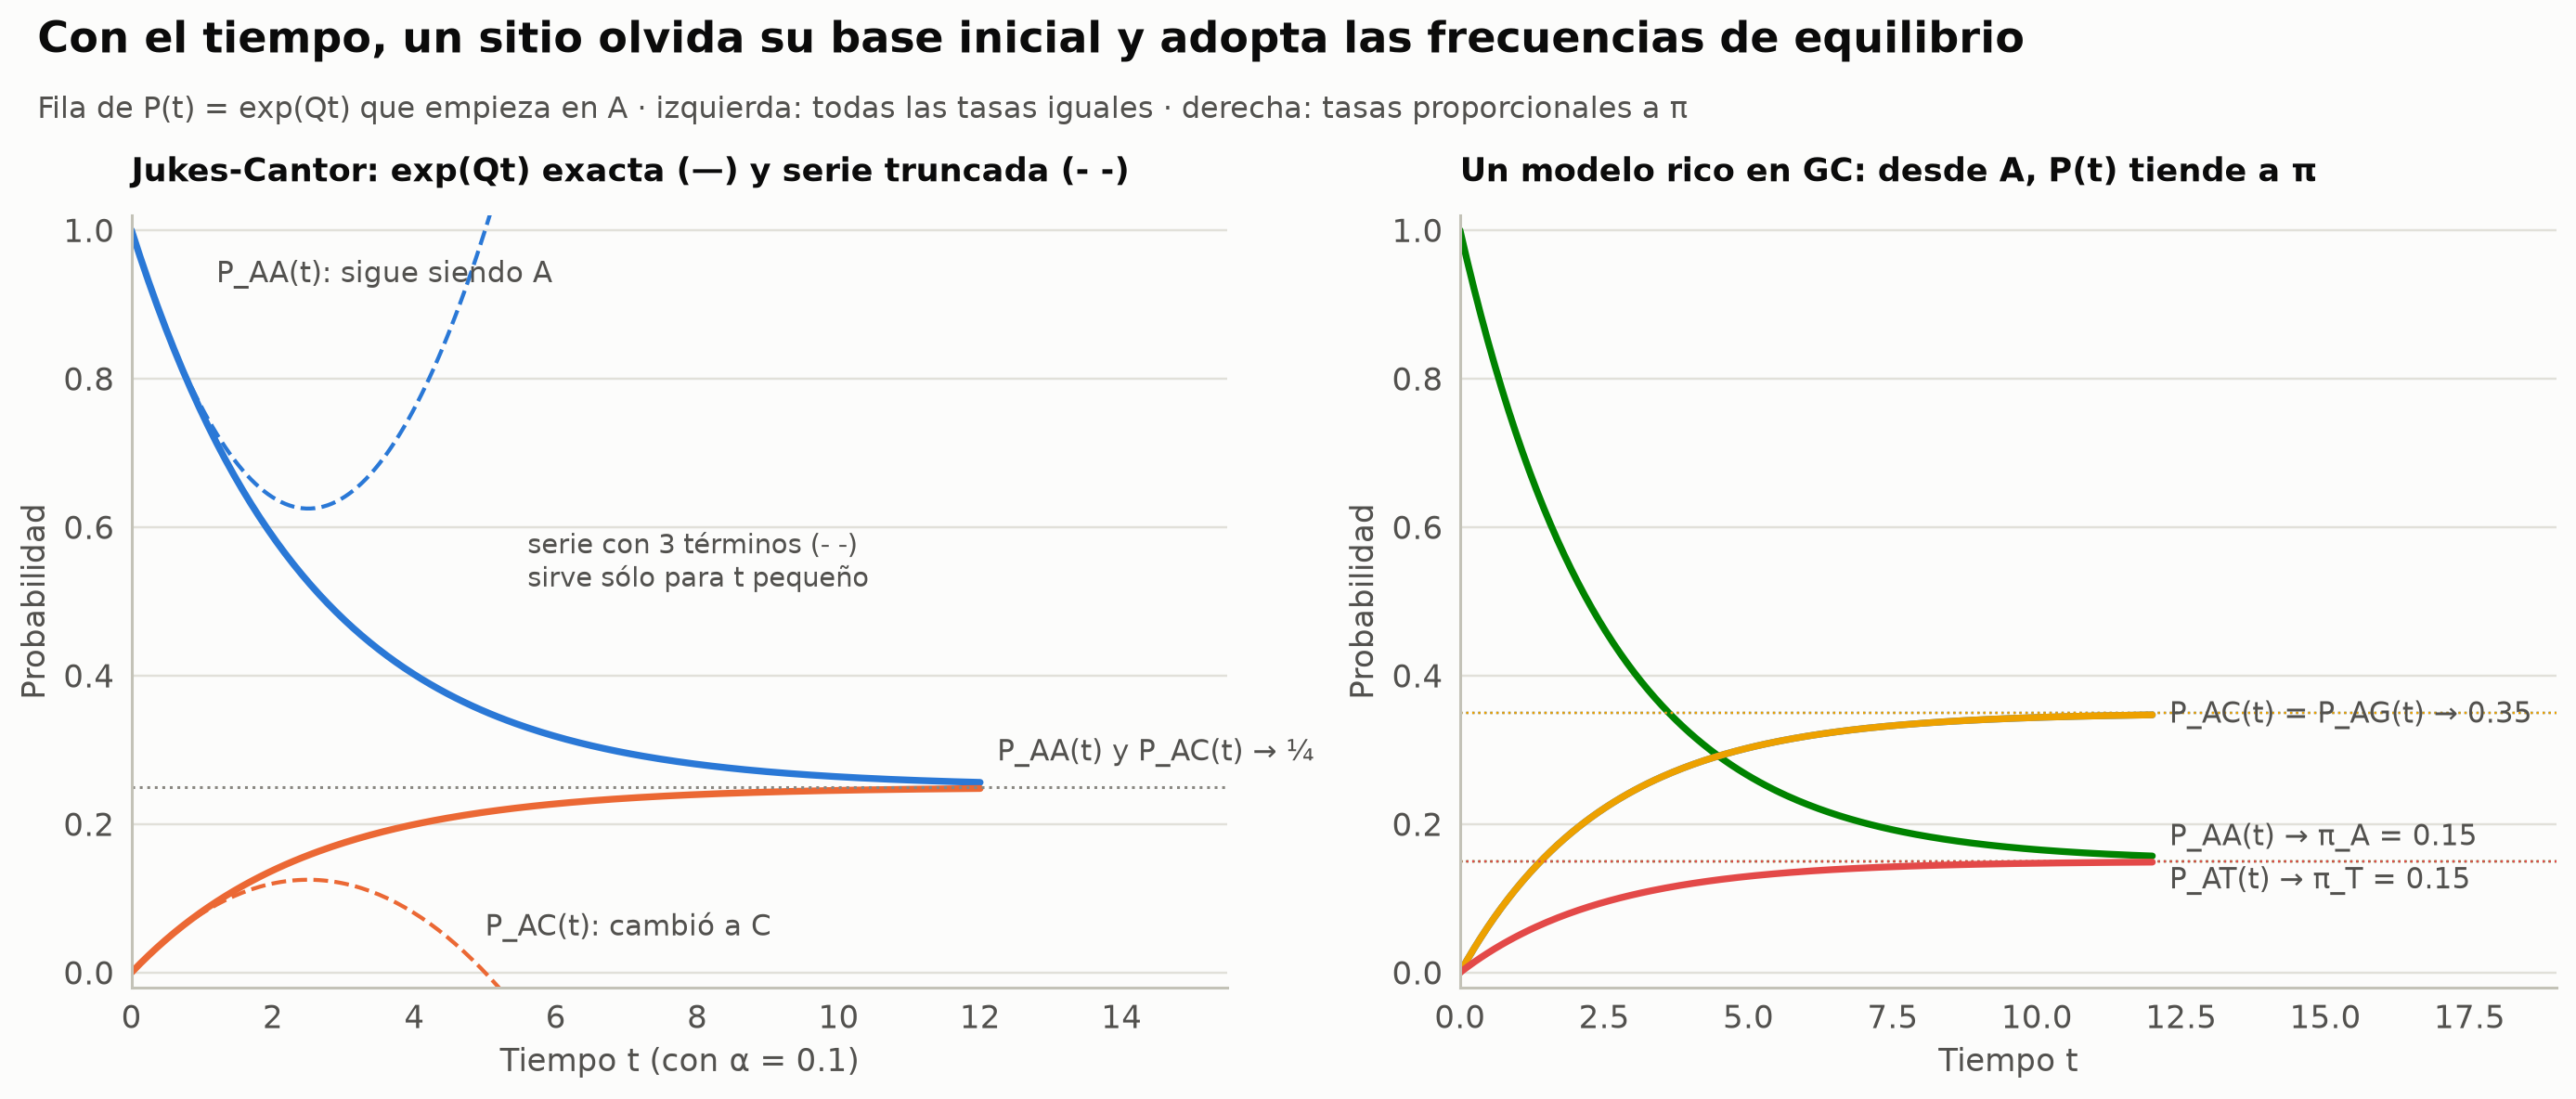

In [7]:
ts = np.linspace(0, 12, 200)
P_exact = np.array([expm(Q * tt) for tt in ts])
P_tay = np.array([taylor_expm(Q * tt, 3) for tt in ts])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
ax.plot(ts, P_exact[:, 0, 0], color=ec.BLUE, lw=2.4)
ax.plot(ts, P_exact[:, 0, 1], color=ec.ORANGE, lw=2.4)
ax.plot(ts, P_tay[:, 0, 0], color=ec.BLUE, lw=1.4, ls="--")
ax.plot(ts, P_tay[:, 0, 1], color=ec.ORANGE, lw=1.4, ls="--")
ax.axhline(0.25, color=ec.MUTED, lw=1, ls=":")
ec.label_end(ax, ts[-1], P_exact[-1, 0, 0] + 0.04, "P_AA(t) y P_AC(t) → ¼")
ax.text(1.2, 0.93, "P_AA(t): sigue siendo A", color=ec.INK_2, fontsize=10)
ax.text(5.0, 0.05, "P_AC(t): cambió a C", color=ec.INK_2, fontsize=10)
ax.text(5.6, 0.52, "serie con 3 términos (- -)\nsirve sólo para t pequeño", color=ec.INK_2, fontsize=9.5)
ax.set_ylim(-0.02, 1.02); ax.set_xlim(0, 15.5)
ax.set_xlabel("Tiempo t (con α = 0.1)"); ax.set_ylabel("Probabilidad")
ax.set_title("Jukes-Cantor: exp(Qt) exacta (—) y serie truncada (- -)", loc="left", fontsize=11.5)

# Un modelo con bases desiguales: π rico en GC
pi_gc = np.array([0.15, 0.35, 0.35, 0.15])
Q_gc = np.tile(pi_gc, (4, 1)) * 0.4                     # tasa hacia j proporcional a π_j (modelo F81)
np.fill_diagonal(Q_gc, 0); np.fill_diagonal(Q_gc, -Q_gc.sum(axis=1))
P_gc = np.array([expm(Q_gc * tt) for tt in ts])
ax = axes[1]
for j, b in enumerate(BASES):
    ax.plot(ts, P_gc[:, 0, j], color=ec.NUC_COLORS[b], lw=2.4)
    ax.axhline(pi_gc[j], color=ec.NUC_COLORS[b], lw=0.8, ls=":")
    if b != "C":                                          # P_AC(t) = P_AG(t): una sola etiqueta
        ec.label_end(ax, ts[-1], P_gc[-1, 0, j] + (0.025 if b == "A" else -0.025 if b == "T" else 0),
                     (f"P_AC(t) = P_AG(t) → {pi_gc[j]:.2f}" if b == "G" else f"P_A{b}(t) → π_{b} = {pi_gc[j]:.2f}"),
                     color=ec.INK_2)
ax.set_xlim(0, 19); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Tiempo t"); ax.set_ylabel("Probabilidad")
ax.set_title("Un modelo rico en GC: desde A, P(t) tiende a π", loc="left", fontsize=11.5)
ec.fig_title(fig, "Con el tiempo, un sitio olvida su base inicial y adopta las frecuencias de equilibrio",
             "Fila de P(t) = exp(Qt) que empieza en A · izquierda: todas las tasas iguales · derecha: tasas proporcionales a π")
plt.show()

> 🔎 **Qué observamos.** (Izquierda) La probabilidad de "seguir siendo A" cae desde 1 hasta ¼, y la de "haber
> cambiado a C" sube desde 0 hasta ¼: pasado suficiente tiempo, la base inicial ya no importa. La serie truncada a tres
> términos es buena hasta $t \approx 1$ y después se dispara: por eso se usa `expm`, que combina un escalado de la
> matriz con aproximaciones racionales (el método de *escalado y cuadrado*). (Derecha) Si el modelo prefiere G y C,
> la fila de $P(t)$ converge a las frecuencias de equilibrio $\pi$, no a ¼.

✅ **Compruebe su comprensión.** ¿Por qué cada fila de $Q$ suma 0 y cada fila de $P(t)$ suma 1? (Respuesta: la fila
$i$ de $P(t)$ es una distribución de probabilidad sobre la base final; la de $Q$ es su derivada en $t = 0$, y la
derivada de una suma constante igual a 1 es 0.)

## 4. El modelo de Jukes-Cantor (JC69)

Jukes y Cantor (1969) propusieron el modelo más sencillo: **todas las sustituciones tienen la misma tasa** $\alpha$ y
las cuatro bases tienen la misma frecuencia (¼). Es exactamente el $Q$ de nuestro ejemplo.

### Derivación de $P(t)$

Por simetría, basta seguir una cantidad: $P_{ii}(t)$, la probabilidad de que el sitio tenga la misma base que al
principio. En un instante $\Delta t$, esa probabilidad **baja** porque un sitio igual puede cambiar (tasa $3\alpha$)
y **sube** porque un sitio distinto puede volver a la base original (tasa $\alpha$, desde cualquiera de las otras tres):

$$
\frac{dP_{ii}}{dt} \;=\; -3\alpha\,P_{ii} + \alpha\,(1 - P_{ii}) \;=\; \alpha - 4\alpha\,P_{ii}
$$

Con $P_{ii}(0) = 1$, esta ecuación lineal se resuelve con una exponencial:

$$
P_{ii}(t) = \tfrac14 + \tfrac34\, e^{-4\alpha t}
\qquad\qquad
P_{ij}(t) = \tfrac14 - \tfrac14\, e^{-4\alpha t}\quad (i \neq j)
$$

### De la probabilidad a la distancia

Dos secuencias separadas por un tiempo total $T$ (la suma de las dos ramas que las unen con su ancestro común) difieren
en un sitio con probabilidad $p = 1 - P_{ii}(T) = \tfrac34\big(1 - e^{-4\alpha T}\big)$. Mientras tanto, el número
esperado de sustituciones por sitio es $d = 3\alpha T$ (tasa de salida por tiempo). Sustituyendo $\alpha T = d/3$ y
despejando $d$:

$$
p = \tfrac34\left(1 - e^{-4d/3}\right)
\qquad\Longrightarrow\qquad
\boxed{\;d_{JC} = -\tfrac34 \ln\!\left(1 - \tfrac43\,p\right)\;}
$$

| Símbolo | Significado |
|---|---|
| $\alpha$ | tasa de sustitución hacia **cada** una de las otras tres bases |
| $T$ | tiempo total que separa a las dos secuencias (suma de ramas) |
| $d$ | distancia evolutiva: número **esperado** de sustituciones por sitio, $d = 3\alpha T$ |
| $p$ | proporción de sitios distintos observada |
| $\tfrac34$ | la $p$ máxima: dos secuencias sin relación coinciden en ¼ de los sitios |

Observe que $\alpha$ y $T$ nunca aparecen por separado: sólo su producto. **Con dos secuencias no se puede distinguir
una tasa alta durante poco tiempo de una tasa baja durante mucho tiempo**; por eso las distancias se expresan en
sustituciones por sitio y no en años.

### Ejemplo a mano

Para $p = 0.2$: $1 - \tfrac43(0.2) = 0.7333$; $\ln 0.7333 = -0.3102$; $d = -0.75 \times (-0.3102) = 0.2326$. Es
decir, detrás de 20 diferencias cada 100 sitios hubo, en promedio, unas 23 sustituciones.

| $p$ observada | $1 - \tfrac43p$ | $d_{JC}$ | sustituciones "escondidas" |
|---|---|---|---|
| 0.05 | 0.9333 | 0.0517 | 3 % |
| 0.15 | 0.8000 | 0.1674 | 10 % |
| 0.20 | 0.7333 | 0.2326 | 14 % |
| 0.50 | 0.3333 | 0.8240 | 39 % |
| 0.70 | 0.0667 | 2.0310 | 66 % |
| ≥ 0.75 | ≤ 0 | **indefinida** | la secuencia está saturada |

In [8]:
def jc_distance(p):
    """Distancia de Jukes-Cantor. Devuelve inf si p >= 0.75 (saturación: el logaritmo no está definido)."""
    p = np.asarray(p, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(p < 0.75, -0.75 * np.log(1 - 4 * p / 3), np.inf)

def jc_P(d):
    """P(t) de Jukes-Cantor en función de d = 3αt (fórmula cerrada)."""
    e = np.exp(-4 * d / 3)
    return np.where(np.eye(4, dtype=bool), 0.25 + 0.75 * e, 0.25 - 0.25 * e)

for p_ in [0.05, 0.15, 0.2, 0.5, 0.7, 0.76]:
    print(f"p = {p_:.2f}  →  d_JC = {jc_distance(p_):.4f}")
# La fórmula cerrada coincide con expm(Qt) (con α = 1, d = 3t)
print("\nFórmula cerrada = expm(Qt):", all(np.allclose(jc_P(3 * tt), expm(jc_Q(1.0) * tt)) for tt in [0.01, 0.3, 2.0]))

p = 0.05  →  d_JC = 0.0517
p = 0.15  →  d_JC = 0.1674
p = 0.20  →  d_JC = 0.2326
p = 0.50  →  d_JC = 0.8240
p = 0.70  →  d_JC = 2.0310
p = 0.76  →  d_JC = inf

Fórmula cerrada = expm(Qt): True


> 🤔 **Antes de ejecutar, prediga:** si aplicamos la corrección de Jukes-Cantor a las $p$ observadas en la simulación
> de la sección 2, ¿recuperaremos las sustituciones reales $d$ que llevamos contadas?

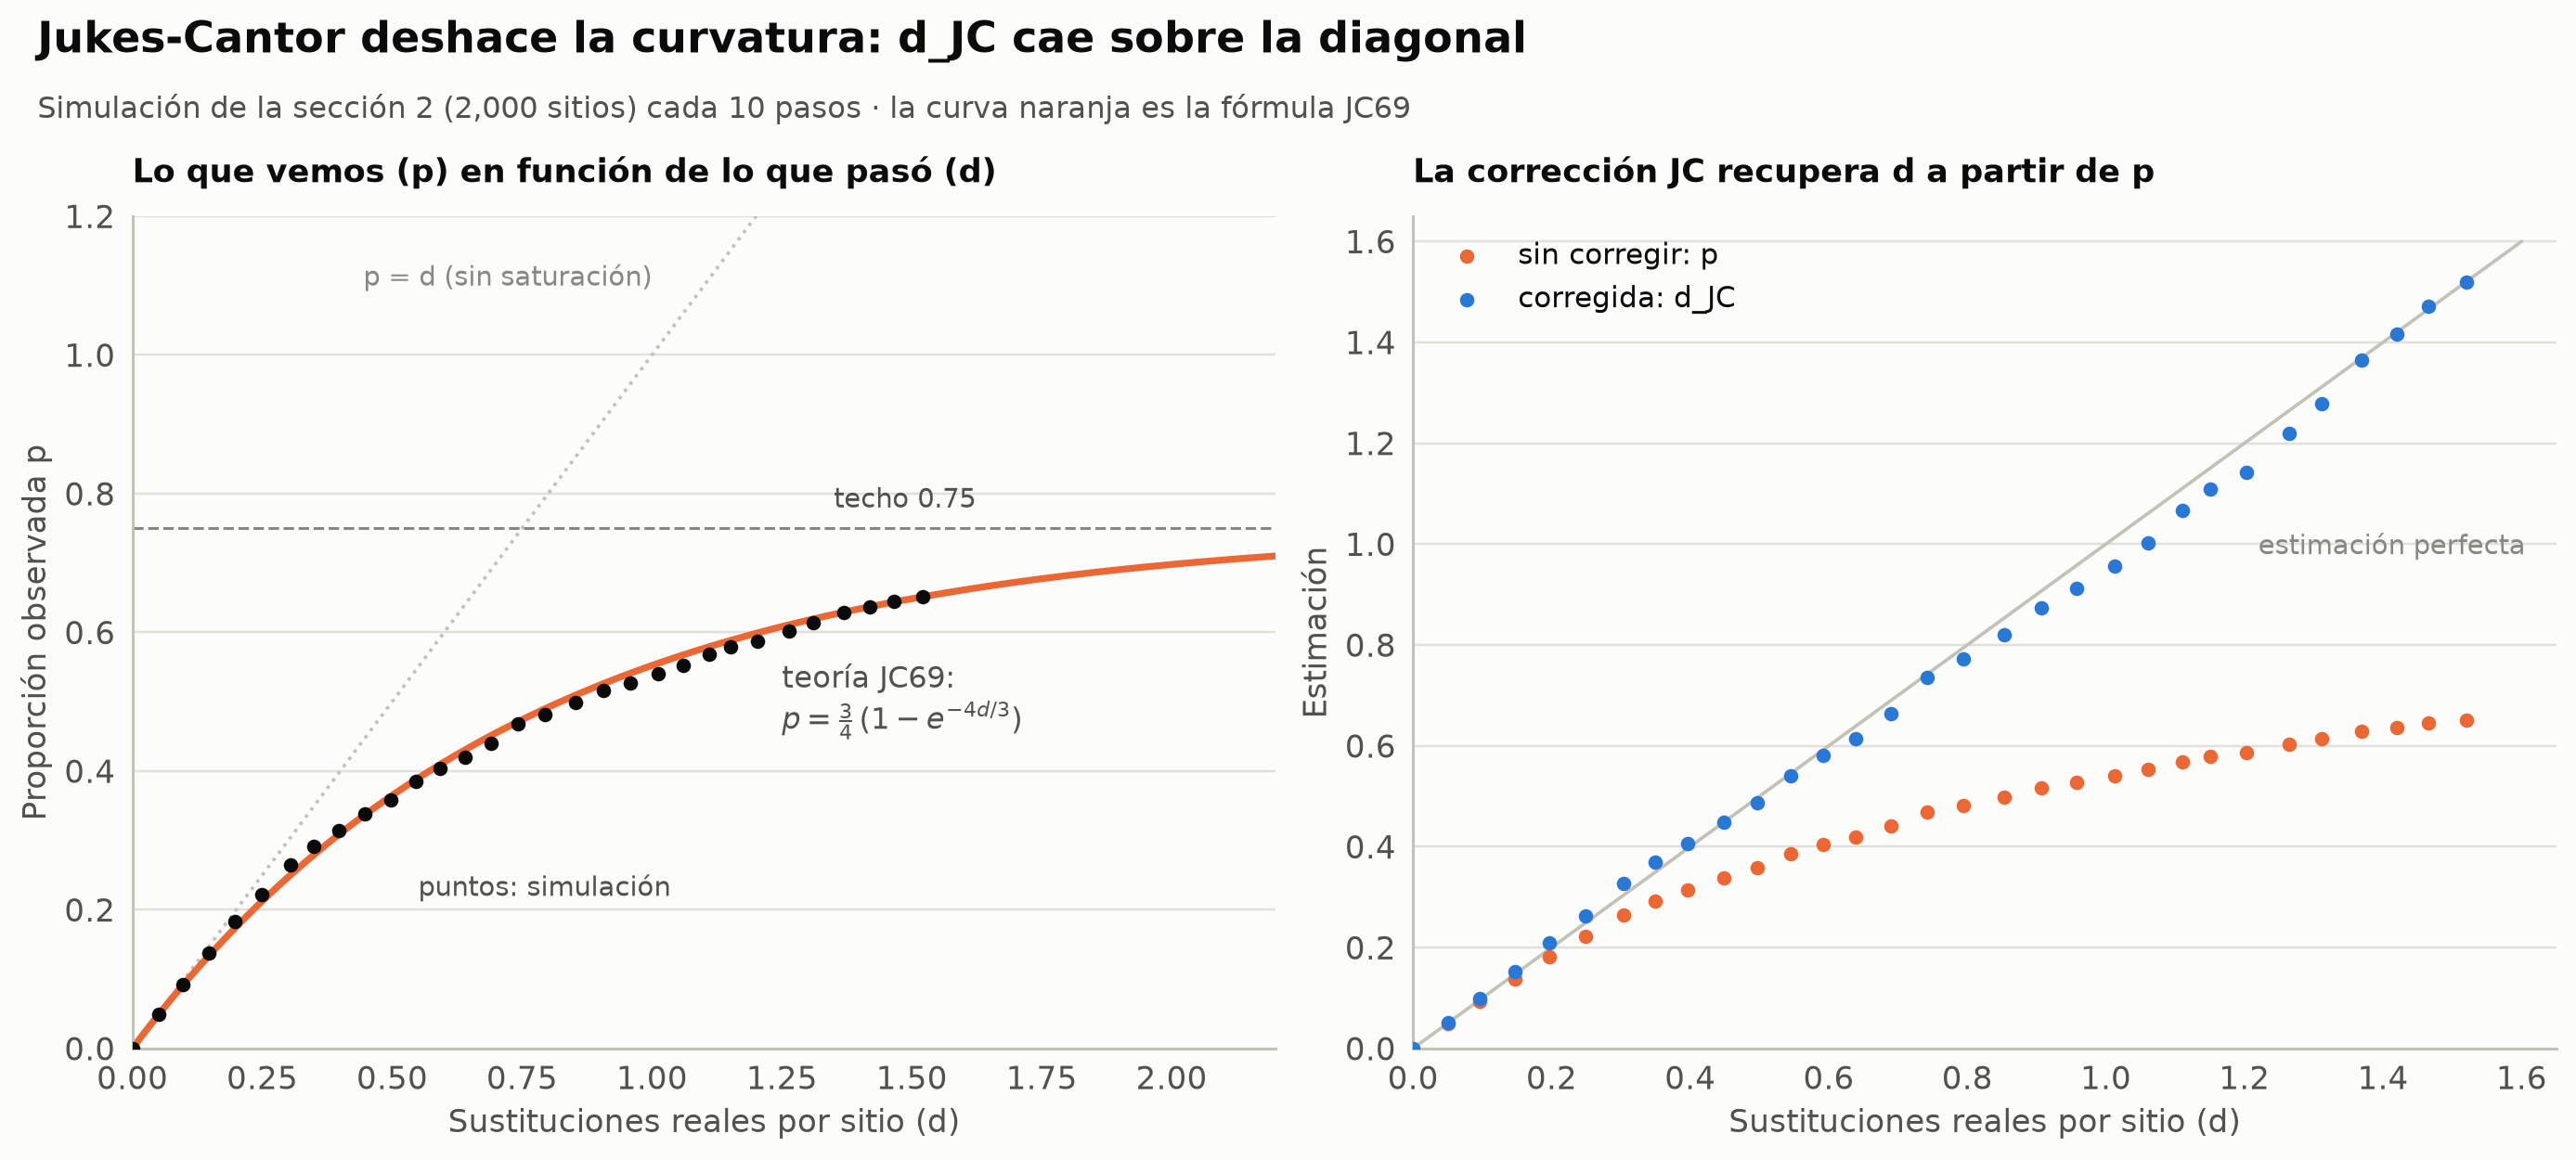

In [9]:
d_grid = np.linspace(0, 2.2, 300)
p_theory = 0.75 * (1 - np.exp(-4 * d_grid / 3))
d_hat_sim = jc_distance(p_obs)
idx = np.arange(0, STEPS + 1, 10)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9))
ax = axes[0]
ax.plot(d_grid, d_grid, color=ec.BASELINE, lw=1.2, ls=":")
ax.text(1.0, 1.1, "p = d (sin saturación)", color=ec.MUTED, fontsize=9.5, ha="right")
ax.plot(d_grid, p_theory, color=ec.ORANGE, lw=2.4)
ax.scatter(d_true[idx], p_obs[idx], s=26, color=ec.INK, zorder=3)
ax.axhline(0.75, color=ec.MUTED, lw=1, ls="--")
ax.text(1.35, 0.78, "techo 0.75", color=ec.INK_2, fontsize=9.5)
ax.text(1.25, 0.46, "teoría JC69:\n$p = \\frac{3}{4}\\,(1 - e^{-4d/3})$", color=ec.INK_2, fontsize=10.5)
ax.text(0.55, 0.22, "puntos: simulación", color=ec.INK_2, fontsize=9.5)
ax.set_xlim(0, 2.2); ax.set_ylim(0, 1.2)
ax.set_xlabel("Sustituciones reales por sitio (d)"); ax.set_ylabel("Proporción observada p")
ax.set_title("Lo que vemos (p) en función de lo que pasó (d)", loc="left", fontsize=11.5)

ax = axes[1]
ax.plot([0, 1.6], [0, 1.6], color=ec.BASELINE, lw=1.2)
ax.scatter(d_true[idx], p_obs[idx], s=26, color=ec.ORANGE, label="sin corregir: p", zorder=3)
ax.scatter(d_true[idx], d_hat_sim[idx], s=26, color=ec.BLUE, label="corregida: d_JC", zorder=3)
ax.text(1.22, 0.98, "estimación perfecta", color=ec.MUTED, fontsize=9.5)
ax.set_xlim(0, 1.65); ax.set_ylim(0, 1.65)
ax.set_xlabel("Sustituciones reales por sitio (d)"); ax.set_ylabel("Estimación")
ax.legend(loc="upper left")
ax.set_title("La corrección JC recupera d a partir de p", loc="left", fontsize=11.5)
ec.fig_title(fig, "Jukes-Cantor deshace la curvatura: d_JC cae sobre la diagonal",
             f"Simulación de la sección 2 ({L_SIM:,} sitios) cada 10 pasos · la curva naranja es la fórmula JC69")
plt.show()

> 🔎 **Qué observamos.** Los puntos de la simulación caen sobre la curva teórica de JC69 (izquierda): el modelo
> describe exactamente cómo generamos los datos. Al aplicar la corrección (derecha), las estimaciones azules se
> alinean con la diagonal: **a partir de lo que observamos recuperamos lo que ocurrió**. Note también que los puntos
> azules se dispersan más a la derecha: con d grande, un pequeño error en p produce un error grande en d. Volveremos a
> eso en la sección 8.

✅ **Compruebe su comprensión.** Calcule a mano $d_{JC}$ para las secuencias de la sección 1 ($p = 0.15$).
(Respuesta: $-0.75 \ln(0.8) = 0.167$.)

## 5. El modelo de Kimura (K80): transiciones y transversiones

Jukes-Cantor supone que todas las sustituciones son igual de probables. La bioquímica dice otra cosa. Las bases son de
dos clases: **purinas** (A, G), con dos anillos, y **pirimidinas** (C, T), con uno. Un cambio **dentro** de la misma
clase (A↔G o C↔T) se llama **transición**; un cambio **entre** clases (A↔C, A↔T, G↔C, G↔T) se llama
**transversión**.

| | Transiciones | Transversiones |
|---|---|---|
| Cambios posibles | A↔G, C↔T (2 tipos) | A↔C, A↔T, G↔C, G↔T (4 tipos) |
| Si todo fuera al azar | 1 de cada 3 sustituciones | 2 de cada 3 |
| En genes reales | típicamente **2 a 10 veces más** frecuentes por tipo | menos frecuentes |

Las transiciones son más fáciles: una purina mal apareada o una desaminación de citosina (C→T) conserva la forma
general de la doble hélice, y muchas transiciones en la tercera posición de un codón no cambian el aminoácido.

Kimura (1980) propuso dar a las transiciones una tasa $\alpha$ y a cada transversión una tasa $\beta$. En el orden
A, C, G, T:

$$
Q_{K80} = \begin{pmatrix}
-(\alpha+2\beta) & \beta & \alpha & \beta\\
\beta & -(\alpha+2\beta) & \beta & \alpha\\
\alpha & \beta & -(\alpha+2\beta) & \beta\\
\beta & \alpha & \beta & -(\alpha+2\beta)
\end{pmatrix}
\qquad \kappa = \frac{\alpha}{\beta}
$$

Resolviendo $P(t) = e^{Qt}$ (con el mismo razonamiento que para JC69) se obtienen tres tipos de probabilidad:

$$
\begin{aligned}
P_{\text{igual}}(t) &= \tfrac14 + \tfrac14 e^{-4\beta t} + \tfrac12 e^{-2(\alpha+\beta)t}\\
P_{\text{transición}}(t) &= \tfrac14 + \tfrac14 e^{-4\beta t} - \tfrac12 e^{-2(\alpha+\beta)t}\\
P_{\text{transversión, cada una}}(t) &= \tfrac14 - \tfrac14 e^{-4\beta t}
\end{aligned}
$$

Llamemos $P$ a la proporción observada de sitios que difieren por una **transición** y $Q$ a la de sitios que difieren
por una **transversión** (no confunda esta $Q$ con la matriz de tasas; es la notación clásica). Despejando, Kimura
obtuvo:

$$
\boxed{\;d_{K80} = -\tfrac12 \ln(1 - 2P - Q) \;-\; \tfrac14 \ln(1 - 2Q)\;}
\qquad\qquad
\hat\kappa = \frac{2\ln(1 - 2P - Q)}{\ln(1 - 2Q)} - 1
$$

| Símbolo | Significado |
|---|---|
| $\alpha$, $\beta$ | tasa de la transición y de **cada** transversión desde una base |
| $\kappa = \alpha/\beta$ | cociente de tasas transición/transversión ($\kappa = 1$ es Jukes-Cantor) |
| $P$, $Q$ | proporción de sitios con diferencia de tipo transición / transversión ($p = P + Q$) |
| $d = (\alpha + 2\beta)\,t$ | sustituciones esperadas por sitio |

### Ejemplo a mano

Dos secuencias de 1 000 sitios difieren en 100 transiciones y 50 transversiones: $P = 0.10$, $Q = 0.05$.

* $1 - 2P - Q = 1 - 0.20 - 0.05 = 0.75$, y $\ln 0.75 = -0.2877$.
* $1 - 2Q = 0.90$, y $\ln 0.90 = -0.1054$.
* $d_{K80} = 0.5 \times 0.2877 + 0.25 \times 0.1054 = 0.1438 + 0.0263 = \mathbf{0.1702}$.
* $\hat\kappa = 2(-0.2877)/(-0.1054) - 1 = 4.46$: las transiciones ocurren unas 4.5 veces más por tipo.

Con JC69 ($p = 0.15$) obtendríamos 0.1674. La diferencia es pequeña aquí, pero crece con la divergencia: las
transiciones, al ser más frecuentes, **saturan antes** y JC69 subestima cuántas hubo.

In [10]:
TRANSITION = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}
PUR = {"A", "G"}

def k80_Q(kappa, beta=1.0):
    Q = np.full((4, 4), beta)
    for i, j in [(0, 2), (2, 0), (1, 3), (3, 1)]:          # A<->G, C<->T
        Q[i, j] = kappa * beta
    np.fill_diagonal(Q, 0); np.fill_diagonal(Q, -Q.sum(axis=1))
    return Q

def k80_probs(d, kappa):
    """P(igual), P(diferencia de transición) y P(diferencia de transversión, total) según K80, en función de d."""
    bt = np.asarray(d) / (kappa + 2)                         # βt, porque d = (α + 2β)t = (κ + 2)βt
    e1, e2 = np.exp(-4 * bt), np.exp(-2 * (kappa + 1) * bt)
    return 0.25 + 0.25 * e1 + 0.5 * e2, 0.25 + 0.25 * e1 - 0.5 * e2, 0.5 - 0.5 * e1

def k80_distance(P, Q):
    """Distancia de Kimura 2 parámetros e índice kappa. Devuelve (inf, nan) si algún logaritmo no está definido."""
    a, b = 1 - 2 * P - Q, 1 - 2 * Q
    if a <= 0 or b <= 0:
        return np.inf, np.nan
    kappa = 2 * np.log(a) / np.log(b) - 1 if Q > 0 else np.inf
    return -0.5 * np.log(a) - 0.25 * np.log(b), kappa

d_k, kap = k80_distance(0.10, 0.05)
print(f"Ejemplo a mano: d_K80 = {d_k:.4f}, κ̂ = {kap:.2f}, d_JC = {jc_distance(0.15):.4f}")

# Comprobación: las fórmulas cerradas coinciden con expm(Qt)
for kappa in [1, 5, 20]:
    for d in [0.1, 0.8, 2.5]:
        Pt = expm(k80_Q(kappa) * d / (kappa + 2))            # t tal que (κ+2)·β·t = d con β = 1
        same, ts_, tv_ = k80_probs(d, kappa)
        assert np.allclose([Pt[0, 0], Pt[0, 2], Pt[0, 1] + Pt[0, 3]], [same, ts_, tv_])
print("Fórmulas cerradas de K80 = expm(Qt) ✔   (y con κ = 1, K80 es JC69:",
      np.allclose(k80_probs(0.7, 1)[0], 1 - 0.75 * (1 - np.exp(-4 * 0.7 / 3))), ")")

Ejemplo a mano: d_K80 = 0.1702, κ̂ = 4.46, d_JC = 0.1674
Fórmulas cerradas de K80 = expm(Qt) ✔   (y con κ = 1, K80 es JC69: True )


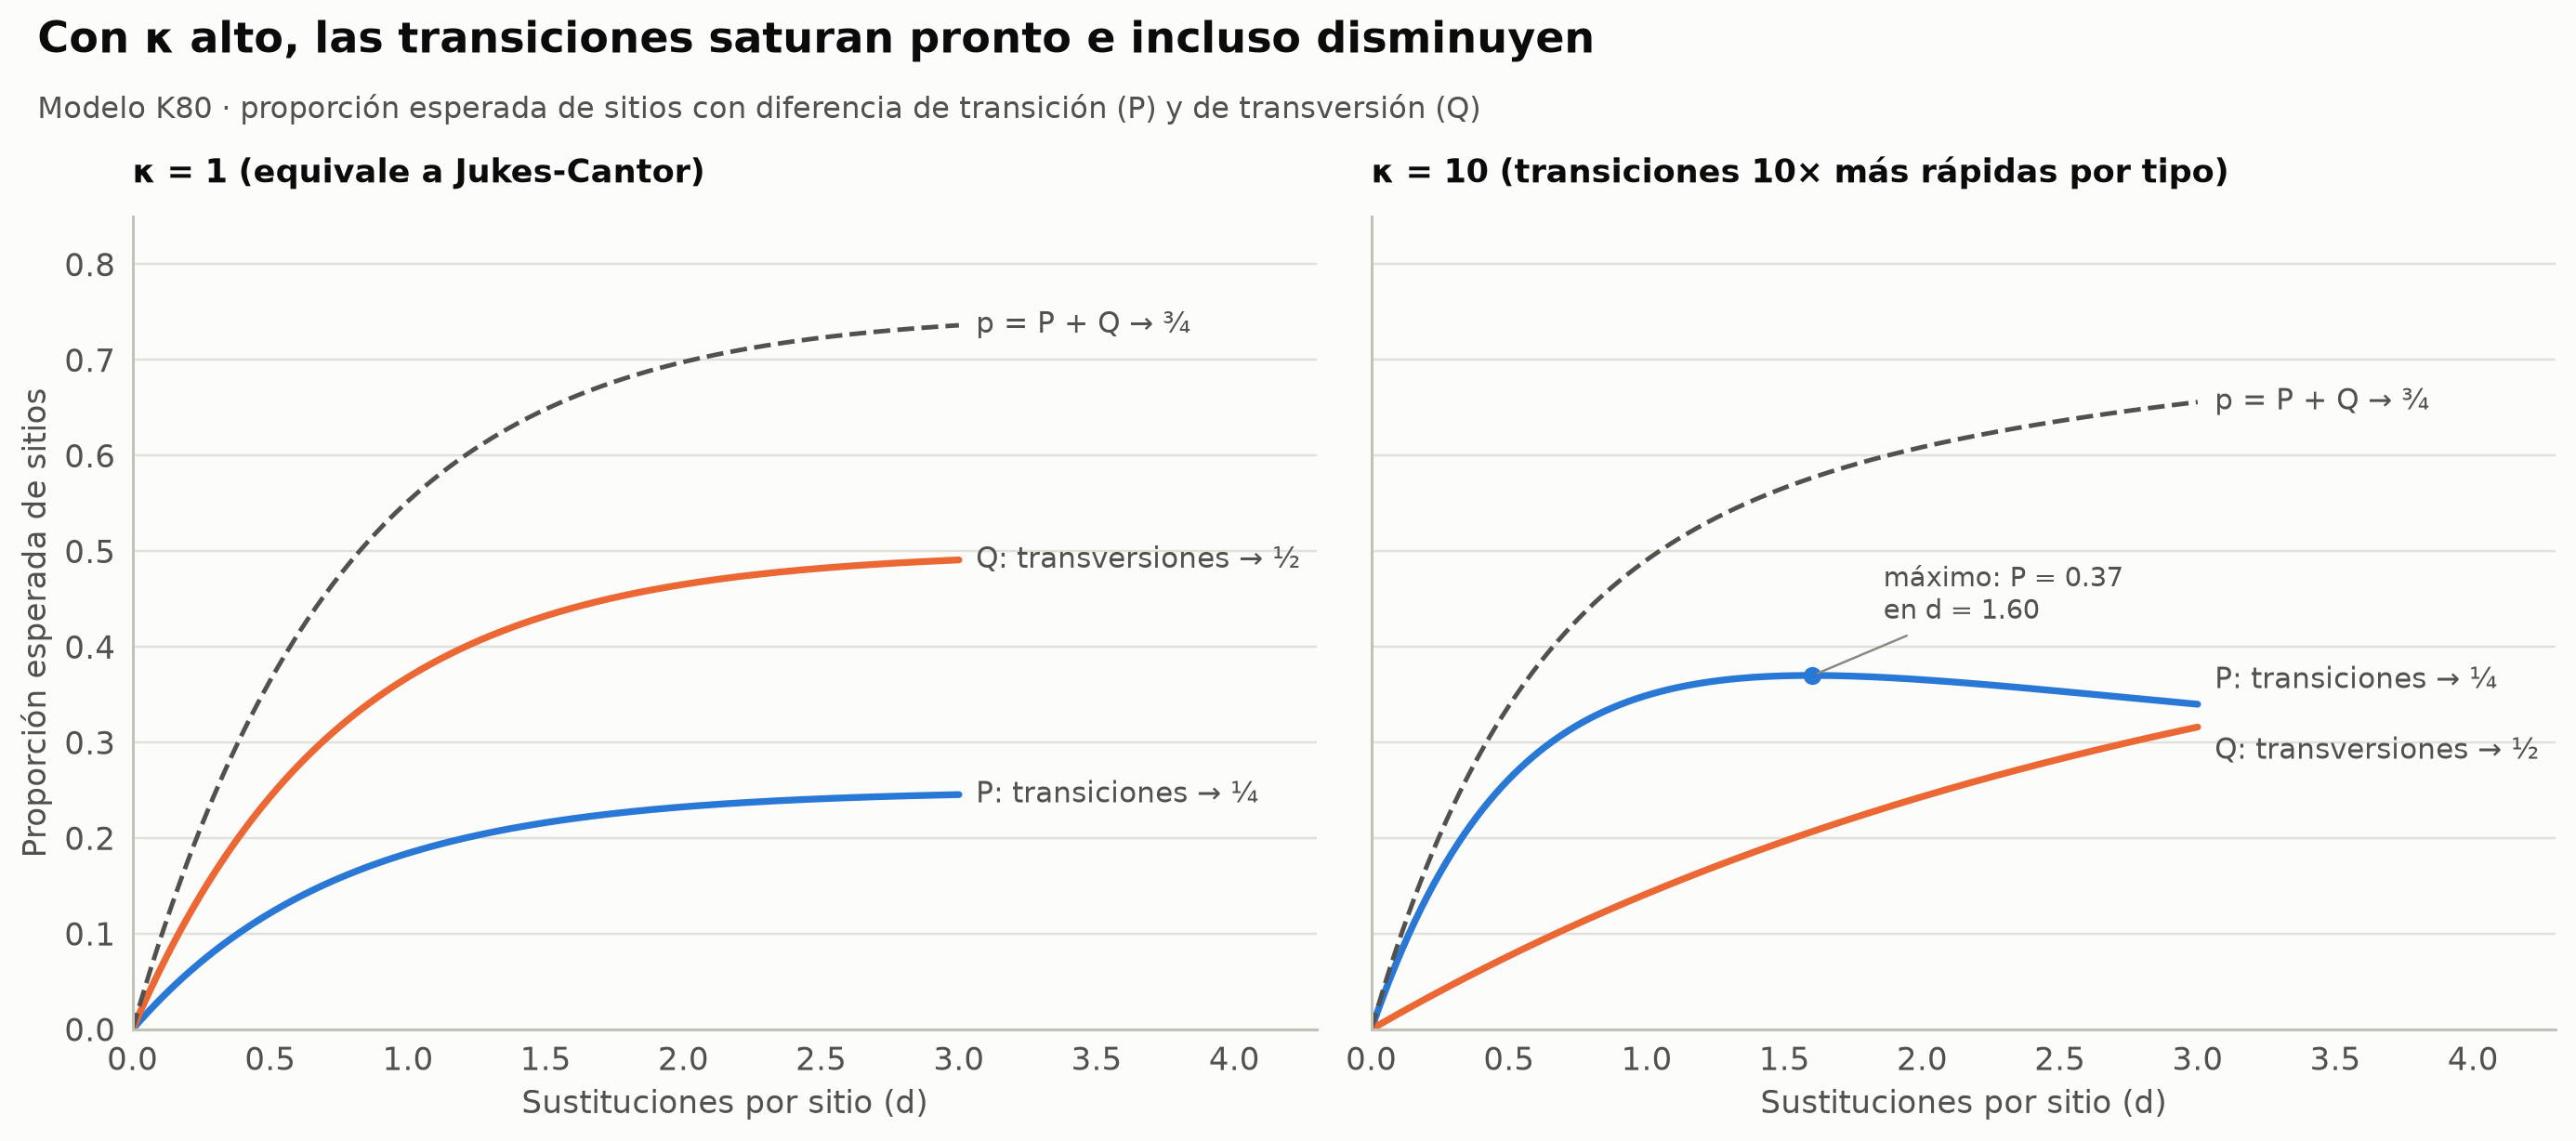

In [11]:
d_grid = np.linspace(0, 3, 400)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
for ax, kappa in zip(axes, [1, 10]):
    same, ts_, tv_ = k80_probs(d_grid, kappa)
    ax.plot(d_grid, ts_, color=ec.BLUE, lw=2.4)
    ax.plot(d_grid, tv_, color=ec.ORANGE, lw=2.4)
    ax.plot(d_grid, ts_ + tv_, color=ec.INK_2, lw=1.6, ls="--")
    gap = 0.025 if abs(ts_[-1] - tv_[-1]) < 0.05 else 0
    ec.label_end(ax, d_grid[-1], ts_[-1] + gap, "P: transiciones → ¼")
    ec.label_end(ax, d_grid[-1], tv_[-1] - gap, "Q: transversiones → ½")
    ec.label_end(ax, d_grid[-1], (ts_ + tv_)[-1], "p = P + Q → ¾")
    if kappa > 1:
        k = ts_.argmax()
        ax.scatter([d_grid[k]], [ts_[k]], color=ec.BLUE, s=40, zorder=3)
        ax.annotate(f"máximo: P = {ts_[k]:.2f}\nen d = {d_grid[k]:.2f}", (d_grid[k], ts_[k]), xytext=(25, 20),
                    textcoords="offset points", fontsize=9.5, color=ec.INK_2,
                    arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=0.8))
    ax.set_xlim(0, 4.3); ax.set_ylim(0, 0.85)
    ax.set_xlabel("Sustituciones por sitio (d)")
    ax.set_title(f"κ = {kappa}" + (" (equivale a Jukes-Cantor)" if kappa == 1 else " (transiciones 10× más rápidas por tipo)"),
                 loc="left", fontsize=11.5)
axes[0].set_ylabel("Proporción esperada de sitios")
ec.fig_title(fig, "Con κ alto, las transiciones saturan pronto e incluso disminuyen",
             "Modelo K80 · proporción esperada de sitios con diferencia de transición (P) y de transversión (Q)")
plt.show()

> 🔎 **Qué observamos.** Con $\kappa = 1$ las transversiones son siempre el doble que las transiciones (hay el doble de
> tipos). Con $\kappa = 10$ las transiciones dominan al principio, alcanzan un **máximo** y luego **bajan**: los sitios
> que ya tenían una transición reciben transversiones y pasan a contarse del otro lado. En datos reales, un cociente
> $P/Q$ que cae al comparar especies cada vez más lejanas es una firma clásica de saturación. Lo veremos con los
> coronavirus.

### 🎬 Animación: la matriz $P(t)$ se "funde" hacia el equilibrio

Veamos la matriz completa $P(t)$ de K80 con $\kappa = 10$ mientras $d$ crece de 0 a 3 sustituciones por sitio. Al
principio es la identidad (nada cambió). Primero se "encienden" las casillas de transición (A↔G, C↔T) y sólo después
las de transversión, hasta que todas las casillas valen ¼.

![La matriz P(t) del modelo K80 (κ = 10) pasa de la identidad a ¼ en todas las casillas; las transiciones se llenan primero](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-05-filogenetica/5.1_pt_kimura.gif)

*La matriz P(t) del modelo K80 (κ = 10) pasa de la identidad a ¼ en todas las casillas; las transiciones se llenan primero*

In [12]:
KAPPA_ANIM = 10
d_frames = np.r_[0, np.geomspace(0.01, 3, 44)]
fig = plt.figure(figsize=(12, 5.2))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.84))       # deja libre la franja del título (el GIF no se recorta)
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.35], wspace=0.28)
ax_m, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
im = ax_m.imshow(np.eye(4), cmap=ec.CMAP_SEQ, vmin=0, vmax=1)
cell_txt = [[ax_m.text(j, i, "", ha="center", va="center", fontsize=12) for j in range(4)] for i in range(4)]
ax_m.set_xticks(range(4), list(BASES)); ax_m.set_yticks(range(4), list(BASES))
for lbl in ax_m.get_xticklabels() + ax_m.get_yticklabels():
    lbl.set_color(ec.NUC_COLORS[lbl.get_text()]); lbl.set_fontweight("bold"); lbl.set_fontsize(13)
ax_m.set_xlabel("base al tiempo t"); ax_m.set_ylabel("base inicial"); ax_m.grid(False)
for (i, j) in [(0, 2), (2, 0), (1, 3), (3, 1)]:
    ax_m.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, ec=ec.ORANGE, lw=2.2))
ax_m.set_title("P(t); recuadro naranja: transiciones", loc="left", fontsize=11)
same_c, ts_c, tv_c = k80_probs(d_grid, KAPPA_ANIM)
ax_c.plot(d_grid, same_c, color=ec.INK_2, lw=2)
ax_c.plot(d_grid, ts_c, color=ec.BLUE, lw=2)
ax_c.plot(d_grid, tv_c / 2, color=ec.ORANGE, lw=2)
ax_c.axhline(0.25, color=ec.MUTED, lw=1, ls=":")
ec.label_end(ax_c, 3, same_c[-1] + 0.035, "P_AA: sigue igual")
ec.label_end(ax_c, 3, ts_c[-1] - 0.03, "P_AG: transición")
ec.label_end(ax_c, 3, tv_c[-1] / 2 - 0.04, "P_AC: transversión")
ax_c.set_xlim(0, 3.9); ax_c.set_ylim(0, 1.02)
ax_c.set_xlabel("Sustituciones por sitio (d)"); ax_c.set_ylabel("Probabilidad")
marker = ax_c.axvline(0, color=ec.INK, lw=1.2)
dots = ax_c.scatter([0, 0, 0], [1, 0, 0], s=40, color=[ec.INK_2, ec.BLUE, ec.ORANGE], zorder=4)
status = ax_c.text(0.02, 1.05, "", transform=ax_c.transAxes, fontsize=11, color=ec.INK)
fig.text(0.01, 0.965, "Las transiciones cambian primero; al final todas las casillas valen ¼",
         fontsize=15, fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.905, f"Modelo de Kimura con κ = {KAPPA_ANIM} · P(t) = expm(Qt) evaluada en 45 valores de d",
         fontsize=10.5, color=ec.INK_2, va="top")

def update(f):
    d = d_frames[f]
    Pt = expm(k80_Q(KAPPA_ANIM) * d / (KAPPA_ANIM + 2))
    im.set_data(Pt)
    for i in range(4):
        for j in range(4):
            cell_txt[i][j].set_text(f"{Pt[i, j]:.2f}")
            cell_txt[i][j].set_color("white" if Pt[i, j] > 0.55 else ec.INK)
    marker.set_xdata([d, d])
    dots.set_offsets(np.c_[[d] * 3, [Pt[0, 0], Pt[0, 2], Pt[0, 1]]])
    status.set_text(f"d = {d:.2f} sustituciones por sitio")
    return [im, marker, dots, status]

fig.canvas.draw()                                     # fija la disposición antes del primer cuadro
with plt.rc_context({"savefig.bbox": None}):         # cuadros del mismo tamaño y sin recorte
    anim_html = ec.animate(fig, update, frames=len(d_frames), interval=150, name="5.1_pt_kimura")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Hacia $d \approx 0.3$ la casilla A→G ya vale ~0.19 mientras que A→C apenas llega a 0.02.
> Hacia $d \approx 3$ todas las casillas se parecen a ¼: el sitio perdió la memoria de su base inicial.

### Explorador interactivo de $P(t)$ en JC69 y K80

Mueva los dos deslizadores: el de arriba elige $\kappa$ ($\kappa = 1$ es Jukes-Cantor) y el de abajo la distancia $d$.
A la izquierda, las curvas de probabilidad de "igual", "transición" y "transversión" (la línea vertical marca $d$); a
la derecha, la matriz $P(t)$ completa. Pase el cursor por las casillas para ver el tipo de cambio y su probabilidad.

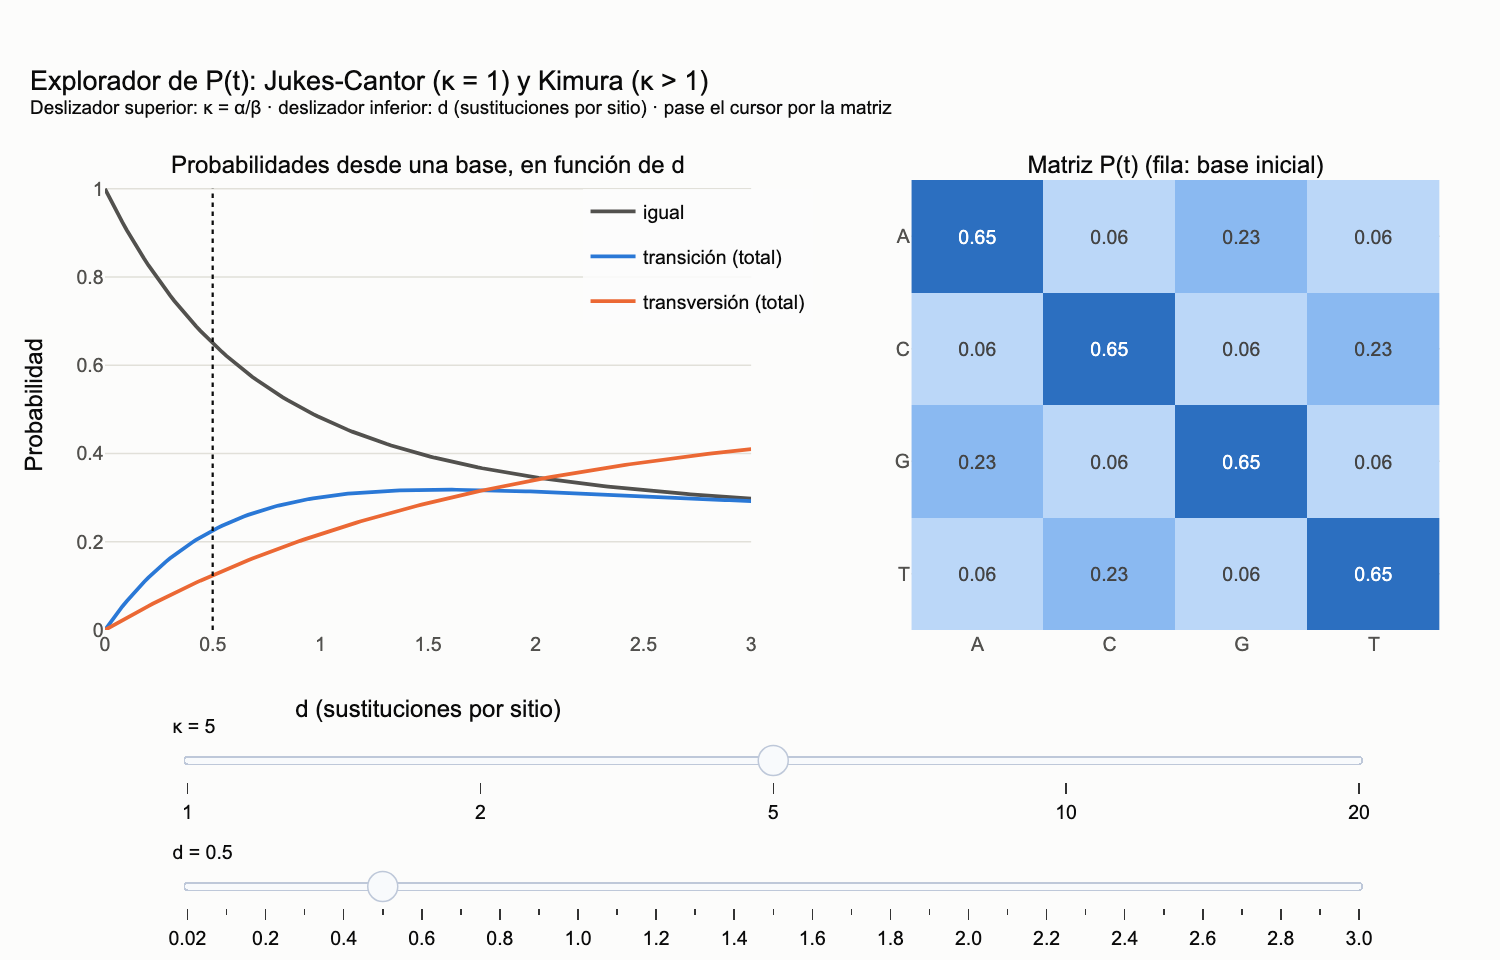

In [13]:
KAPPAS = [1, 2, 5, 10, 20]
D_STEPS = np.round(np.r_[0.02, np.arange(0.1, 3.01, 0.1)], 2)
d_curve = np.linspace(0, 3, 150)
kind = [["igual" if i == j else ("transición" if (BASES[i], BASES[j]) in TRANSITION else "transversión")
         for j in range(4)] for i in range(4)]
d0, k0 = 0.5, 5

def P_of(d, kappa):
    return expm(k80_Q(kappa) * d / (kappa + 2))

fig = make_subplots(rows=1, cols=2, column_widths=[0.55, 0.45], horizontal_spacing=0.12,
                    subplot_titles=("Probabilidades desde una base, en función de d", "Matriz P(t) (fila: base inicial)"))
n_per = 4                                                  # trazas por κ: 3 curvas + 1 mapa de calor
for kappa in KAPPAS:
    same, ts_, tv_ = k80_probs(d_curve, kappa)
    vis = kappa == k0
    for y, name, col in [(same, "igual", ec.INK_2), (ts_, "transición (total)", ec.BLUE),
                         (tv_, "transversión (total)", ec.ORANGE)]:
        fig.add_trace(go.Scatter(x=d_curve, y=y, name=name, line=dict(color=col, width=2.5), visible=vis,
                                 legendgroup=name,     # sólo un grupo de κ está visible: 3 entradas en la leyenda
                                 hovertemplate=f"κ = {kappa}<br>d = %{{x:.2f}}<br>P({name}) = %{{y:.3f}}<extra></extra>"),
                      row=1, col=1)
    fig.add_trace(go.Heatmap(z=P_of(d0, kappa), x=list(BASES), y=list(BASES), zmin=0, zmax=1, visible=vis,
                             colorscale=[[0, ec.SEQ_BLUE[0]], [0.5, ec.SEQ_BLUE[6]], [1, ec.SEQ_BLUE[12]]],
                             texttemplate="%{z:.2f}", customdata=kind, showscale=False,
                             hovertemplate=(f"κ = {kappa}<br>%{{y}} → %{{x}} (%{{customdata}})"
                                            "<br>P = %{z:.3f}<extra></extra>")),
                  row=1, col=2)
line_shape = dict(type="line", xref="x", yref="y", x0=d0, x1=d0, y0=0, y1=1, line=dict(color=ec.INK, width=1.5, dash="dot"))

heat_idx = [i * n_per + 3 for i in range(len(KAPPAS))]
kappa_steps = [dict(method="restyle", label=str(kappa),
                    args=[{"visible": [i // n_per == k for i in range(len(fig.data))]}])
               for k, kappa in enumerate(KAPPAS)]
d_steps = [dict(method="update", label=f"{d:.1f}" if d >= 0.1 else f"{d:.2f}",
                args=[{"z": [P_of(d, kappa) for kappa in KAPPAS]},
                      {"shapes": [dict(line_shape, x0=d, x1=d)]}, heat_idx])
           for d in D_STEPS]
fig.update_layout(
    title=dict(text="Explorador de P(t): Jukes-Cantor (κ = 1) y Kimura (κ > 1)<br>"
                    "<sup>Deslizador superior: κ = α/β · deslizador inferior: d (sustituciones por sitio) · pase el cursor por la matriz</sup>"),
    shapes=[line_shape], height=640, margin=dict(t=120, b=190, l=70, r=40),
    legend=dict(yanchor="top", y=0.98, x=0.53, xanchor="right", bgcolor="rgba(252,252,251,0.85)"),
    sliders=[dict(active=KAPPAS.index(k0), steps=kappa_steps, currentvalue=dict(prefix="κ = "),
                  x=0.05, len=0.9, y=-0.14, pad=dict(t=10)),
             dict(active=int(np.argmin(abs(D_STEPS - d0))), steps=d_steps, currentvalue=dict(prefix="d = "),
                  x=0.05, len=0.9, y=-0.42, pad=dict(t=10))])
fig.update_xaxes(title_text="d (sustituciones por sitio)", range=[0, 3], row=1, col=1)
fig.update_yaxes(title_text="Probabilidad", range=[0, 1.02], row=1, col=1)
fig.update_yaxes(autorange="reversed", row=1, col=2)
fig.show()

> 🔎 **Qué observamos.** Pruebe $\kappa = 20$ y mueva $d$: la curva azul (transición) sube rápido, toca un máximo
> y luego baja, mientras que la naranja (transversión) sube lenta pero sin parar. En la matriz, con
> $d = 0.5$, las casillas A→G y C→T ya son mucho más oscuras que las de transversión. Con $\kappa = 1$ (JC69) las doce
> casillas fuera de la diagonal son siempre iguales.

✅ **Compruebe su comprensión.** Calcule $d_{K80}$ para dos pares de secuencias: (a) $P = 0.20$, $Q = 0.30$;
(b) $P = 0.35$, $Q = 0.35$. (Respuesta: (a) $1 - 2P - Q = 0.30$ y $1 - 2Q = 0.40$, así que
$d = -\tfrac12\ln 0.3 - \tfrac14\ln 0.4 = 0.602 + 0.229 = 0.831$. (b) $1 - 2P - Q = -0.05 < 0$: el logaritmo no
existe, las secuencias están saturadas y la distancia es indefinida.)

## 6. La familia de modelos: F81, HKY85, TN93 y GTR

JC69 y K80 suponen que las cuatro bases son igual de frecuentes. Pero muchos genomas son ricos en AT (el de
*Plasmodium falciparum* tiene ~80 % de A+T) o en GC (el de *Streptomyces*, ~72 % de G+C). Los modelos siguientes
añaden, paso a paso, más realismo. Todos se escriben con la misma receta:

$$
q_{ij} \;=\; r_{ij}\,\pi_j \quad (i \neq j),
\qquad\qquad
\pi_i\,q_{ij} = \pi_j\,q_{ji}\ \ \text{(reversibilidad)}
$$

| Símbolo | Significado |
|---|---|
| $\pi_j$ | frecuencia de equilibrio de la base de llegada $j$: cambiar **hacia** una base frecuente es más fácil |
| $r_{ij} = r_{ji}$ | "intercambiabilidad" entre $i$ y $j$: lo propio de cada tipo de cambio |
| reversibilidad | en equilibrio, el flujo $i \to j$ es igual al flujo $j \to i$: el proceso se ve igual hacia adelante y hacia atrás en el tiempo |

| Modelo | Frecuencias $\pi$ | Intercambiabilidades $r_{ij}$ | Parámetros libres del modelo | Referencia |
|---|---|---|---|---|
| **JC69** | iguales (¼) | todas iguales | 0 | Jukes y Cantor (1969) |
| **K80** | iguales | transición $\kappa$, transversión 1 | 1 ($\kappa$) | Kimura (1980) |
| **F81** | libres | todas iguales | 3 ($\pi$) | Felsenstein (1981) |
| **HKY85** | libres | transición $\kappa$, transversión 1 | 4 ($\pi$, $\kappa$) | Hasegawa, Kishino y Yano (1985) |
| **TN93** | libres | A↔G $\kappa_1$, C↔T $\kappa_2$, transversión 1 | 5 | Tamura y Nei (1993) |
| **GTR** | libres | seis valores distintos | 8 ($\pi$ y 5 de las 6 $r_{ij}$) | Tavaré (1986) |

(Los parámetros cuentan sólo el modelo; a eso se suman las longitudes de las ramas del árbol.) Por convención, $Q$ se
**normaliza** para que la tasa media sea 1, $-\sum_i \pi_i q_{ii} = 1$; así el tiempo $t$ se mide directamente en
sustituciones esperadas por sitio, $d = t$.

In [14]:
def gtr_Q(rates, pi):
    """Matriz de tasas GTR normalizada (tasa media 1). rates: intercambiabilidades en el orden
    AC, AG, AT, CG, CT, GT; pi: frecuencias de A, C, G, T."""
    pi = np.asarray(pi, float); R = np.zeros((4, 4))
    for (i, j), r in zip(itertools.combinations(range(4), 2), rates):
        R[i, j] = R[j, i] = r
    Q = R * pi[None, :]
    np.fill_diagonal(Q, -Q.sum(axis=1))
    return Q / -(pi * np.diag(Q)).sum()

EQUAL = [0.25] * 4
PI_GC = [0.15, 0.35, 0.35, 0.15]
models = {                                   # AC, AG, AT, CG, CT, GT
    "JC69":  gtr_Q([1, 1, 1, 1, 1, 1], EQUAL),
    "K80 (κ = 4)":   gtr_Q([1, 4, 1, 1, 4, 1], EQUAL),
    "HKY85 (κ = 4, GC 70 %)": gtr_Q([1, 4, 1, 1, 4, 1], PI_GC),
    "GTR (GC 70 %)": gtr_Q([1.2, 3.1, 0.6, 0.9, 5.4, 1.0], PI_GC),
}
for name, Qm in models.items():
    pi_m = np.linalg.lstsq(np.vstack([Qm.T, np.ones(4)]), np.r_[np.zeros(4), 1], rcond=None)[0]
    rev = np.allclose(pi_m[:, None] * Qm, (pi_m[:, None] * Qm).T)
    print(f"{name:>24}: tasa media = {-(pi_m * np.diag(Qm)).sum():.2f} · π = {np.round(pi_m, 2)} · reversible: {rev}")
print("\nK80 construido como GTR = K80 de la sección 5 (normalizado):",
      np.allclose(models["K80 (κ = 4)"], k80_Q(4) / (4 + 2)))

                    JC69: tasa media = 1.00 · π = [0.25 0.25 0.25 0.25] · reversible: True
             K80 (κ = 4): tasa media = 1.00 · π = [0.25 0.25 0.25 0.25] · reversible: True
  HKY85 (κ = 4, GC 70 %): tasa media = 1.00 · π = [0.15 0.35 0.35 0.15] · reversible: True
           GTR (GC 70 %): tasa media = 1.00 · π = [0.15 0.35 0.35 0.15] · reversible: True

K80 construido como GTR = K80 de la sección 5 (normalizado): True


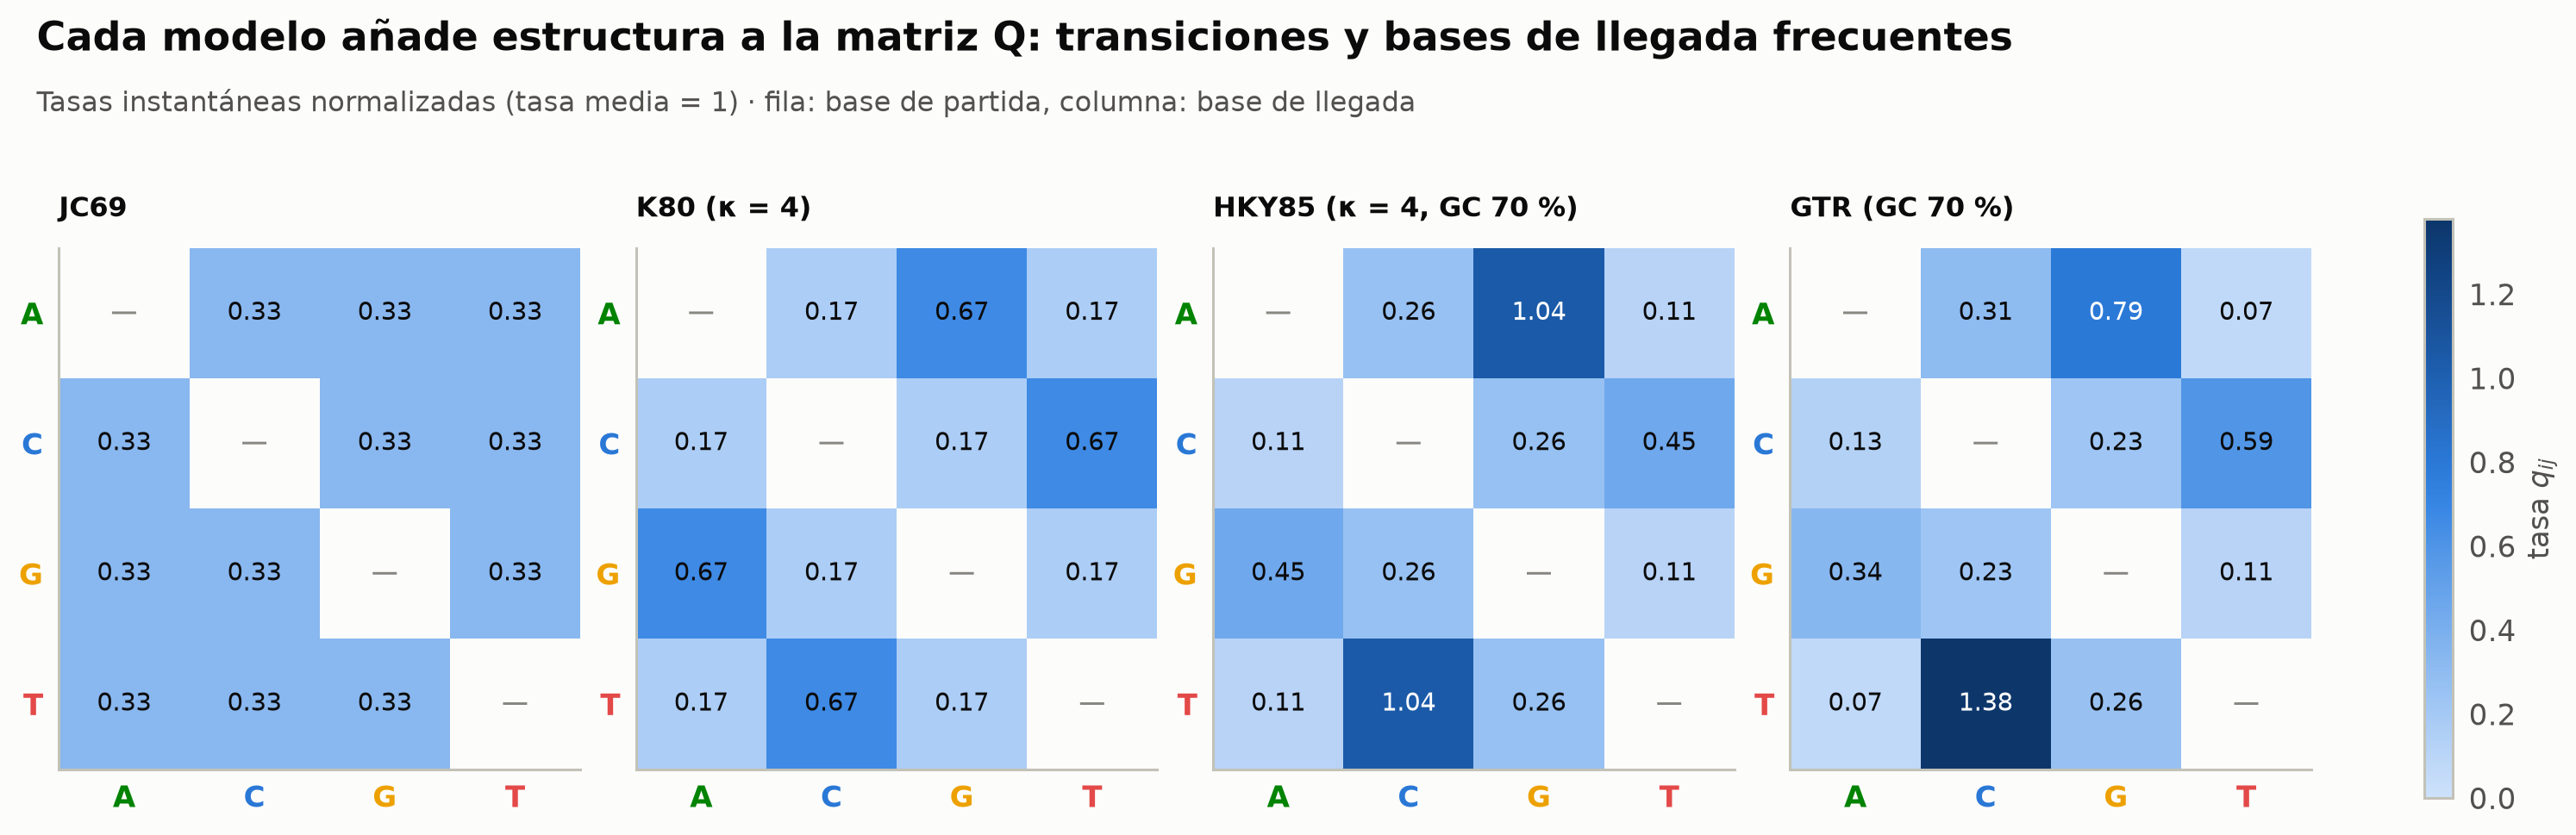

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.9))
vmax = max((Qm - np.diag(np.diag(Qm))).max() for Qm in models.values())
for ax, (name, Qm) in zip(axes, models.items()):
    off = Qm.copy(); np.fill_diagonal(off, np.nan)
    im = ax.imshow(off, cmap=ec.CMAP_SEQ, vmin=0, vmax=vmax)
    for i in range(4):
        for j in range(4):
            if i != j:
                ax.text(j, i, f"{Qm[i, j]:.2f}", ha="center", va="center", fontsize=9.5,
                        color="white" if Qm[i, j] > 0.55 * vmax else ec.INK)
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=10, color=ec.MUTED)
    ax.set_xticks(range(4), list(BASES)); ax.set_yticks(range(4), list(BASES))
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(ec.NUC_COLORS[lbl.get_text()]); lbl.set_fontweight("bold")
    ax.grid(False); ax.set_title(name, fontsize=10.5, loc="left")
fig.colorbar(im, ax=axes, shrink=0.8, label="tasa $q_{ij}$")
ec.fig_title(fig, "Cada modelo añade estructura a la matriz Q: transiciones y bases de llegada frecuentes",
             "Tasas instantáneas normalizadas (tasa media = 1) · fila: base de partida, columna: base de llegada")
plt.show()

> 🔎 **Qué observamos.** En JC69 las doce tasas son iguales (1/3). En K80 las casillas A↔G y C↔T son cuatro veces
> más altas. En HKY85, además, las **columnas** de C y G son más oscuras: cambiar **hacia** C o G es más probable,
> porque son las bases frecuentes. Por eso $Q$ deja de ser simétrica (compare $q_{AG}$ con $q_{GA}$), aunque el
> proceso siga siendo reversible. GTR permite además que cada par tenga su propia intercambiabilidad.

Los modelos forman una **jerarquía anidada**: cada uno es un caso particular del siguiente (K80 es HKY85 con $\pi$
iguales; HKY85 es TN93 con $\kappa_1 = \kappa_2$…). Eso permite compararlos con una prueba de razón de verosimilitudes
o con criterios como AIC/BIC, que es lo que hacen programas como ModelTest o ModelFinder (en IQ-TREE). Lo veremos en la
lección de máxima verosimilitud.

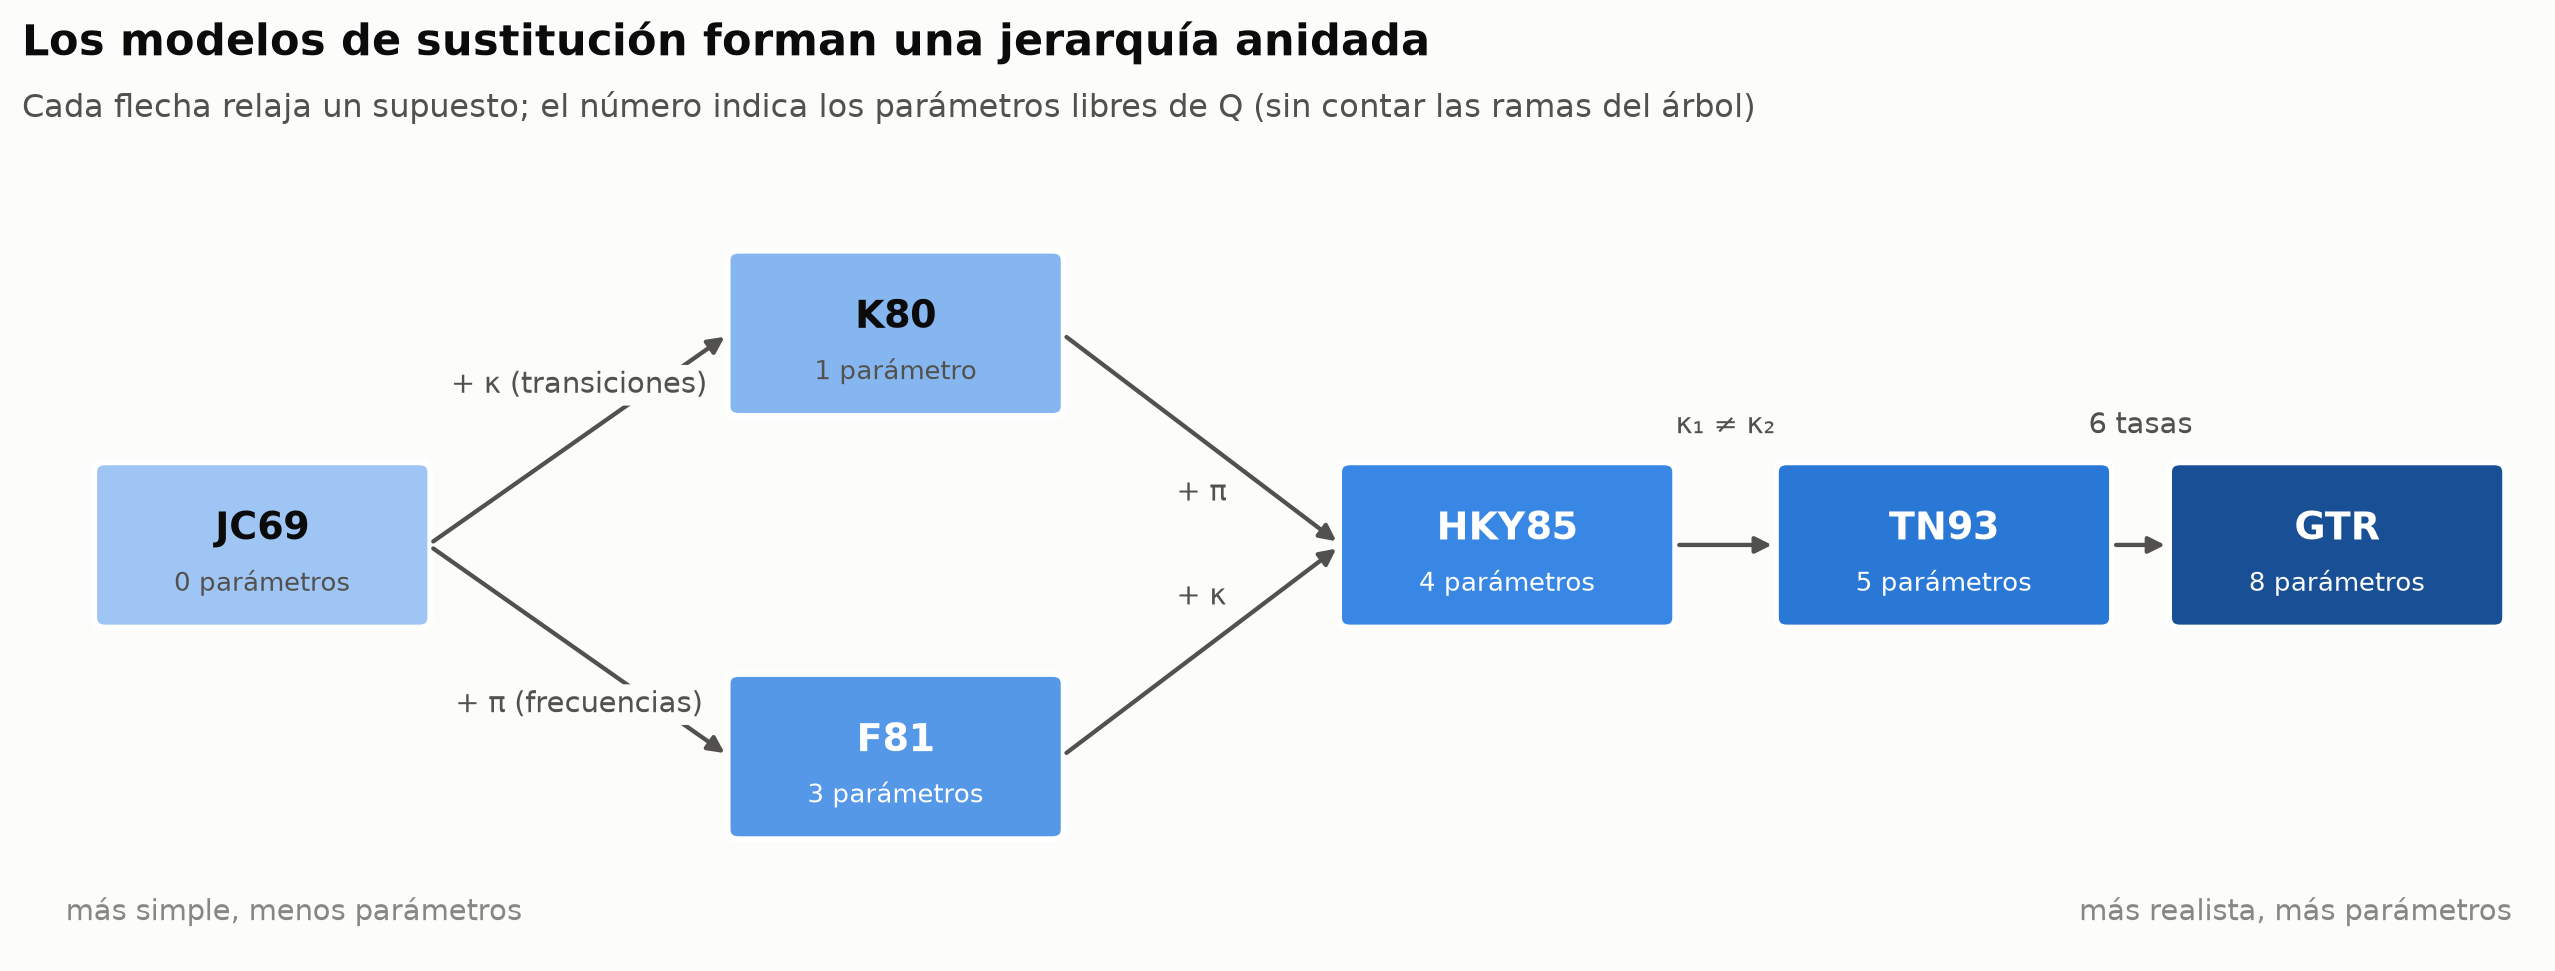

In [16]:
fig, ax = plt.subplots(figsize=(11.5, 4.3))
ax.set_xlim(0, 11.5); ax.set_ylim(0.2, 4.4); ax.axis("off")
nodes = {"JC69": (1.1, 2.3, 0), "K80": (4.0, 3.4, 1), "F81": (4.0, 1.2, 3), "HKY85": (6.8, 2.3, 4),
         "TN93": (8.8, 2.3, 5), "GTR": (10.6, 2.3, 8)}
for name, (x, y, k) in nodes.items():
    ax.add_patch(FancyBboxPatch((x - 0.72, y - 0.38), 1.44, 0.76, boxstyle="round,pad=0.05",
                                fc=ec.SEQ_BLUE[min(12, 2 + k)], ec="white", lw=2))
    ax.text(x, y + 0.08, name, ha="center", va="center", fontsize=12.5, fontweight="bold",
            color="white" if k >= 3 else ec.INK)
    ax.text(x, y - 0.2, f"{k} parámetro{'s' if k != 1 else ''}", ha="center", va="center", fontsize=8.5,
            color="white" if k >= 3 else ec.INK_2)
edges = [("JC69", "K80", "+ κ (transiciones)"), ("JC69", "F81", "+ π (frecuencias)"),
         ("K80", "HKY85", "+ π"), ("F81", "HKY85", "+ κ"),
         ("HKY85", "TN93", "κ₁ ≠ κ₂"), ("TN93", "GTR", "6 tasas")]
for a, b, lbl in edges:
    (x1, y1, _), (x2, y2, _) = nodes[a], nodes[b]
    ax.annotate("", (x2 - 0.76, y2), (x1 + 0.76, y1),
                arrowprops=dict(arrowstyle="-|>", color=ec.INK_2, lw=1.4, shrinkA=2, shrinkB=2))
    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    ax.text(mx, my + (0.62 if y2 == y1 else 0.28 if y2 > y1 else -0.28), lbl, ha="center", va="center", fontsize=9.5, color=ec.INK_2,
            bbox=dict(boxstyle="round,pad=0.2", fc=ec.SURFACE, ec="none"))
ax.text(0.2, 0.35, "más simple, menos parámetros", fontsize=9.5, color=ec.MUTED, ha="left")
ax.text(11.4, 0.35, "más realista, más parámetros", fontsize=9.5, color=ec.MUTED, ha="right")
ec.title(ax, "Los modelos de sustitución forman una jerarquía anidada",
         "Cada flecha relaja un supuesto; el número indica los parámetros libres de Q (sin contar las ramas del árbol)")
plt.show()

## 7. No todos los sitios evolucionan igual: la distribución Gamma

Hasta ahora supusimos que **todos los sitios** cambian con la misma tasa. En un gen real no es así: el sitio activo
de una enzima casi no puede cambiar sin destruir la función, mientras que la tercera posición de muchos codones cambia
libremente sin alterar la proteína. Si mezclamos sitios lentos y rápidos, los rápidos **saturan enseguida** y los
lentos casi no aportan diferencias: la $p$ observada queda todavía más por debajo de lo que JC69 espera.

La solución estándar (Yang, 1993; 1994) es suponer que la tasa relativa $r$ de cada sitio es una variable aleatoria
con distribución **Gamma** de media 1:

$$
g(r;\alpha) \;=\; \frac{\alpha^\alpha}{\Gamma(\alpha)}\, r^{\alpha - 1}\, e^{-\alpha r},
\qquad \mathbb{E}[r] = 1, \qquad \operatorname{Var}[r] = \frac{1}{\alpha}
$$

| Símbolo | Significado |
|---|---|
| $r$ | tasa relativa de un sitio (1 = tasa promedio del gen) |
| $\alpha$ | parámetro de **forma**: $\alpha$ pequeño (< 1) = mucha heterogeneidad (la mayoría de sitios casi invariables y unos pocos muy rápidos); $\alpha \to \infty$ = todos iguales |
| $\Gamma(\alpha)$ | la función gamma, sólo una constante de normalización |

Con tasas Gamma, la corrección de Jukes-Cantor se convierte en la distancia **JC69+Γ**:

$$
d_{JC+\Gamma} \;=\; \tfrac34\,\alpha\left[\left(1 - \tfrac43\,p\right)^{-1/\alpha} - 1\right]
$$

**Ejemplo a mano.** Con $p = 0.30$ y $\alpha = 0.5$: $(1 - 0.4)^{-2} = 2.778$, así que
$d = 0.75 \times 0.5 \times 1.778 = 0.667$. Sin la corrección Gamma, JC69 da $-0.75\ln 0.6 = 0.383$: ¡casi la mitad!

In [17]:
def jc_gamma_distance(p, alpha):
    p = np.asarray(p, float)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(p < 0.75, 0.75 * alpha * ((1 - 4 * p / 3) ** (-1 / alpha) - 1), np.inf)

def discrete_gamma(alpha, K=4):
    """Tasas medias de K categorías de igual probabilidad (método de Yang 1994)."""
    bounds = stats.gamma.ppf(np.linspace(0, 1, K + 1), a=alpha, scale=1 / alpha)
    cdf1 = gammainc(alpha + 1, alpha * bounds)             # P(r < b) para una Gamma(α + 1, 1/α)
    return K * np.diff(cdf1)

print(f"Ejemplo a mano: d_JC+Γ(p=0.3, α=0.5) = {jc_gamma_distance(0.3, 0.5):.3f} · d_JC = {jc_distance(0.3):.3f}")
for a in [0.2, 0.5, 1, 2]:
    r = discrete_gamma(a)
    print(f"α = {a:>3}: tasas de 4 categorías = {np.round(r, 3)} · media = {r.mean():.3f}")

Ejemplo a mano: d_JC+Γ(p=0.3, α=0.5) = 0.667 · d_JC = 0.383
α = 0.2: tasas de 4 categorías = [1.000e-03 3.400e-02 3.840e-01 3.582e+00] · media = 1.000
α = 0.5: tasas de 4 categorías = [0.033 0.252 0.82  2.894] · media = 1.000
α =   1: tasas de 4 categorías = [0.137 0.477 1.    2.386] · media = 1.000
α =   2: tasas de 4 categorías = [0.293 0.655 1.07  1.982] · media = 1.000


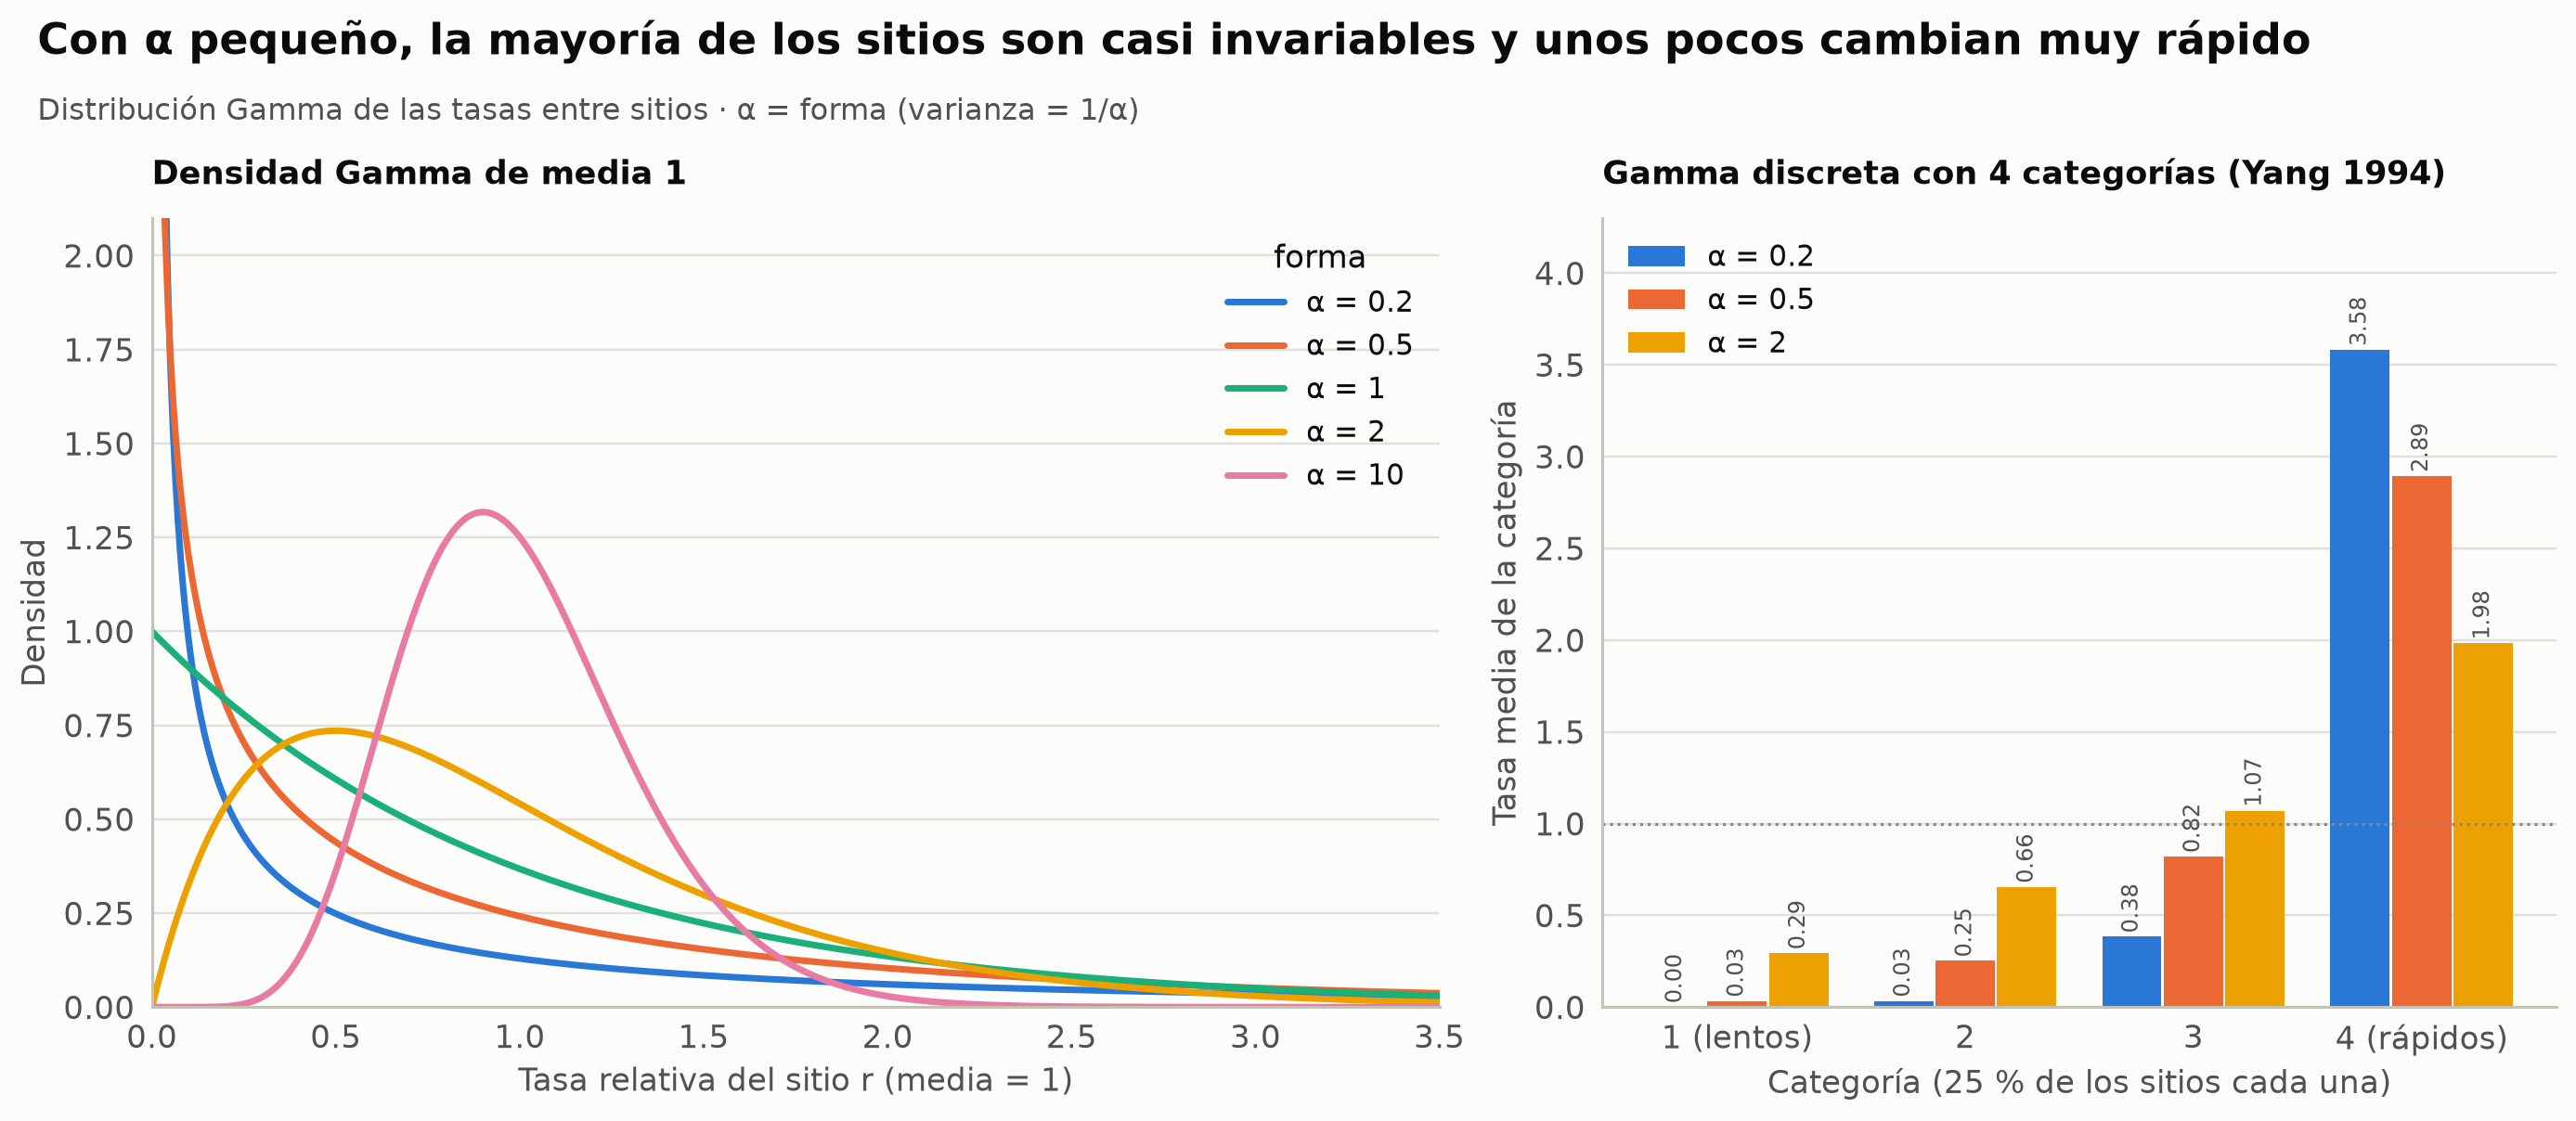

In [18]:
r_grid = np.linspace(0.001, 3.5, 500)
alphas = [0.2, 0.5, 1, 2, 10]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.7), width_ratios=[1.35, 1])
ax = axes[0]
for a, col in zip(alphas, ec.CATEGORICAL):
    dens = stats.gamma.pdf(r_grid, a=a, scale=1 / a)
    ax.plot(r_grid, dens, color=col, lw=2.3, label=f"α = {a}")
ax.legend(loc="upper right", title="forma")
ax.set_ylim(0, 2.1); ax.set_xlim(0, 3.5)
ax.set_xlabel("Tasa relativa del sitio r (media = 1)"); ax.set_ylabel("Densidad")
ax.set_title("Densidad Gamma de media 1", loc="left", fontsize=11.5)

ax = axes[1]
K = 4
for n, a in enumerate([0.2, 0.5, 2]):
    rates = discrete_gamma(a, K)
    ax.bar(np.arange(K) + (n - 1) * 0.27, rates, width=0.26, color=ec.CATEGORICAL[[0, 1, 3][n]],
           label=f"α = {a}")
    for k_, r in enumerate(rates):
        ax.text(k_ + (n - 1) * 0.27, r + 0.05, f"{r:.2f}", ha="center", fontsize=8, color=ec.INK_2, rotation=90)
ax.axhline(1, color=ec.MUTED, lw=1, ls=":")
ax.set_xticks(range(K), ["1 (lentos)", "2", "3", "4 (rápidos)"]); ax.set_ylim(0, 4.3)
ax.set_xlabel("Categoría (25 % de los sitios cada una)"); ax.set_ylabel("Tasa media de la categoría")
ax.legend(loc="upper left"); ax.grid(axis="x", visible=False)
ax.set_title("Gamma discreta con 4 categorías (Yang 1994)", loc="left", fontsize=11.5)
ec.fig_title(fig, "Con α pequeño, la mayoría de los sitios son casi invariables y unos pocos cambian muy rápido",
             "Distribución Gamma de las tasas entre sitios · α = forma (varianza = 1/α)")
plt.show()

> 🔎 **Qué observamos.** Con $\alpha = 10$ casi todos los sitios tienen tasa cercana a 1 (la campana alrededor de 1).
> Con $\alpha = 0.2$ la densidad se dispara cerca de 0: el 25 % más lento de los sitios tiene una tasa media de
> ~0.001 (en la práctica, invariables) y el 25 % más rápido una tasa ~3.6 veces el promedio. Los programas de
> filogenia usan estas 4 categorías discretas (el famoso "+G4" de modelos como GTR+G4) en vez de la distribución
> continua, porque así la verosimilitud se calcula con sólo 4 sumandos por sitio.

> 🤔 **Antes de ejecutar, prediga:** si simulamos un gen cuyos sitios tienen tasas Gamma con $\alpha = 0.5$ y le
> aplicamos la corrección JC69 **sin** Gamma, ¿sobrestimará o subestimará la distancia?

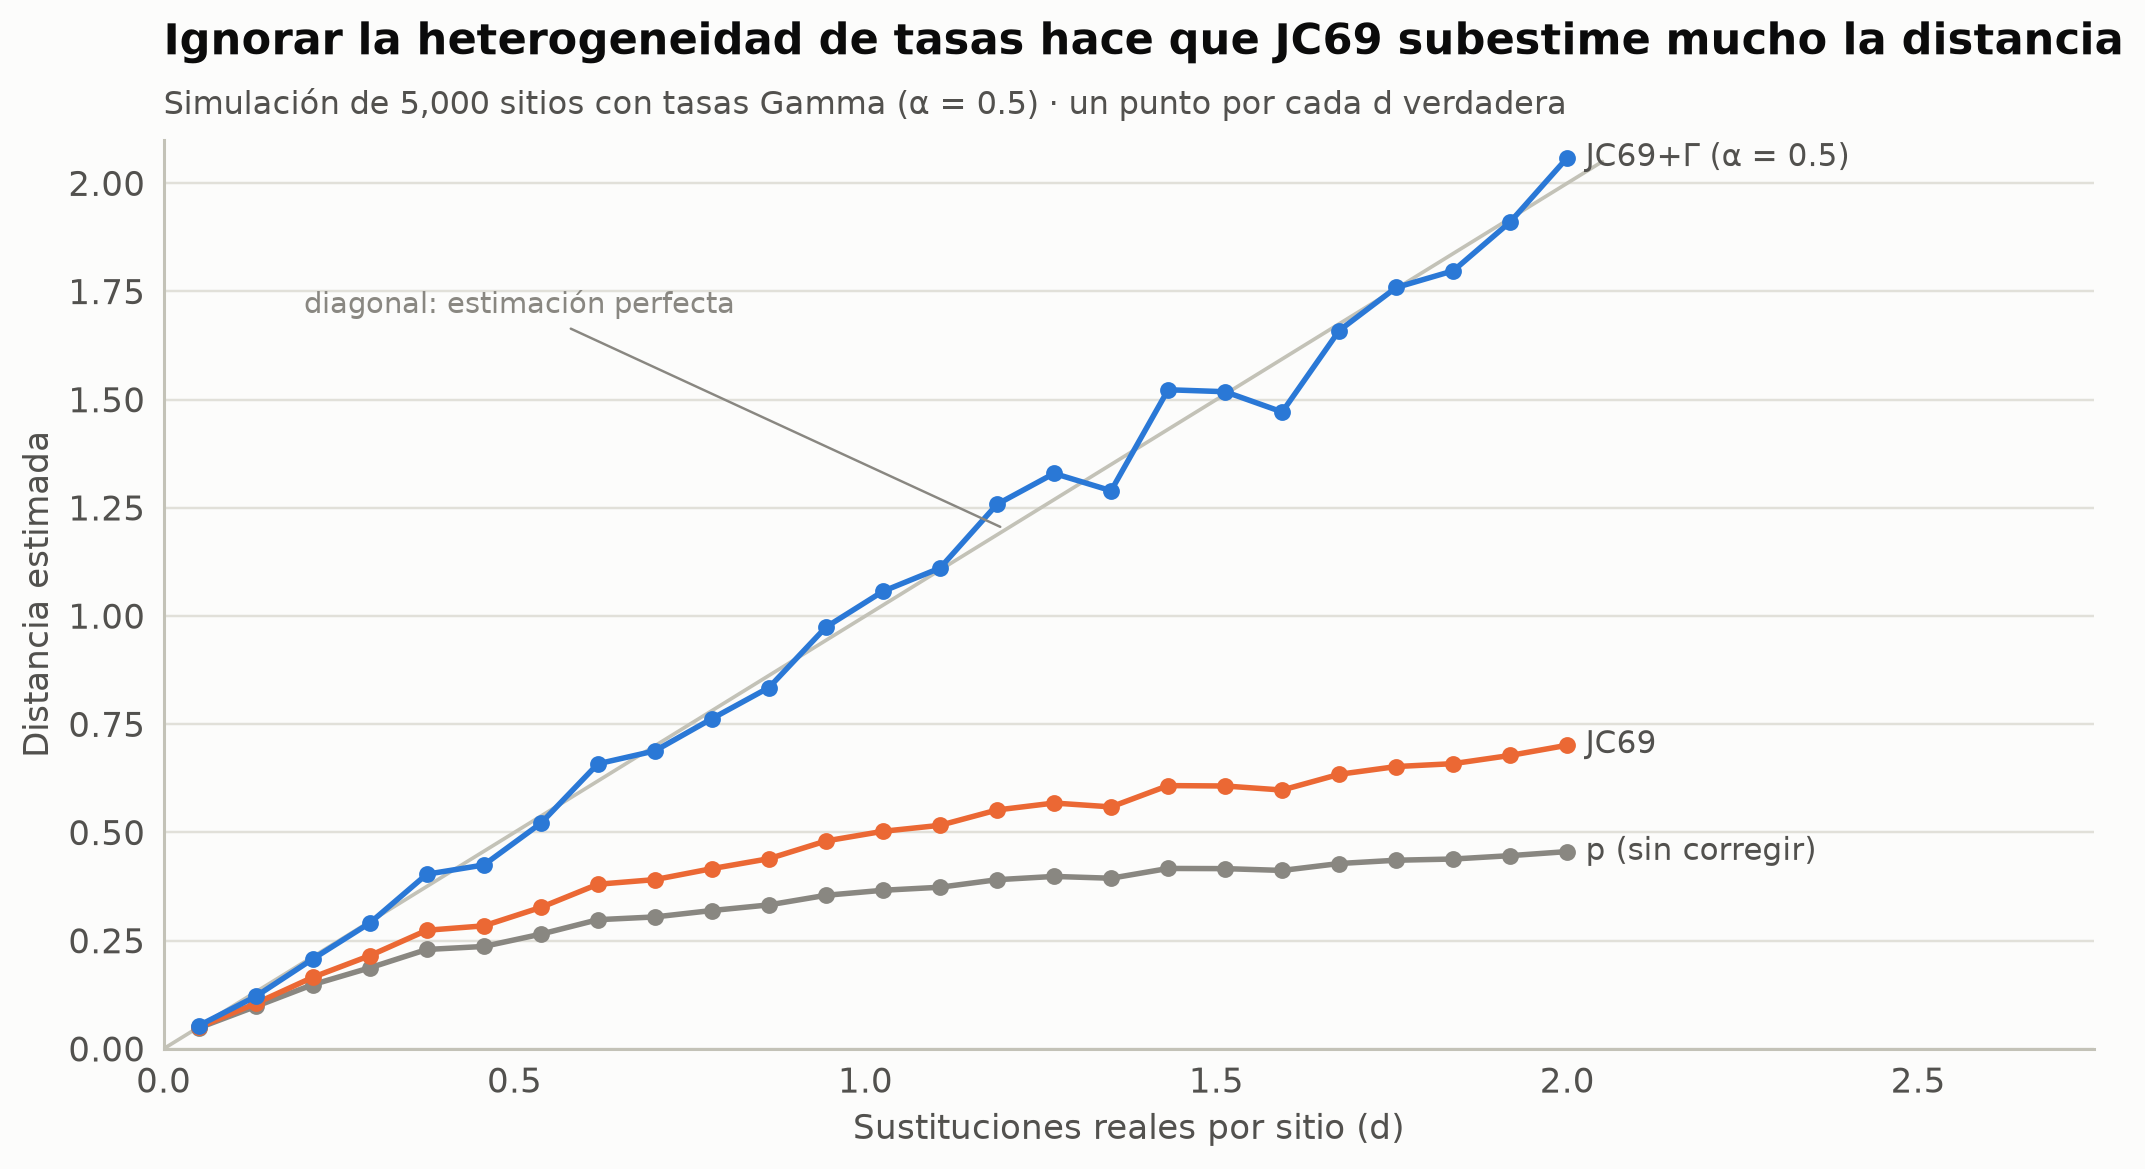

In [19]:
L_G, ALPHA_TRUE = 5000, 0.5
site_rates = rng.gamma(ALPHA_TRUE, 1 / ALPHA_TRUE, L_G)
d_true_grid = np.linspace(0.05, 2.0, 25)
est = {"p (sin corregir)": [], "JC69": [], "JC69+Γ (α = 0.5)": []}
for d in d_true_grid:
    p_site = 0.75 * (1 - np.exp(-4 * d * site_rates / 3))   # probabilidad de que difiera cada sitio
    p_hat = (rng.random(L_G) < p_site).mean()
    est["p (sin corregir)"].append(p_hat)
    est["JC69"].append(jc_distance(p_hat))
    est["JC69+Γ (α = 0.5)"].append(jc_gamma_distance(p_hat, ALPHA_TRUE))

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot([0, 2.05], [0, 2.05], color=ec.BASELINE, lw=1.2)
ax.annotate("diagonal: estimación perfecta", (1.2, 1.2), xytext=(0.2, 1.7), fontsize=9.5, color=ec.MUTED,
            arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=0.8))
for (name, vals), col in zip(est.items(), [ec.MUTED, ec.ORANGE, ec.BLUE]):
    ax.plot(d_true_grid, vals, "o-", color=col, lw=1.8, ms=4.5)
    ec.label_end(ax, d_true_grid[-1], vals[-1], name)
ax.set_xlim(0, 2.75); ax.set_ylim(0, 2.1)
ax.set_xlabel("Sustituciones reales por sitio (d)"); ax.set_ylabel("Distancia estimada")
ec.title(ax, "Ignorar la heterogeneidad de tasas hace que JC69 subestime mucho la distancia",
         f"Simulación de {L_G:,} sitios con tasas Gamma (α = {ALPHA_TRUE}) · un punto por cada d verdadera")
plt.show()

> 🔎 **Qué observamos.** JC69 corrige algo, pero se queda muy por debajo de la diagonal: con $d = 2$ estima menos de la
> mitad. La razón: los sitios rápidos ya están saturados (no aportan información nueva) y los lentos casi no cambian,
> así que la $p$ observada crece muy despacio. JC69+Γ, que "sabe" cómo se reparten las tasas, recupera la distancia
> verdadera. En la práctica $\alpha$ no se conoce: se estima por máxima verosimilitud a partir de un alineamiento
> múltiple y un árbol.

✅ **Compruebe su comprensión.** ¿Por qué, cuando $\alpha \to \infty$, la distancia JC69+Γ se convierte en la JC69?
(Pista: $\lim_{\alpha \to \infty} \alpha\,(x^{-1/\alpha} - 1) = -\ln x$.)

## 8. Varianza de la distancia y saturación

Toda distancia es una **estimación** a partir de un número finito de sitios. Si lanzamos una moneda 20 veces y salen
6 caras, no concluimos que la probabilidad de cara sea exactamente 0.30. Del mismo modo, $p$ tiene una varianza
binomial, $\operatorname{Var}(\hat p) = p(1-p)/L$, y la corrección JC la **amplifica**, porque la curva
$d(p)$ se empina cada vez más cerca de 0.75. Con el método delta (varianza ≈ derivada² × varianza de $p$):

$$
\operatorname{Var}(\hat d_{JC}) \;\approx\; \left(\frac{\partial d}{\partial p}\right)^{2} \operatorname{Var}(\hat p)
\;=\; \frac{p\,(1 - p)}{L\,\left(1 - \tfrac43 p\right)^2}
\qquad\qquad
\text{IC 95 \%} \approx \hat d \pm 1.96\sqrt{\operatorname{Var}(\hat d)}
$$

| Símbolo | Significado |
|---|---|
| $L$ | número de sitios comparados |
| $\partial d/\partial p = 1/(1 - \tfrac43 p)$ | cuánto cambia $d$ si $p$ cambia un poco: explota cerca de $p = 0.75$ |
| IC 95 % | intervalo de confianza aproximado |

**Ejemplo a mano.** $p = 0.2$, $L = 500$: $\operatorname{Var} = 0.16 / (500 \times 0.7333^2) = 0.16/268.9 = 0.000595$,
error estándar $= 0.0244$. Así, $d = 0.233 \pm 0.048$ (IC 95 %: 0.185–0.281). Con $p = 0.6$ y el mismo $L$:
$\operatorname{Var} = 0.24/(500 \times 0.2^2) = 0.012$, error estándar $0.110$, y $d = 1.207 \pm 0.215$: un error
4.5 veces mayor, aunque $p$ sólo se triplicó.

p = 0.2, L = 500: d = 0.233 ± 0.048 (IC 95 %)
p = 0.6, L = 500: d = 1.207 ± 0.215 (IC 95 %)


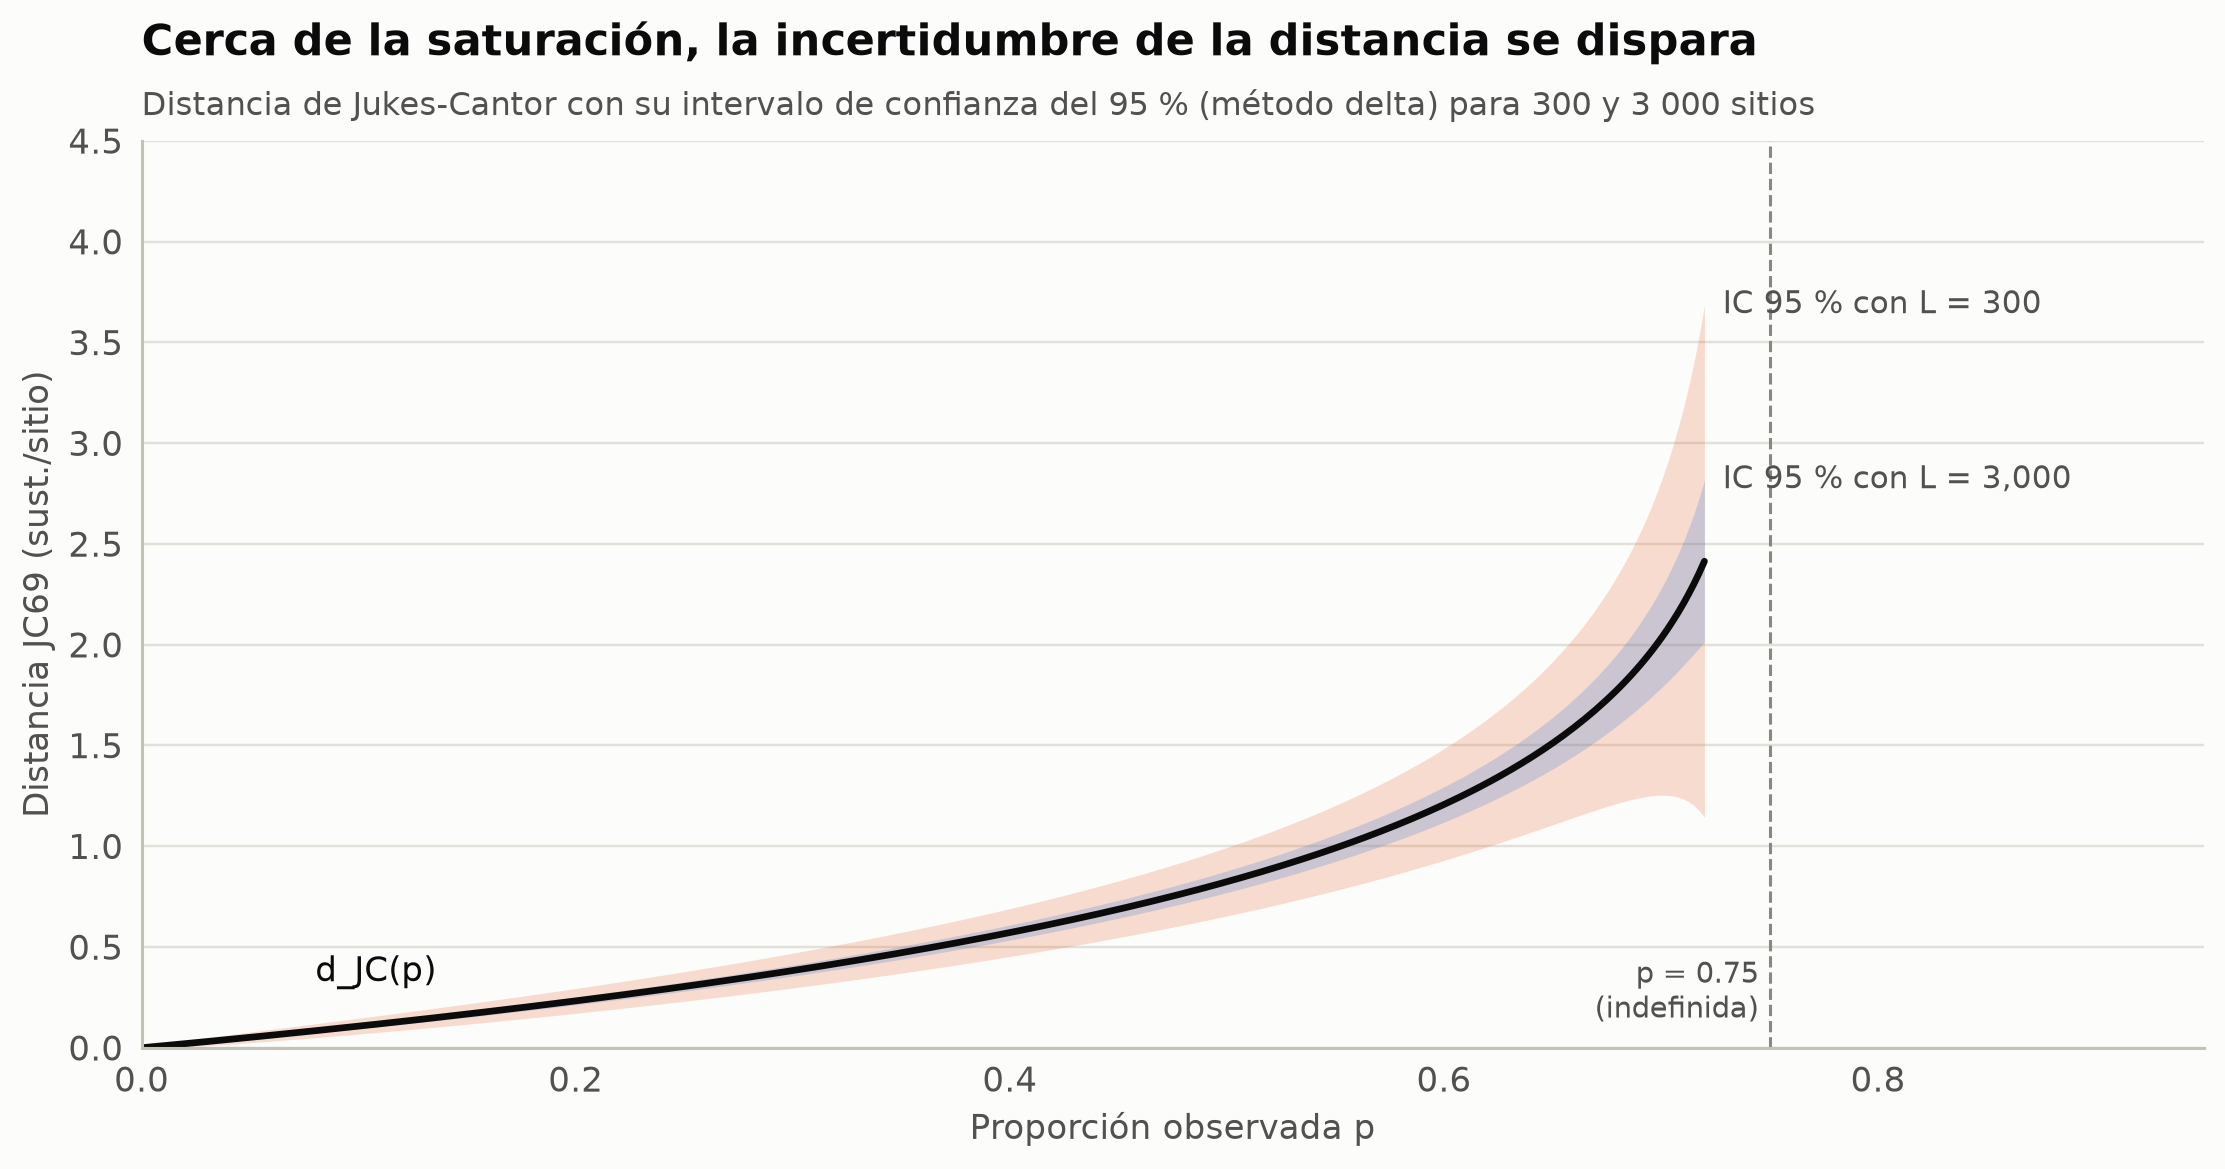

In [20]:
def jc_se(p, L):
    return np.sqrt(p * (1 - p) / (L * (1 - 4 * p / 3) ** 2))

for p_, L_ in [(0.2, 500), (0.6, 500)]:
    print(f"p = {p_}, L = {L_}: d = {jc_distance(p_):.3f} ± {1.96 * jc_se(p_, L_):.3f} (IC 95 %)")

p_grid = np.linspace(0.001, 0.72, 300)
fig, ax = plt.subplots(figsize=(10, 5.2))
for L_, col in [(300, ec.ORANGE), (3000, ec.BLUE)]:
    se = jc_se(p_grid, L_)
    ax.fill_between(p_grid, jc_distance(p_grid) - 1.96 * se, jc_distance(p_grid) + 1.96 * se,
                    color=col, alpha=0.22, lw=0)
    ec.label_end(ax, p_grid[-1], jc_distance(p_grid[-1]) + 1.96 * se[-1], f"IC 95 % con L = {L_:,}")
ax.plot(p_grid, jc_distance(p_grid), color=ec.INK, lw=2.2)
ax.text(0.08, 0.33, "d_JC(p)", color=ec.INK, fontsize=11)
ax.axvline(0.75, color=ec.MUTED, lw=1, ls="--")
ax.text(0.745, 0.15, "p = 0.75\n(indefinida)", ha="right", fontsize=9.5, color=ec.INK_2)
ax.set_xlim(0, 0.95); ax.set_ylim(0, 4.5)
ax.set_xlabel("Proporción observada p"); ax.set_ylabel("Distancia JC69 (sust./sitio)")
ec.title(ax, "Cerca de la saturación, la incertidumbre de la distancia se dispara",
         "Distancia de Jukes-Cantor con su intervalo de confianza del 95 % (método delta) para 300 y 3 000 sitios")
plt.show()

El método delta es una aproximación. Comprobémoslo por simulación: bajo JC69 el número de sitios distintos es
exactamente **binomial**, $n_d \sim \text{Binomial}(L, p(d))$, así que podemos generar miles de réplicas sin simular
secuencias. Para cada distancia verdadera, 2 000 réplicas; contamos también qué fracción de réplicas cae en
$\hat p \geq 0.75$, donde la distancia no existe.

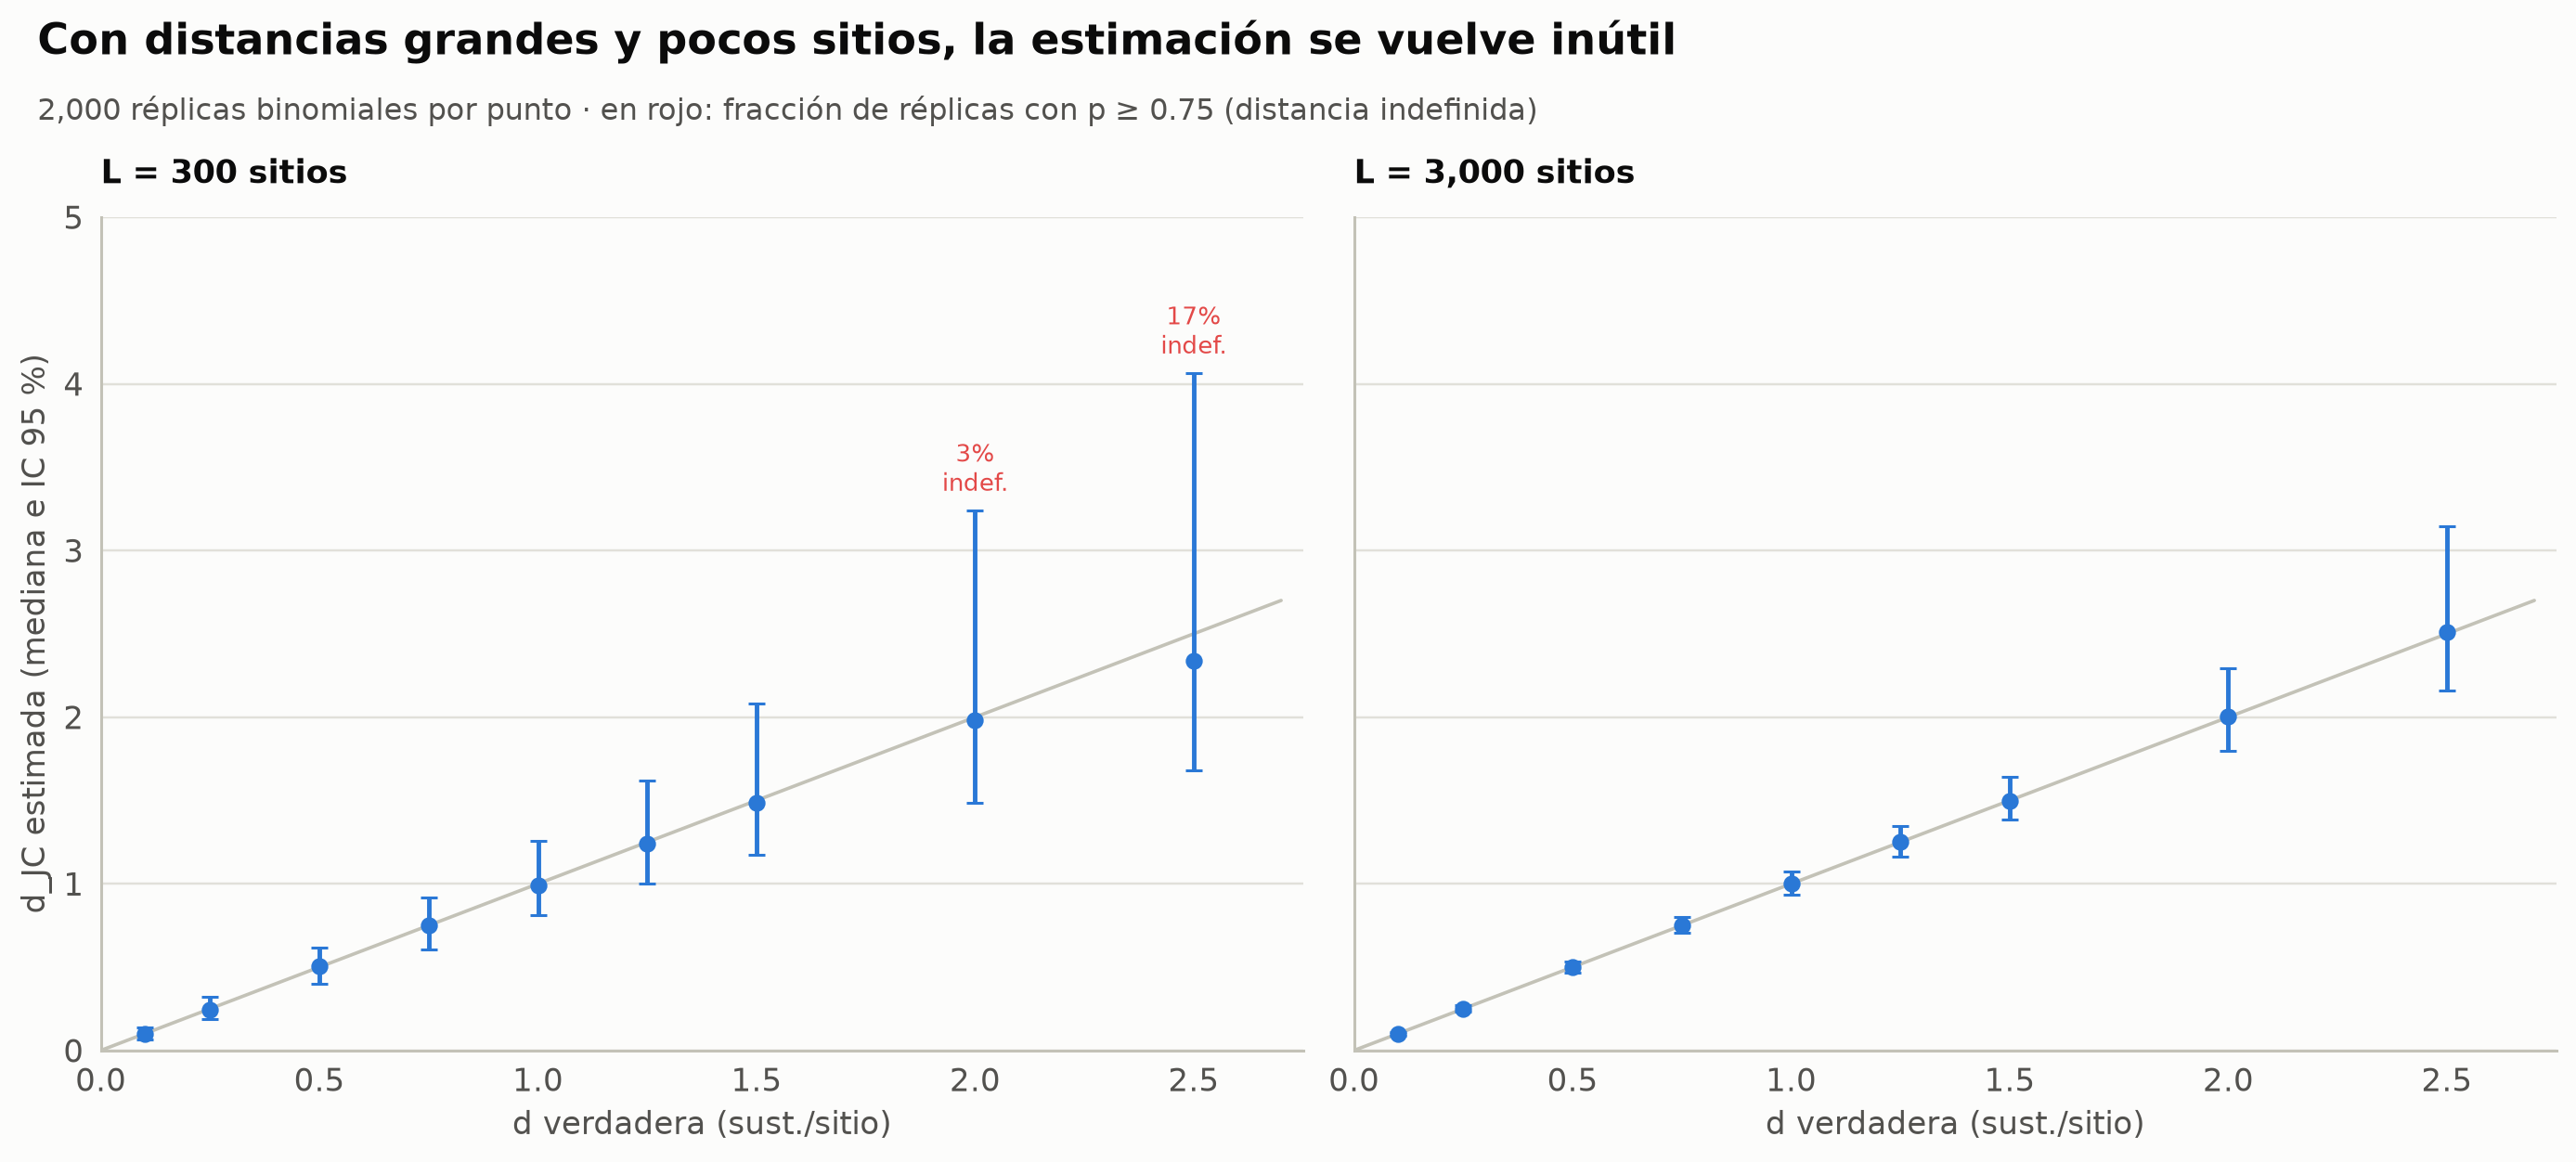

IC_2_5        IC_97_5        indefinidas     
L        300    3000    300    3000        300  3000
d_real                                              
0.10    0.066  0.088   0.139  0.112       0.000  0.0
0.25    0.188  0.230   0.319  0.270       0.000  0.0
0.50    0.400  0.468   0.616  0.535       0.000  0.0
0.75    0.608  0.703   0.920  0.803       0.000  0.0
1.00    0.814  0.935   1.259  1.073       0.000  0.0
1.25    1.004  1.163   1.619  1.344       0.000  0.0
1.50    1.174  1.387   2.083  1.639       0.000  0.0
2.00    1.487  1.797   3.238  2.291       0.027  0.0
2.50    1.679  2.162   4.062  3.144       0.172  0.0

In [21]:
d_true_rep = np.array([0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5])
N_REP = 2000
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9), sharey=True)
summary = []
for ax, L_ in zip(axes, [300, 3000]):
    ax.plot([0, 2.7], [0, 2.7], color=ec.BASELINE, lw=1.2)
    for d in d_true_rep:
        p_true = 0.75 * (1 - np.exp(-4 * d / 3))
        d_hat = jc_distance(rng.binomial(L_, p_true, N_REP) / L_)
        fin = d_hat[np.isfinite(d_hat)]
        lo, med, hi = np.percentile(fin, [2.5, 50, 97.5])
        undefined = 1 - len(fin) / N_REP
        summary.append(dict(L=L_, d_real=d, mediana=med, IC_2_5=lo, IC_97_5=hi, indefinidas=undefined))
        ax.errorbar(d, med, yerr=[[med - lo], [min(hi, 4.4) - med]], fmt="o", color=ec.BLUE, ms=5, capsize=3, lw=1.6)
        if undefined > 0.005:
            ax.text(d, min(hi, 4.4) + 0.12, f"{undefined:.0%}\nindef.", ha="center", fontsize=8.5, color=ec.RED)
    ax.set_xlim(0, 2.75); ax.set_ylim(0, 5)
    ax.set_xlabel("d verdadera (sust./sitio)")
    ax.set_title(f"L = {L_:,} sitios", loc="left", fontsize=11.5)
axes[0].set_ylabel("d_JC estimada (mediana e IC 95 %)")
ec.fig_title(fig, "Con distancias grandes y pocos sitios, la estimación se vuelve inútil",
             f"{N_REP:,} réplicas binomiales por punto · en rojo: fracción de réplicas con p ≥ 0.75 (distancia indefinida)")
plt.show()
pd.DataFrame(summary).round(3).pivot(index="d_real", columns="L", values=["IC_2_5", "IC_97_5", "indefinidas"])

> 🔎 **Qué observamos.** Con $d \leq 0.5$ las barras son estrechas incluso con 300 sitios. A partir de $d \approx 1.5$
> las barras se abren muchísimo, y con $d = 2.5$ y 300 sitios una parte de las réplicas ni siquiera tiene distancia
> definida. Multiplicar por 10 el número de sitios achica las barras (el error estándar baja como $1/\sqrt{L}$),
> pero **no elimina** el problema: cuando las secuencias están saturadas, la información sobre $d$ simplemente ya no
> está en los datos.

**Reglas prácticas:**

* Si $p$ supera ~0.5 (nucleótidos) la distancia es muy incierta; con $p \geq 0.75$ no existe.
* Para linajes muy divergentes conviene usar sitios más lentos (primera y segunda posición de codón, o la secuencia de
  **proteínas**) en lugar de los rápidos (tercera posición).
* Un modelo más complejo no rescata datos saturados: sólo cambia cómo se extrapola.

## 9. 🧪 Datos reales: la polimerasa de 12 coronavirus

Apliquemos todo a un gen real. La **nsp12** es la ARN polimerasa dependiente de ARN (RdRp) de los coronavirus: la
enzima que copia su genoma. Es una de las proteínas más conservadas de la familia, lo que la hace ideal para comparar
virus desde muy cercanos hasta muy lejanos. Elegimos 12 genomas del NCBI:

* **Sarbecovirus** (el subgénero de SARS-CoV-2 dentro de los *Betacoronavirus*): SARS-CoV-2 (Wuhan-Hu-1), los virus de
  murciélago RaTG13 (Yunnan, China), BANAL-20-52 (Laos) y ZC45, el coronavirus de pangolín GX-P5L, el virus de
  murciélago WIV1 y SARS-CoV-1 (cepa Tor2, de la epidemia de 2003).
* Otros *Betacoronavirus*: MERS-CoV (*Merbecovirus*), y los coronavirus humanos "de resfriado" OC43 y HKU1
  (*Embecovirus*).
* Dos *Alphacoronavirus* humanos: 229E y NL63.

**Cómo se obtuvo cada nsp12.** El gen está dentro del enorme ORF1ab, que el ribosoma lee con un **desplazamiento del
marco de lectura −1** justo al comienzo de la nsp12. Por eso sus coordenadas tienen dos tramos que se solapan en una
base (por ejemplo `13442-13468,13468-16236` en SARS-CoV-2). Cuando el registro del NCBI anota la nsp12 como
`mat_peptide` usamos esa anotación; cuando no (los genomas de murciélago y pangolín, NL63, y SARS-CoV-1, cuya anotación
RefSeq de la nsp12 cubre sólo 24 nucleótidos), la localizamos alineando la proteína ORF1ab contra la nsp12 de
SARS-CoV-2 y ajustando los extremos a los sitios de corte de la proteasa (…Q | S…). En todos los casos comprobamos que
la traducción coincide con la proteína anotada por el NCBI. El archivo resultante está en `data/coronavirus_nsp12.fasta`;
si no está disponible, la celda siguiente lo reconstruye descargando esos mismos tramos del NCBI.

In [22]:
# (nombre, accesión, tramos 1-based del genoma, clasificación, hospedero)
CORONAVIRUSES = [
    ("SARS-CoV-2",      "NC_045512.2", [(13442, 13468), (13468, 16236)], "Beta · Sarbecovirus", "humano"),
    ("RaTG13",          "MN996532.2",  [(13439, 13465), (13465, 16233)], "Beta · Sarbecovirus", "murciélago (Rhinolophus)"),
    ("BANAL-20-52",     "MZ937000.1",  [(13391, 13417), (13417, 16185)], "Beta · Sarbecovirus", "murciélago (Rhinolophus)"),
    ("Pangolin-GX-P5L", "MT040335.1",  [(13419, 13445), (13445, 16213)], "Beta · Sarbecovirus", "pangolín malayo"),
    ("ZC45",            "MG772933.1",  [(13429, 13455), (13455, 16223)], "Beta · Sarbecovirus", "murciélago (Rhinolophus)"),
    ("WIV1",            "KF367457.1",  [(13372, 13398), (13398, 16166)], "Beta · Sarbecovirus", "murciélago (Rhinolophus)"),
    ("SARS-CoV-1",      "NC_004718.3", [(13372, 13392), (13392, 16166)], "Beta · Sarbecovirus", "humano"),
    ("MERS-CoV",        "NC_019843.3", [(13410, 13433), (13433, 16207)], "Beta · Merbecovirus", "humano"),
    ("HCoV-OC43",       "NC_006213.1", [(13317, 13340), (13340, 16099)], "Beta · Embecovirus", "humano"),
    ("HCoV-HKU1",       "NC_006577.2", [(13577, 13600), (13600, 16359)], "Beta · Embecovirus", "humano"),
    ("HCoV-229E",       "NC_002645.1", [(12497, 12520), (12520, 15276)], "Alpha · Duvinacovirus", "humano"),
    ("HCoV-NL63",       "NC_005831.2", [(12416, 12439), (12439, 15195)], "Alpha · Setracovirus", "humano"),
]

def nsp12_from_ncbi():
    """Reconstruye el FASTA descargando del NCBI cada tramo (efetch con seq_start/seq_stop) y uniéndolos."""
    out = []
    for name, acc, ivs, *_ in CORONAVIRUSES:
        parts = []
        for a, b in ivs:
            url = ("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&rettype=fasta"
                   f"&retmode=text&id={acc}&seq_start={a}&seq_stop={b}")
            with urllib.request.urlopen(url, timeout=60) as r:
                parts.append("".join(r.read().decode().splitlines()[1:]))
            time.sleep(0.4)                                  # respeta el límite del NCBI (3 consultas/s)
        out.append(f">{name} {acc}\n{''.join(parts)}\n")
    return "".join(out).encode()

fasta = course_bytes("coronavirus_nsp12.fasta", nsp12_from_ncbi).decode()
records = list(SeqIO.parse(io.StringIO(fasta), "fasta"))
names = [r.id for r in records]
nts = [str(r.seq).upper() for r in records]
prots = [str(Seq(s).translate()) for s in nts]
assert names == [c[0] for c in CORONAVIRUSES]
info = pd.DataFrame([dict(virus=c[0], accesion=c[1], tramos=",".join(f"{a}-{b}" for a, b in c[2]),
                          clasificacion=c[3], hospedero=c[4], nt=len(s), aa=len(p), GC=f"{(s.count('G') + s.count('C')) / len(s):.1%}")
                     for c, s, p in zip(CORONAVIRUSES, nts, prots)])
print("¿Algún codón de parada interno?", any("*" in p for p in prots))
info

¿Algún codón de parada interno? False


,virus,accesion,tramos,clasificacion,hospedero,nt,aa,GC
0,SARS-CoV-2,NC_045512.2,"13442-13468,13468-16236",Beta · Sarbecovirus,humano,2796,932,37.3%
1,RaTG13,MN996532.2,"13439-13465,13465-16233",Beta · Sarbecovirus,murciélago (Rhinolophus),2796,932,37.7%
2,BANAL-20-52,MZ937000.1,"13391-13417,13417-16185",Beta · Sarbecovirus,murciélago (Rhinolophus),2796,932,37.5%
3,Pangolin-GX-P5L,MT040335.1,"13419-13445,13445-16213",Beta · Sarbecovirus,pangolín malayo,2796,932,37.4%
4,ZC45,MG772933.1,"13429-13455,13455-16223",Beta · Sarbecovirus,murciélago (Rhinolophus),2796,932,40.1%
5,WIV1,KF367457.1,"13372-13398,13398-16166",Beta · Sarbecovirus,murciélago (Rhinolophus),2796,932,39.8%
6,SARS-CoV-1,NC_004718.3,"13372-13392,13392-16166",Beta · Sarbecovirus,humano,2796,932,39.3%
7,MERS-CoV,NC_019843.3,"13410-13433,13433-16207",Beta · Merbecovirus,humano,2799,933,39.8%
8,HCoV-OC43,NC_006213.1,"13317-13340,13340-16099",Beta · Embecovirus,humano,2784,928,35.8%
9,HCoV-HKU1,NC_006577.2,"13577-13600,13600-16359",Beta · Embecovirus,humano,2784,928,32.0%


### Alineamiento guiado por la proteína

Para comparar sitios hay que alinear. Con virus lejanos (SARS-CoV-2 frente a NL63), un alineamiento directo de
nucleótidos pondría huecos que rompen el marco de lectura y alinearía codones que no son homólogos. La estrategia
habitual para genes codificantes es:

1. traducir cada gen y **alinear las proteínas** (BLOSUM62, como en la Lección 3.3), que conservan la señal mucho más
   tiempo;
2. **"retrotraducir"** el alineamiento: cada aminoácido alineado arrastra su codón.

Así cada par de secuencias tiene un alineamiento de codones sin huecos que rompan el marco. De cada par contamos los
sitios comparados $L$, las diferencias por transición y por transversión y, aparte, las diferencias en las posiciones
1+2 y 3 del codón.

In [23]:
prot_aligner = PairwiseAligner(mode="global", substitution_matrix=substitution_matrices.load("BLOSUM62"),
                               open_gap_score=-11, extend_gap_score=-1)

def codon_alignment(i, j):
    """Alinea las proteínas i y j y devuelve las dos secuencias de nucleótidos con sólo los codones alineados
    (sin huecos): cada aminoácido alineado aporta su codón."""
    aln = prot_aligner.align(prots[i], prots[j])[0]
    x, y = [], []
    for (s1, e1), (s2, e2) in zip(*aln.aligned):            # bloques alineados sin huecos
        x.append(nts[i][3 * s1:3 * e1]); y.append(nts[j][3 * s2:3 * e2])
    return "".join(x), "".join(y)

def pair_stats(x, y):
    """Estadísticas de un par alineado: sitios, transiciones, transversiones, p, P, Q, d_JC, d_K80, κ̂,
    y p en posiciones de codón 1+2 y 3."""
    X, Y = np.array(list(x)), np.array(list(y))
    L = len(X); diff = X != Y
    same_class = np.isin(X, ["A", "G"]) == np.isin(Y, ["A", "G"])
    n_ts, n_tv = int((diff & same_class).sum()), int((diff & ~same_class).sum())
    P, Qv, p = n_ts / L, n_tv / L, diff.mean()
    d_k80, kappa = k80_distance(P, Qv)
    pos3 = np.arange(L) % 3 == 2
    return dict(L=L, n_ts=n_ts, n_tv=n_tv, p=p, P=P, Q=Qv, d_JC=float(jc_distance(p)), d_K80=d_k80,
                se_JC=float(jc_se(p, L)), kappa=kappa, p12=diff[~pos3].mean(), p3=diff[pos3].mean())

rows = []
for i, j in itertools.combinations(range(len(names)), 2):
    rows.append(dict(a=names[i], b=names[j], **pair_stats(*codon_alignment(i, j))))
pairs = pd.DataFrame(rows)
print(f"{len(pairs)} pares alineados")
pairs[pairs.a == "SARS-CoV-2"].drop(columns="a").set_index("b").round(3)

66 pares alineados


,L,n_ts,n_tv,p,P,Q,d_JC,d_K80,se_JC,kappa,p12,p3
b,,,,,,,,,,,,
RaTG13,2796,54,7,0.022,0.019,0.003,0.022,0.022,0.003,15.734,0.005,0.055
BANAL-20-52,2796,38,6,0.016,0.014,0.002,0.016,0.016,0.002,12.841,0.002,0.043
Pangolin-GX-P5L,2796,195,126,0.115,0.070,0.045,0.125,0.126,0.007,3.320,0.024,0.297
ZC45,2796,248,127,0.134,0.089,0.045,0.148,0.150,0.008,4.294,0.035,0.333
WIV1,2796,215,118,0.119,0.077,0.042,0.130,0.131,0.007,3.948,0.034,0.289
SARS-CoV-1,2796,202,120,0.115,0.072,0.043,0.125,0.126,0.007,3.625,0.033,0.279
MERS-CoV,2790,425,497,0.330,0.152,0.178,0.436,0.440,0.016,1.994,0.215,0.562
HCoV-OC43,2781,441,564,0.361,0.159,0.203,0.493,0.497,0.018,1.821,0.263,0.559
HCoV-HKU1,2781,399,549,0.341,0.143,0.197,0.455,0.457,0.016,1.638,0.255,0.512


> 🔎 **Qué observamos.** En la nsp12, SARS-CoV-2 difiere en ~1.6 % de los sitios de BANAL-20-52 y en ~2.2 % de
> RaTG13: sus parientes conocidos más cercanos (en este gen, BANAL-20-52 es incluso un poco más cercano que RaTG13).
> A esas distancias p, JC69 y K80 dan casi lo mismo: hay muy pocas sustituciones múltiples. Con los otros sarbecovirus
> ($p \approx 0.12$) la corrección ya suma ~1 punto; con MERS-CoV y los coronavirus de resfriado ($p \approx 0.33$–0.39)
> la corrección sube la distancia en un 30–45 %. Fíjese además en $\hat\kappa$ y en las columnas `p12` y `p3`.

Ahora las matrices completas. Ordenamos los virus por grupo para que los bloques sean visibles.

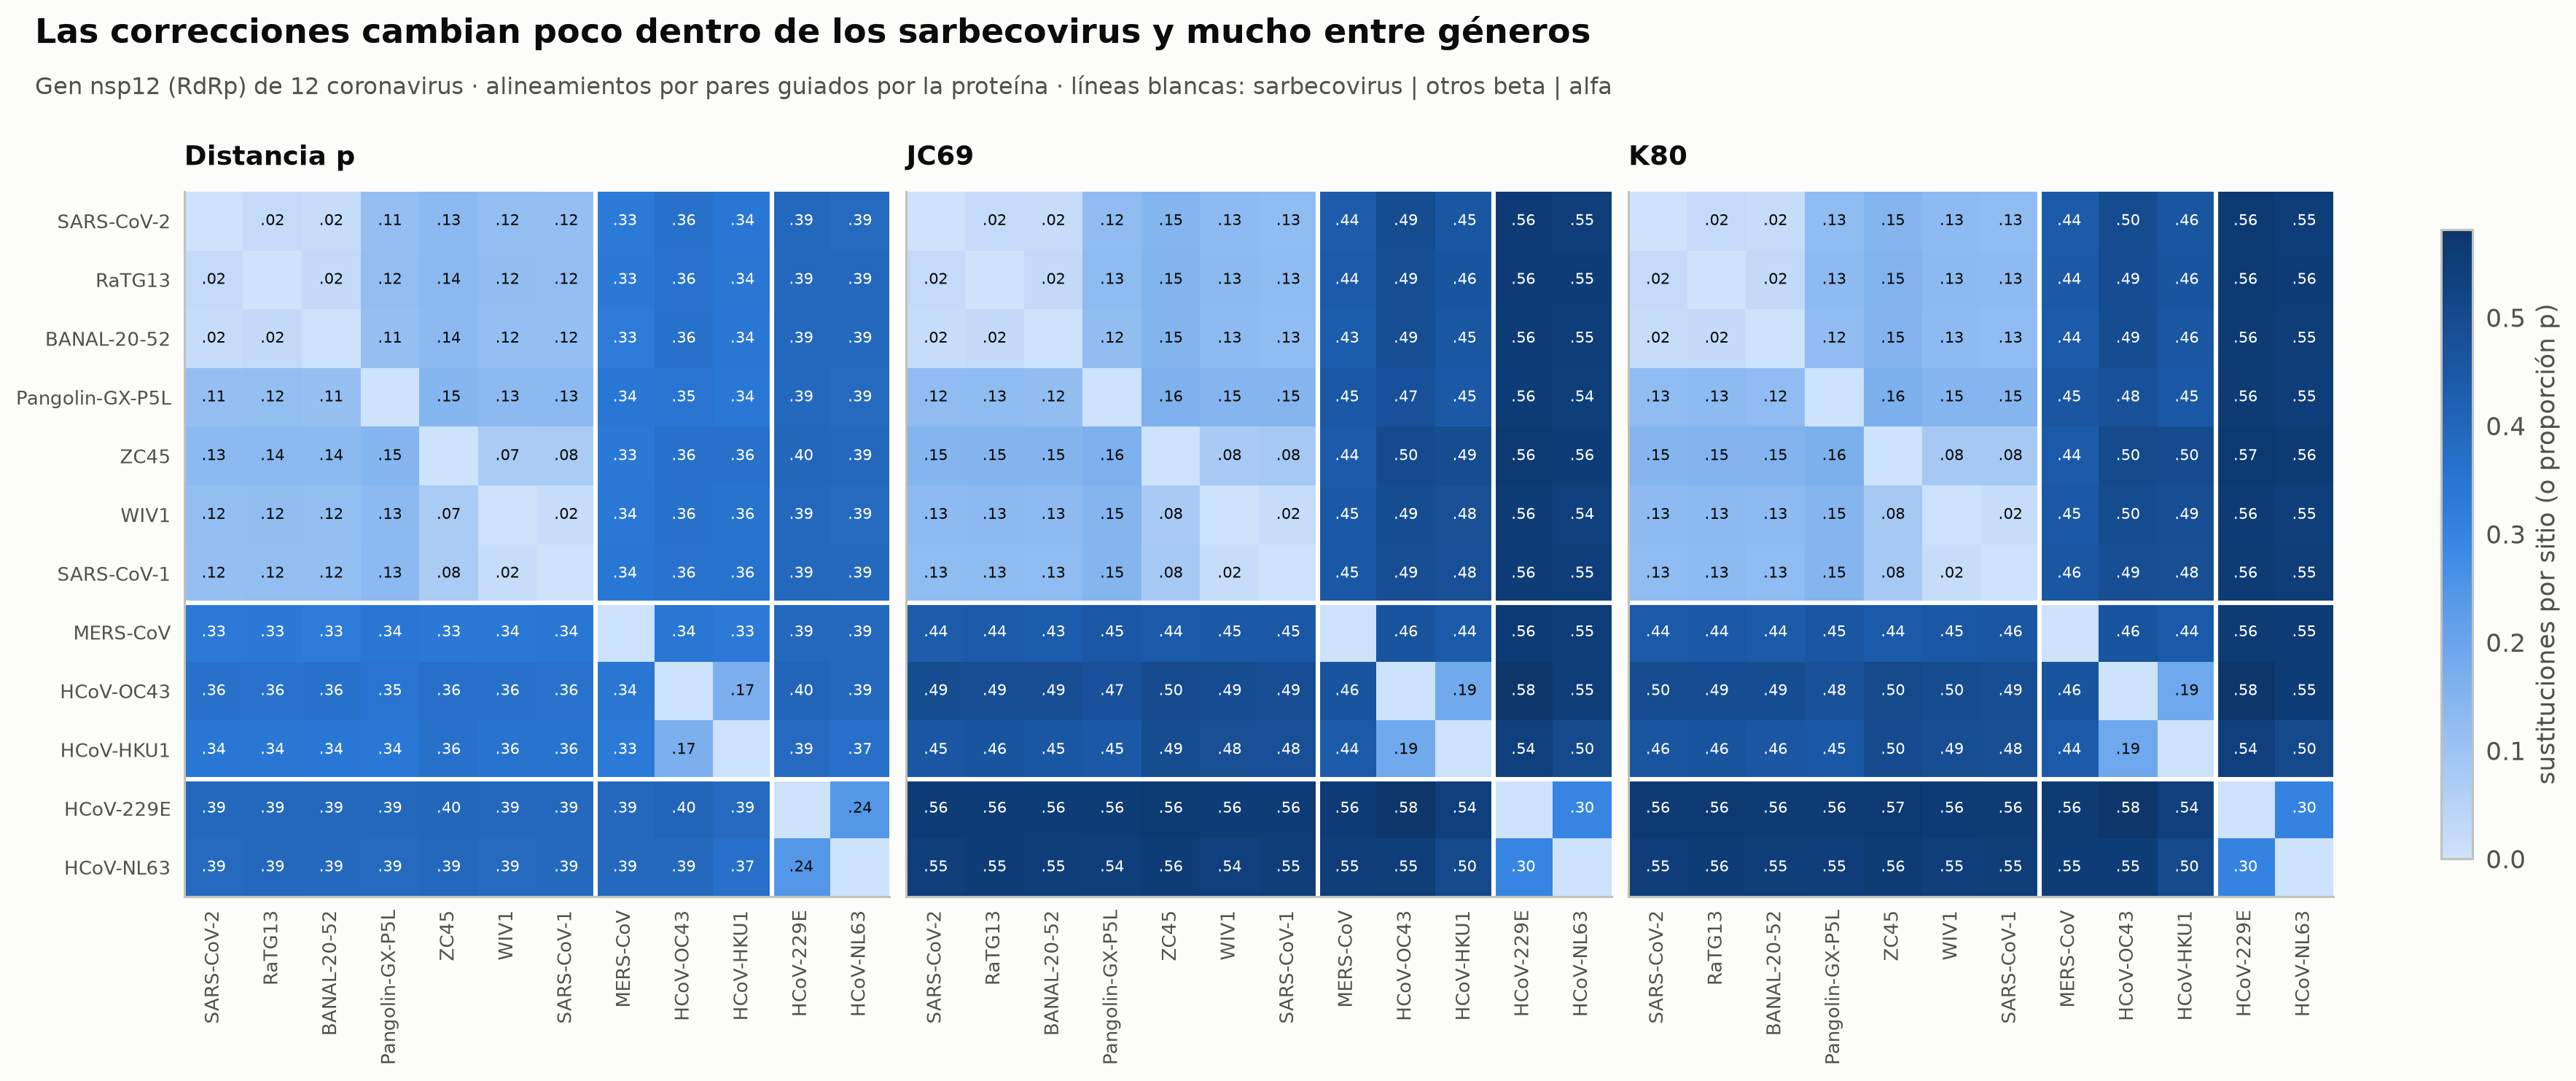

In [24]:
def pair_matrix(col):
    M = pd.DataFrame(0.0, index=names, columns=names)
    for r in pairs.itertuples():
        M.loc[r.a, r.b] = M.loc[r.b, r.a] = getattr(r, col)
    return M

mats = {"Distancia p": pair_matrix("p"), "JC69": pair_matrix("d_JC"), "K80": pair_matrix("d_K80")}
vmax = mats["K80"].values.max()
fig, axes = plt.subplots(1, 3, figsize=(16, 5.9))
for ax, (title, M) in zip(axes, mats.items()):
    im = ax.imshow(M.values, cmap=ec.CMAP_SEQ, vmin=0, vmax=vmax)
    for i in range(len(names)):
        for j in range(len(names)):
            if i != j:
                v = M.values[i, j]
                ax.text(j, i, f"{v:.2f}".lstrip("0") if v < 1 else f"{v:.1f}", ha="center", va="center",
                        fontsize=7, color="white" if v > 0.5 * vmax else ec.INK)
    ax.set_xticks(range(len(names)), names, rotation=90, fontsize=8.5)
    ax.set_yticks(range(len(names)), names if ax is axes[0] else [""] * len(names), fontsize=8.5)
    for k in (6.5, 9.5):                                     # bordes entre grupos
        ax.axhline(k, color="white", lw=2); ax.axvline(k, color="white", lw=2)
    ax.grid(False); ax.set_title(title, loc="left", fontsize=12)
fig.colorbar(im, ax=axes, shrink=0.75, label="sustituciones por sitio (o proporción p)")
ec.fig_title(fig, "Las correcciones cambian poco dentro de los sarbecovirus y mucho entre géneros",
             "Gen nsp12 (RdRp) de 12 coronavirus · alineamientos por pares guiados por la proteína · líneas blancas: sarbecovirus | otros beta | alfa")
plt.show()

> 🔎 **Qué observamos.** Las tres matrices muestran los mismos bloques: los siete sarbecovirus muy parecidos entre sí
> (arriba a la izquierda), los tres otros *Betacoronavirus* y los dos *Alphacoronavirus* (abajo a la derecha: 229E y
> NL63 se parecen entre sí, $p \approx 0.25$). La diferencia está en la **escala**: entre géneros, $p$ no pasa de ~0.40
> pero las distancias corregidas llegan a ~0.56. Con un árbol construido a partir de $p$, las ramas profundas quedarían
> demasiado cortas.

### Mapa de calor interactivo

Pase el cursor por cada casilla: verá el par, los sitios comparados, las transiciones y transversiones, $p$, $d_{JC}$
(con su error estándar), $d_{K80}$ y $\hat\kappa$. Con el menú puede cambiar la medida que colorea el mapa.

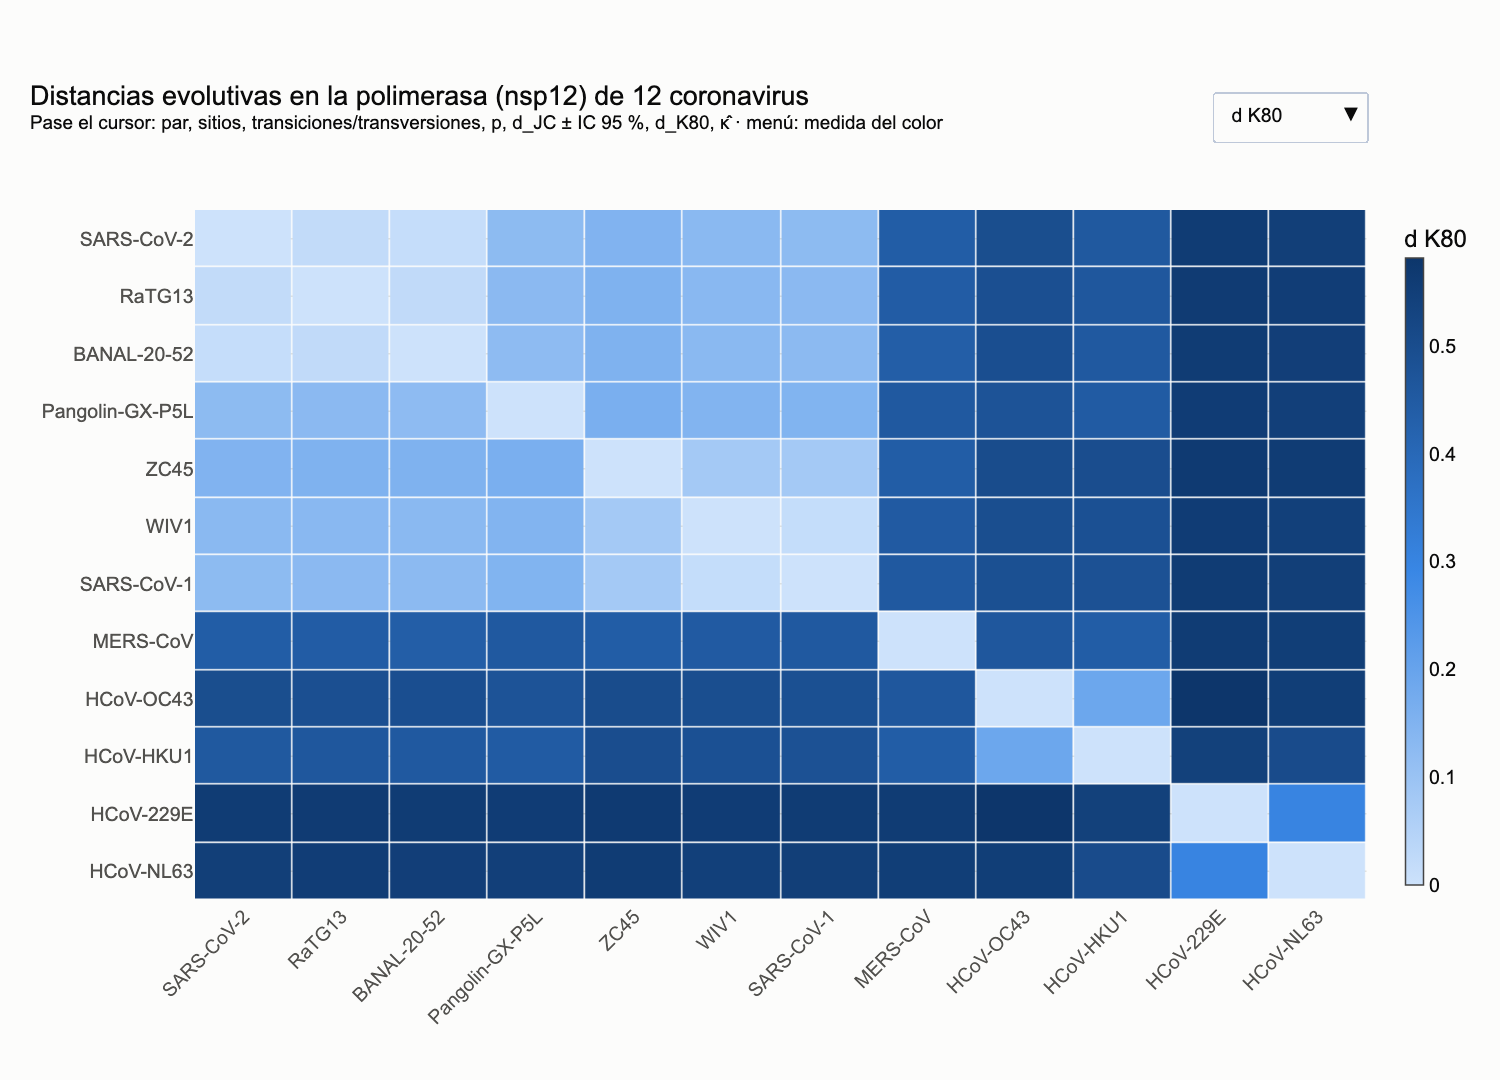

In [25]:
n = len(names)
cd = np.empty((n, n), dtype=object)
Z = {k: np.full((n, n), np.nan) for k in ["p", "d_JC", "d_K80"]}
fmt = lambda v: "indefinida" if not np.isfinite(v) else f"{v:.4f}"
for r in pairs.itertuples():
    i, j = names.index(r.a), names.index(r.b)
    txt = (f"<b>{r.a} × {r.b}</b><br>sitios comparados: {r.L:,}<br>transiciones: {r.n_ts} (P = {r.P:.3f}) · "
           f"transversiones: {r.n_tv} (Q = {r.Q:.3f})<br>p = {r.p:.4f}<br>d_JC = {fmt(r.d_JC)} ± {1.96 * r.se_JC:.4f} (IC 95 %)"
           f"<br>d_K80 = {fmt(r.d_K80)} · κ̂ = {r.kappa:.2f}<br>p posición 1+2 = {r.p12:.3f} · p posición 3 = {r.p3:.3f}")
    cd[i, j] = cd[j, i] = txt
    for k in Z:
        Z[k][i, j] = Z[k][j, i] = getattr(r, k)
for i in range(n):
    cd[i, i] = f"<b>{names[i]}</b><br>{info.clasificacion[i]} · {info.hospedero[i]}<br>{info.accesion[i]}"
    for k in Z:
        Z[k][i, i] = 0
labels = {"p": "distancia p", "d_JC": "d JC69", "d_K80": "d K80"}
scale = [[0, ec.SEQ_BLUE[0]], [0.5, ec.SEQ_BLUE[6]], [1, ec.SEQ_BLUE[12]]]
fig = go.Figure(go.Heatmap(z=Z["d_K80"], x=names, y=names, customdata=cd, colorscale=scale, zmin=0,
                           zmax=np.nanmax(Z["d_K80"]), colorbar=dict(title="d K80", thickness=12),
                           hovertemplate="%{customdata}<extra></extra>", xgap=1, ygap=1))
fig.update_layout(
    title=dict(text="Distancias evolutivas en la polimerasa (nsp12) de 12 coronavirus<br>"
                    "<sup>Pase el cursor: par, sitios, transiciones/transversiones, p, d_JC ± IC 95 %, d_K80, κ̂ · menú: medida del color</sup>"),
    height=720, width=860, margin=dict(t=140, l=130, r=40, b=120),
    yaxis=dict(autorange="reversed"), xaxis=dict(tickangle=-45),
    updatemenus=[dict(type="dropdown", x=1.0, xanchor="right", y=1.1, yanchor="bottom",
                      buttons=[dict(label=labels[k], method="restyle",
                                    args=[{"z": [Z[k]], "zmax": [np.nanmax(Z["d_K80"])], "colorbar.title.text": labels[k]}])
                               for k in ["d_K80", "d_JC", "p"]])])
fig.show()

### La firma de la saturación en datos reales

¿Cómo sabemos, sin conocer la verdad, que las comparaciones lejanas están saturadas? Hay dos huellas que ya
anticipamos con los modelos:

1. **El cociente transiciones/transversiones ($P/Q$) cae** al aumentar la divergencia: las transiciones, más rápidas,
   saturan primero (sección 5).
2. **Las terceras posiciones de codón se estancan**: como muchos cambios en la tercera posición no alteran el
   aminoácido, esos sitios evolucionan mucho más rápido y llegan a su techo mientras que las posiciones 1 y 2 siguen
   acumulando cambios (sección 7).

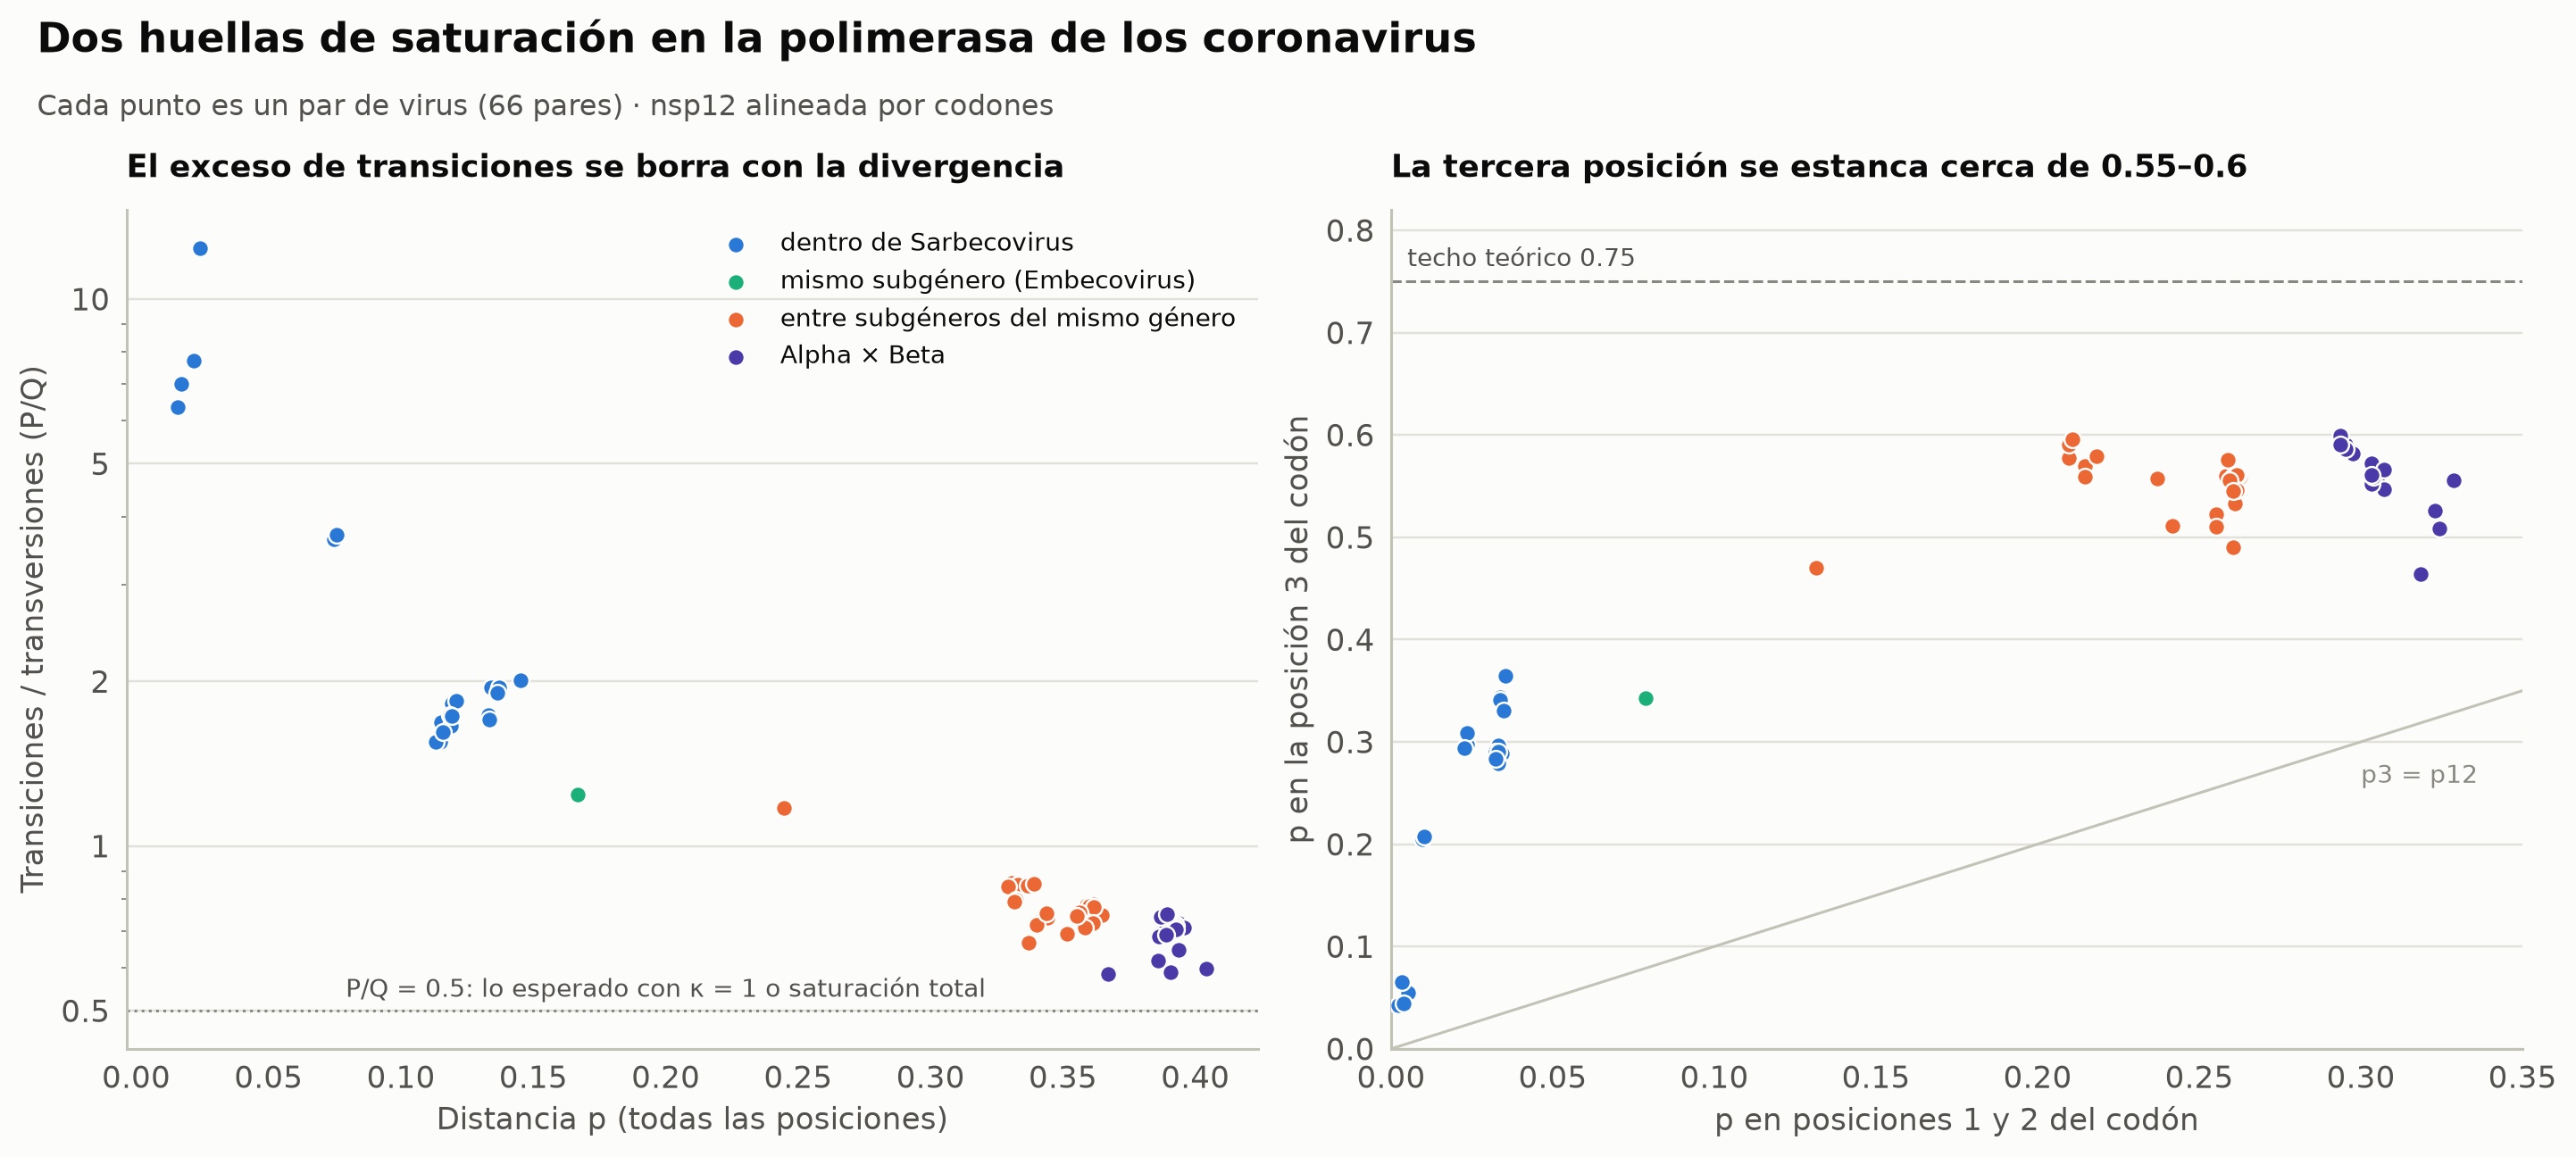

In [26]:
group = {c[0]: c[3] for c in CORONAVIRUSES}
def pair_kind(a, b):
    ga, gb = group[a], group[b]
    if ga == gb == "Beta · Sarbecovirus":
        return "dentro de Sarbecovirus"
    if ga == gb:
        return "mismo subgénero (Embecovirus)"
    if ga.split(" ·")[0] == gb.split(" ·")[0]:
        return "entre subgéneros del mismo género"
    return "Alpha × Beta"
pairs["tipo"] = [pair_kind(a, b) for a, b in zip(pairs.a, pairs.b)]
kind_colors = {"dentro de Sarbecovirus": ec.BLUE, "mismo subgénero (Embecovirus)": ec.AQUA,
               "entre subgéneros del mismo género": ec.ORANGE, "Alpha × Beta": ec.VIOLET}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.1))
ax = axes[0]
for kname, col in kind_colors.items():
    sub = pairs[pairs.tipo == kname]
    ax.scatter(sub.p, sub.P / sub.Q, s=38, color=col, edgecolor=ec.SURFACE, lw=0.8, label=kname, zorder=3)
ax.axhline(0.5, color=ec.MUTED, lw=1, ls=":")
ax.text(0.2, 0.53, "P/Q = 0.5: lo esperado con κ = 1 o saturación total", ha="center", fontsize=9, color=ec.INK_2)
ax.set_yscale("log"); ax.set_yticks([0.5, 1, 2, 5, 10], ["0.5", "1", "2", "5", "10"])
ax.set_xlabel("Distancia p (todas las posiciones)"); ax.set_ylabel("Transiciones / transversiones (P/Q)")
ax.legend(loc="upper right", fontsize=9)
ax.set_title("El exceso de transiciones se borra con la divergencia", loc="left", fontsize=11.5)

ax = axes[1]
for kname, col in kind_colors.items():
    sub = pairs[pairs.tipo == kname]
    ax.scatter(sub.p12, sub.p3, s=38, color=col, edgecolor=ec.SURFACE, lw=0.8, zorder=3)
ax.plot([0, 0.35], [0, 0.35], color=ec.BASELINE, lw=1)
ax.text(0.3, 0.26, "p3 = p12", color=ec.MUTED, fontsize=9, rotation=0)
ax.axhline(0.75, color=ec.MUTED, lw=1, ls="--"); ax.text(0.005, 0.765, "techo teórico 0.75", fontsize=9, color=ec.INK_2)
ax.set_xlim(0, 0.35); ax.set_ylim(0, 0.82)
ax.set_xlabel("p en posiciones 1 y 2 del codón"); ax.set_ylabel("p en la posición 3 del codón")
ax.set_title("La tercera posición se estanca cerca de 0.55–0.6", loc="left", fontsize=11.5)
ec.fig_title(fig, "Dos huellas de saturación en la polimerasa de los coronavirus",
             "Cada punto es un par de virus (66 pares) · nsp12 alineada por codones")
plt.show()

> 🔎 **Qué observamos.** (Izquierda) Entre sarbecovirus muy cercanos (SARS-CoV-2, RaTG13, BANAL-20-52; SARS-CoV-1 y
> WIV1) hay de 6 a 12 transiciones por cada transversión; entre sarbecovirus más alejados, ~1.5–2; entre subgéneros o
> géneros distintos, menos de una: las transiciones que ocurrieron ya se "taparon" con transversiones posteriores, justo
> como predijo la curva de K80 con $\kappa$ alto. (Derecha) Al comparar sarbecovirus, la tercera posición acumula ~10
> veces más diferencias que las posiciones 1+2. Luego se aplana cerca de 0.55–0.60 aunque las posiciones 1+2 sigan
> subiendo de 0.1 a 0.3: la tercera posición está saturada. El techo real queda por debajo de 0.75 porque la
> composición de bases no es uniforme y porque no todos los cambios en la tercera posición son sinónimos.

**Moraleja práctica.** Para relaciones profundas (entre géneros de coronavirus) conviene usar las posiciones 1+2, la
secuencia de **aminoácidos**, o un modelo con Gamma; la tercera posición sirve para las relaciones recientes (dentro de
los sarbecovirus), donde todavía no está saturada.

✅ **Compruebe su comprensión.** Busque en el mapa interactivo el par SARS-CoV-2 × NL63. ¿Cuánto vale $\hat\kappa$?
¿Por qué es tanto menor que con RaTG13? (Respuesta: $\hat\kappa \approx 1.6$, frente a ~16 con RaTG13 y ~13 con
BANAL-20-52. La biología de la polimerasa no cambió: la saturación y la heterogeneidad de tasas entre sitios sesgan la
estimación de $\kappa$ entre secuencias muy lejanas. $\kappa$ se estima mejor con pares cercanos o, mejor aún, con
máxima verosimilitud sobre un árbol.)

## 10. 🧪 Alineamiento múltiple con MAFFT (en Colab)

Los alineamientos por pares tienen una desventaja: cada par se alinea por separado, así que un mismo sitio puede
alinearse de forma distinta en cada comparación. La práctica habitual en filogenética es construir **un** alineamiento
múltiple (Lección 4.1) y calcular todas las distancias a partir de él. Usamos MAFFT (Katoh y Standley, 2013) sobre las
proteínas y retrotraducimos a codones (lo mismo que hace el programa PAL2NAL).

Con un alineamiento múltiple hay dos formas de tratar los huecos:

* **eliminación por pares:** para cada par se usan las columnas sin hueco en **esas dos** secuencias (lo que haremos);
* **eliminación completa:** se descartan las columnas con hueco en **cualquier** secuencia (todas las distancias usan
  los mismos sitios, pero se pierde información).

In [27]:
if shutil.which("mafft") is None and IN_COLAB:
    !apt-get -qq install -y mafft > /dev/null
HAS_MAFFT = shutil.which("mafft") is not None
print("MAFFT disponible:", HAS_MAFFT)
if not HAS_MAFFT:
    print("⚠️ Ejecute este notebook en Colab para usar MAFFT (aquí se omite esta sección).")
else:
    with open("nsp12_prot.fasta", "w") as fh:
        for nm, pr in zip(names, prots):
            fh.write(f">{nm}\n{pr}\n")
    res = subprocess.run(["mafft", "--auto", "--quiet", "nsp12_prot.fasta"], capture_output=True, text=True, check=True)
    msa_prot = {r.id: str(r.seq) for r in SeqIO.parse(io.StringIO(res.stdout), "fasta")}

    def back_translate(aligned_prot, nt):
        """Cada aminoácido del alineamiento se reemplaza por su codón; cada hueco por '---'."""
        out, k = [], 0
        for aa in aligned_prot:
            if aa == "-":
                out.append("---")
            else:
                out.append(nt[3 * k:3 * k + 3]); k += 1
        return "".join(out)

    msa_nt = {nm: back_translate(msa_prot[nm], s) for nm, s in zip(names, nts)}
    ncol = len(next(iter(msa_nt.values())))
    gapless = sum(all(msa_nt[nm][c] != "-" for nm in names) for c in range(ncol))
    print(f"Alineamiento de codones: {ncol} columnas · sin huecos en ninguna secuencia: {gapless}")
    rows_msa = []
    for a, b in itertools.combinations(names, 2):
        keep = [(u, v) for u, v in zip(msa_nt[a], msa_nt[b]) if u != "-" and v != "-"]
        x, y = "".join(u for u, _ in keep), "".join(v for _, v in keep)
        rows_msa.append(dict(a=a, b=b, **pair_stats(x, y)))
    pairs_msa = pd.DataFrame(rows_msa)
    cmp_df = pairs.merge(pairs_msa, on=["a", "b"], suffixes=("_pares", "_msa"))
    print(f"Correlación d_K80 (pares vs MSA): {np.corrcoef(cmp_df.d_K80_pares, cmp_df.d_K80_msa)[0, 1]:.4f}")
    print(f"Máxima diferencia absoluta: {np.abs(cmp_df.d_K80_pares - cmp_df.d_K80_msa).max():.4f}")

MAFFT disponible: False
⚠️ Ejecute este notebook en Colab para usar MAFFT (aquí se omite esta sección).


In [28]:
if HAS_MAFFT:
    fig, ax = plt.subplots(figsize=(7.5, 6))
    for kname, col in kind_colors.items():
        sub = cmp_df[cmp_df.tipo == kname]
        ax.scatter(sub.d_K80_pares, sub.d_K80_msa, s=40, color=col, edgecolor=ec.SURFACE, lw=0.8, label=kname, zorder=3)
    top = cmp_df[["d_K80_pares", "d_K80_msa"]].values.max() * 1.05
    ax.plot([0, top], [0, top], color=ec.BASELINE, lw=1)
    ax.set_xlim(0, top); ax.set_ylim(0, top)
    ax.set_xlabel("d_K80 con alineamientos por pares"); ax.set_ylabel("d_K80 con el alineamiento múltiple (MAFFT)")
    ax.legend(loc="upper left", fontsize=9)
    ec.title(ax, "Pares y MAFFT dan casi las mismas distancias",
             "nsp12 de 12 coronavirus · un punto por par · eliminación de huecos por pares")
    plt.show()

> 🔎 **Qué observamos (en Colab).** Los puntos caen casi sobre la diagonal: en un gen tan conservado como la
> polimerasa, el alineamiento es poco ambiguo y la elección entre pares y MSA casi no importa. Las pequeñas
> diferencias aparecen en los pares más lejanos, donde la posición de algunos huecos cambia. En genes muy variables
> (como la espiga, *S*) la diferencia sería mucho mayor.

Con esta matriz de distancias ya tenemos todo lo necesario para construir un árbol, que es el tema de la próxima
lección.

## ✍️ Ejercicios

**Ejercicio 1 — A mano y con código.** Para las secuencias

```
x = ATGGCACTGAGCTTAGCAGTAACCGAAGGT
y = ATGGCGCTAAGCTTGGCTGTCACAGAGGGT
```

cuente las transiciones y transversiones, y calcule $p$, $d_{JC}$ y $d_{K80}$ a mano. Compruebe con `pair_stats`.

**Ejercicio 2 — Posiciones 1+2 frente a 3.** Calcule $d_{JC}$ para SARS-CoV-2 frente a cada uno de los otros 11 virus
usando **sólo** las posiciones 1+2 del codón y **sólo** la posición 3. ¿En qué pares la distancia de tercera posición
supera 0.8, y cuánto mayor es su error estándar que el de las posiciones 1+2? Compare también los valores de $p$ en la
posición 3 entre los virus lejanos: ¿distinguen a MERS-CoV de NL63? ¿Qué posiciones usaría para ubicar a los
*Alphacoronavirus*?

**Ejercicio 3 — Simular con K80.** Genere pares de secuencias de 3 000 sitios bajo K80 con $\kappa = 8$ para
$d = 0.1, 0.3, \dots, 1.5$ (pista: tome un ancestro al azar y, para cada sitio, elija la base descendiente con la fila
correspondiente de $P(t)$ = `expm`). Estime $d_{JC}$ y $d_{K80}$. ¿Cuál subestima y desde qué $d$ se nota?

**Ejercicio 4 — ¿Cuánto importa α?** Calcule la distancia JC69+Γ entre SARS-CoV-2 y MERS-CoV con
$\alpha = 0.2, 0.5, 1, 5$ y $\infty$ (JC69). ¿Cuánto cambia? ¿Qué conclusión saca sobre la importancia de estimar
bien $\alpha$ en comparaciones profundas?

In [29]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
x = "ATGGCACTGAGCTTAGCAGTAACCGAAGGT"
y = "ATGGCGCTAAGCTTGGCTGTCACAGAGGGT"
for k, (u, v) in enumerate(zip(x, y), 1):
    if u != v:
        print(f"sitio {k:>2}: {u}→{v}  {'transición' if (u, v) in TRANSITION else 'transversión'}")
st = pair_stats(x, y)
print(f"\nL = {st['L']}, transiciones = {st['n_ts']}, transversiones = {st['n_tv']}")
print(f"p = {st['p']:.4f} · P = {st['P']:.4f} · Q = {st['Q']:.4f}")
print(f"d_JC = -3/4 ln(1 - 4/3·{st['p']:.4f}) = {st['d_JC']:.4f}")
print(f"d_K80 = -1/2 ln(1 - 2P - Q) - 1/4 ln(1 - 2Q) = {st['d_K80']:.4f}")

sitio  6: A→G  transición
sitio  9: G→A  transición
sitio 15: A→G  transición
sitio 18: A→T  transversión
sitio 21: A→C  transversión
sitio 24: C→A  transversión
sitio 27: A→G  transición

L = 30, transiciones = 4, transversiones = 3
p = 0.2333 · P = 0.1333 · Q = 0.1000
d_JC = -3/4 ln(1 - 4/3·0.2333) = 0.2795
d_K80 = -1/2 ln(1 - 2P - Q) - 1/4 ln(1 - 2Q) = 0.2842


In [30]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
rows_pos = []
for j in range(1, len(names)):
    x, y = codon_alignment(0, j)
    X, Y = np.array(list(x)), np.array(list(y))
    pos3 = np.arange(len(X)) % 3 == 2
    for label, mask in [("1+2", ~pos3), ("3", pos3)]:
        p_ = (X[mask] != Y[mask]).mean()
        rows_pos.append(dict(virus=names[j], posiciones=label, p=p_, d_JC=float(jc_distance(p_)),
                             se=float(jc_se(p_, mask.sum()))))
tab = pd.DataFrame(rows_pos).pivot(index="virus", columns="posiciones", values=["p", "d_JC", "se"]).round(3)
print(tab.loc[names[1:]])
print("\nFuera de los sarbecovirus, la tercera posición da d_JC ≈ 0.9–1.2 con un error estándar 4–5 veces mayor que")
print("el de las posiciones 1+2, y su p (0.51–0.59) es casi igual para MERS-CoV, OC43, HKU1, 229E y NL63: ya no")
print("distingue virus más o menos lejanos (saturación). Para los Alphacoronavirus conviene usar 1+2 o la proteína.")

                     p          d_JC            se       
posiciones         1+2      3    1+2      3    1+2      3
virus                                                    
RaTG13           0.005  0.055  0.005  0.057  0.002  0.008
BANAL-20-52      0.002  0.043  0.002  0.044  0.001  0.007
Pangolin-GX-P5L  0.024  0.297  0.024  0.378  0.004  0.025
ZC45             0.035  0.333  0.036  0.440  0.004  0.028
WIV1             0.034  0.289  0.035  0.364  0.004  0.024
SARS-CoV-1       0.033  0.279  0.034  0.349  0.004  0.023
MERS-CoV         0.215  0.562  0.253  1.039  0.013  0.065
HCoV-OC43        0.263  0.559  0.323  1.025  0.016  0.064
HCoV-HKU1        0.255  0.512  0.312  0.862  0.015  0.052
HCoV-229E        0.294  0.592  0.374  1.167  0.017  0.077
HCoV-NL63        0.305  0.554  0.392  1.005  0.018  0.062

Fuera de los sarbecovirus, la tercera posición da d_JC ≈ 0.9–1.2 con un error estándar 4–5 veces mayor que
el de las posiciones 1+2, y su p (0.51–0.59) es casi igual para MERS-CoV, OC43, 

In [31]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
def simulate_pair_k80(L, d, kappa, rng):
    Pt = expm(k80_Q(kappa) * d / (kappa + 2))
    anc_ = rng.integers(0, 4, L)
    cum = Pt.cumsum(axis=1)
    desc = (rng.random(L)[:, None] > cum[anc_]).sum(axis=1)   # muestreo de la fila P[anc] de cada sitio
    return "".join(BASES[b] for b in anc_), "".join(BASES[b] for b in desc)

rng_ex = np.random.default_rng(3)
rows_k = []
for d in np.arange(0.1, 1.6, 0.2):
    st = pair_stats(*simulate_pair_k80(3000, d, 8, rng_ex))
    rows_k.append(dict(d_real=d, p=st["p"], d_JC=st["d_JC"], d_K80=st["d_K80"], kappa=st["kappa"]))
print(pd.DataFrame(rows_k).round(3).to_string(index=False))
print("JC69 subestima cada vez más a partir de d ≈ 0.5: ignora que las transiciones saturan antes. K80 acierta.")

 d_real     p  d_JC  d_K80  kappa
    0.1 0.099 0.106  0.108  7.455
    0.3 0.233 0.279  0.294  8.509
    0.5 0.325 0.427  0.464  8.093
    0.7 0.409 0.591  0.665  7.445
    0.9 0.478 0.761  0.903  7.862
    1.1 0.519 0.883  1.095  8.000
    1.3 0.567 1.059  1.416  8.245
    1.5 0.571 1.076  1.403  7.446
JC69 subestima cada vez más a partir de d ≈ 0.5: ignora que las transiciones saturan antes. K80 acierta.


In [32]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
r = pairs[(pairs.a == "SARS-CoV-2") & (pairs.b == "MERS-CoV")].iloc[0]
print(f"SARS-CoV-2 × MERS-CoV: p = {r.p:.4f}")
for a in [0.2, 0.5, 1, 5]:
    print(f"  α = {a:>4}: d_JC+Γ = {jc_gamma_distance(r.p, a):.3f}")
print(f"  α =    ∞: d_JC   = {r.d_JC:.3f}")
print("La distancia puede duplicarse o más según α: en comparaciones profundas α es tan importante como el propio modelo.")

SARS-CoV-2 × MERS-CoV: p = 0.3305
  α =  0.2: d_JC+Γ = 2.589
  α =  0.5: d_JC+Γ = 0.823
  α =    1: d_JC+Γ = 0.591
  α =    5: d_JC+Γ = 0.462
  α =    ∞: d_JC   = 0.436
La distancia puede duplicarse o más según α: en comparaciones profundas α es tan importante como el propio modelo.


## 📌 Resumen

* La **distancia p** (proporción de sitios distintos) subestima el número real de sustituciones porque no ve
  sustituciones múltiples, paralelas, convergentes ni reversiones; tiende a 0.75 (**saturación**).
* La evolución de un sitio se modela como un **proceso de Márkov en tiempo continuo**: matriz de tasas $Q$ (filas que
  suman 0) y probabilidades $P(t) = e^{Qt}$ (filas que suman 1), que se calculan con `scipy.linalg.expm`. $P(t)$ suma
  todas las historias posibles del sitio.
* **JC69**: todas las tasas iguales, $p = \tfrac34(1 - e^{-4d/3})$ y $d = -\tfrac34\ln(1 - \tfrac43p)$.
* **K80**: transiciones más rápidas que transversiones ($\kappa$);
  $d = -\tfrac12\ln(1 - 2P - Q) - \tfrac14\ln(1 - 2Q)$. Las transiciones saturan antes.
* F81, HKY85, TN93 y **GTR** añaden frecuencias de bases desiguales y más tipos de tasa: $q_{ij} = r_{ij}\pi_j$,
  una jerarquía anidada.
* La **heterogeneidad de tasas** entre sitios se modela con una Gamma de media 1 y forma $\alpha$ (+G4); ignorarla
  subestima las distancias grandes.
* La varianza de $d$ crece enormemente cerca de la saturación: $\operatorname{Var}(\hat d_{JC}) \approx
  p(1-p)/[L(1 - \tfrac43 p)^2]$.
* En la nsp12 de 12 coronavirus, las correcciones importan poco dentro de los sarbecovirus y mucho entre géneros,
  donde el cociente transiciones/transversiones cae y la tercera posición de codón está saturada.

## 📚 Para profundizar

* Jukes, T. H. & Cantor, C. R. (1969). Evolution of protein molecules. En H. N. Munro (ed.), *Mammalian Protein
  Metabolism*, pp. 21–132. Academic Press.
* Kimura, M. (1980). A simple method for estimating evolutionary rates of base substitutions through comparative
  studies of nucleotide sequences. *Journal of Molecular Evolution* 16(2): 111–120.
* Felsenstein, J. (1981). Evolutionary trees from DNA sequences: a maximum likelihood approach. *Journal of Molecular
  Evolution* 17(6): 368–376.
* Hasegawa, M., Kishino, H. & Yano, T. (1985). Dating of the human-ape splitting by a molecular clock of mitochondrial
  DNA. *Journal of Molecular Evolution* 22(2): 160–174.
* Tavaré, S. (1986). Some probabilistic and statistical problems in the analysis of DNA sequences. *Lectures on
  Mathematics in the Life Sciences* 17: 57–86.
* Tamura, K. & Nei, M. (1993). Estimation of the number of nucleotide substitutions in the control region of
  mitochondrial DNA in humans and chimpanzees. *Molecular Biology and Evolution* 10(3): 512–526.
* Yang, Z. (1994). Maximum likelihood phylogenetic estimation from DNA sequences with variable rates over sites:
  approximate methods. *Journal of Molecular Evolution* 39(3): 306–314.
* Yang, Z. (2014). *Molecular Evolution: A Statistical Approach*. Oxford University Press. (Capítulo 1.)
* Page, R. D. M. & Holmes, E. C. (1998). *Molecular Evolution: A Phylogenetic Approach*. Blackwell Science.
* Katoh, K. & Standley, D. M. (2013). MAFFT multiple sequence alignment software version 7: improvements in
  performance and usability. *Molecular Biology and Evolution* 30(4): 772–780.
* Zhou, P. *et al.* (2020). A pneumonia outbreak associated with a new coronavirus of probable bat origin. *Nature*
  579: 270–273. (Genoma de RaTG13.)
* Temmam, S. *et al.* (2022). Bat coronaviruses related to SARS-CoV-2 and infectious for human cells. *Nature* 604:
  330–336. (Genoma de BANAL-20-52.)

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)